# Stage-1 RT / retron database characterization — exploratory workbench

**This notebook is exploratory. It is not a governed gate and it does not supersede the landed
`dbchar_g1`…`dbchar_g7` bundles.** Read `CONTEXT.md` next to this file before using any number
from here.

Working rules:

* Every analytical section declares its **scientific question**, **analytical unit**,
  **denominator** and **datasets/columns**.
* Canonical Stage-1 values are *loaded* from
  `results/dbchar_g7_stage1_report/tables/g7_resolved_values.tsv`, never retyped. Where this
  notebook recomputes such a value it prints an explicit `MATCH` / `DIFF` check.
* Heavy parquet is queried through DuckDB with column projection and predicate pushdown.
  Aggregates are cached as TSV under `tables/`; plots are drawn from those cached tables.
* ncRNA-anchor-only records are **outside every RT denominator here** (decision 2026-09-15,
  Rule 1). They are already absent from `rt_records_v1.parquet`.
* `MULTI` is a stratum, never merged into a single family (Rule 2).

Sections **A–D** are implemented. **E–I** are scaffolded with their declarations only.
**J** is the open slot for analyses added later.

---

## 0. Setup

Run this section once per kernel. After that, every analytical cell is independently rerunnable:
each opens its own DuckDB connection and re-reads its cached table from disk.

In [1]:
import os, sys, tempfile, textwrap
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mplconfig_dbchar"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb, pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})

def _find_wb() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if p.name == "dbchar_workbench" and (p / "CONTEXT.md").exists():
            return p
        if (p / "ARIS_OUTPUT/dbchar_workbench/CONTEXT.md").exists():
            return p / "ARIS_OUTPUT/dbchar_workbench"
    raise RuntimeError("cannot locate ARIS_OUTPUT/dbchar_workbench from %s" % Path.cwd())

WB       = _find_wb()
REPO     = WB.parents[1]                                   # the dbchar-workbench worktree
MAIN     = Path("/home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7")
DERIVED  = MAIN / "data" / "derived"                       # READ-ONLY canonical datasets
RESULTS  = REPO / "results"

# Output root. Set DBCHAR_OUT to redirect tables/ and figures/ somewhere else -- do this in a
# personal copy of the notebook so your experiments never overwrite the canonical cached
# tables and figures that the .tex and the manifest refer to. Reading is unaffected: an empty
# output dir simply means cache() recomputes from parquet (~40 s cold).
OUT      = Path(os.environ["DBCHAR_OUT"]).resolve() if os.environ.get("DBCHAR_OUT") else WB
TABLES   = OUT / "tables"; FIGURES = OUT / "figures"
EXPORTS  = WB / "exports"; NOTES  = WB / "notes"
for d in (TABLES, FIGURES, EXPORTS, NOTES): d.mkdir(parents=True, exist_ok=True)

assert DERIVED.is_dir(), DERIVED
print("workbench :", WB)
print("output    :", OUT, "(canonical)" if OUT == WB else "(REDIRECTED via DBCHAR_OUT)")
print("worktree  :", REPO)
print("derived   :", DERIVED, "(read-only)")
print("python    :", sys.version.split()[0], "| duckdb", duckdb.__version__,
      "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

workbench : /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7-dbchar-workbench/ARIS_OUTPUT/dbchar_workbench
output    : /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7-dbchar-workbench/ARIS_OUTPUT/dbchar_workbench (canonical)
worktree  : /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7-dbchar-workbench
derived   : /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7/data/derived (read-only)
python    : 3.12.12 | duckdb 1.5.5 | pandas 3.0.2 | matplotlib 3.10.5


In [2]:
# --- DuckDB access layer ------------------------------------------------------------------
# One view per canonical parquet, named without the _v1 suffix. Views are lazy: a query only
# touches the columns and row groups it needs, so rt_records (3.06M x 114) and rt_window_cds
# (44.3M) are never materialised in full.

PARQUETS = {p.stem.replace("_v1", ""): p for p in sorted(DERIVED.glob("*.parquet"))}

def con():
    c = duckdb.connect()
    c.execute("SET threads TO 8")
    c.execute("PRAGMA memory_limit='8GB'")
    for name, path in PARQUETS.items():
        c.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{path}')")
    return c

def Q(sql: str) -> pd.DataFrame:
    """Run one SQL statement against the canonical parquet views and return a DataFrame."""
    c = con()
    try:
        return c.execute(sql).df()
    finally:
        c.close()

def cache(name: str, sql: str = None, fn=None, force: bool = False) -> pd.DataFrame:
    """Compute-once aggregate, persisted to tables/<name>.tsv. Plots read these, not parquet."""
    p = TABLES / f"{name}.tsv"
    if p.exists() and not force:
        return pd.read_csv(p, sep="\t")
    df = Q(sql) if sql is not None else fn()
    df.to_csv(p, sep="\t", index=False)
    return df

def save(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Re-persist a cached table after derived columns were added in-cell."""
    df.to_csv(TABLES / f"{name}.tsv", sep="\t", index=False)
    return df

print(len(PARQUETS), "canonical datasets available as views:")
print(textwrap.fill(", ".join(PARQUETS), 100))

15 canonical datasets available as views:
multi_hmm_evidence, ncrna_family_baseline, rt_cds_recovery, rt_exact, rt_family_baseline, rt_loci,
rt_ncrna_calls, rt_ncrna_exact_pair_recurrence, rt_ncrna_exact_pairs, rt_ncrna_nonretron_candidates,
rt_ncrna_pairs, rt_physical_loci, rt_records, rt_tool_calls, rt_window_cds


In [3]:
# --- canonical Stage-1 values -------------------------------------------------------------
# g7_resolved_values.tsv is the number registry: key -> (bundle, table, selector, column, value).
# Never retype a Stage-1 number; load it and check against it.

RESOLVED = pd.read_csv(RESULTS / "dbchar_g7_stage1_report/tables/g7_resolved_values.tsv", sep="\t")

def canon(key: str, numeric: bool = True):
    row = RESOLVED.loc[RESOLVED["key"] == key]
    if len(row) != 1:
        raise KeyError(f"{key!r} not in g7_resolved_values.tsv (n={len(row)})")
    v = row["raw_value"].iloc[0]
    return float(v) if numeric else v

def gate_table(bundle: str, name: str) -> pd.DataFrame:
    return pd.read_csv(RESULTS / bundle / "tables" / f"{name}.tsv", sep="\t")

def check(label: str, got, key: str = None, expected=None, tol: float = 0.0):
    """Assert a recomputed value against the canonical Stage-1 value; report, never raise."""
    exp = canon(key) if key is not None else expected
    ok = abs(float(got) - float(exp)) <= tol
    print(f"  [{'MATCH' if ok else ' DIFF'}] {label:<46} recomputed={got:<16} canonical={exp}")
    return ok

FIGURE_PROVENANCE = []

def savefig(fig, name: str, sources=None, section: str = None):
    """Save a figure and record where it came from, into figures/FIGURE_PROVENANCE.tsv."""
    p = FIGURES / f"{name}.png"
    fig.savefig(p, bbox_inches="tight")
    if sources is None:                      # infer: cached tables whose stem shares the prefix
        pre = name.split("_")[0]
        sources = sorted(f.stem for f in TABLES.glob(f"{pre}*.tsv"))
    FIGURE_PROVENANCE.append({
        "figure": f"{name}.png",
        "section": section or name.split("_")[0],
        "source_tables": ";".join(sources),
        "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    })
    pd.DataFrame(FIGURE_PROVENANCE).to_csv(FIGURES / "FIGURE_PROVENANCE.tsv", sep="\t", index=False)
    return p

print(f"{len(RESOLVED)} canonical Stage-1 values registered.")
print("corpus record-manifest sha256:", canon("manifest_sha", numeric=False))

70 canonical Stage-1 values registered.
corpus record-manifest sha256: 8e9b7999954b460d2bdfc558c605d26610d58e6901788f61720e11eafdc41d00


---

## 0.1 The house analytical population

Operator decision (2026-09-16, this workbench), **revised after review**: geometry eligibility is
the right rule for analyses that need genomic context, and the wrong rule for analyses that need
only the protein. A record whose window was truncated still carries a usable RT sequence. The
population is therefore **two-tiered**:

```
POP_RT_SEQ  =  is_first_copy AND file_label <> 'MULTI' AND NOT multilabel AND elig_exact_rt
POP_RT_CTX  =  POP_RT_SEQ AND elig_geometry
```

`POP_RT_SEQ` is the default for **sequence-level** analyses (family composition, length,
completeness, diversity). `POP_RT_CTX` — written `POP_RT` in the rest of this notebook — is the
default for **context-level** analyses (geometry, ncRNA placement, intervening CDS, locus
architecture). Every section states which it used.

Three exclusions, each for a stated reason:

| exclusion | removes | applies to | why |
|---|---|---|---|
| `NOT is_first_copy` | 8,462 records | both tiers | byte-identical duplicate lines — not a second observation |
| `file_label <> 'MULTI'` + `NOT multilabel` | 9,022 records | both tiers | Rule 2: MULTI is an ambiguity stratum, analysed separately (section G) |
| `elig_geometry` | 16,216 further records | **`POP_RT_CTX` only** | ill-posed and off-contig RT systems — these keep a usable protein and stay in `POP_RT_SEQ` |

`elig_geometry` is exactly the flag that carries the operator's "ill-posed + off-contig"
requirement — the g2b recovery states map onto it **one-to-one**:

| recovery state | n | `elig_geometry` |
|---|---|---|
| `RECOVERED` | 14,188 | **True** — RT CDS reconstructed and verified, keeps full genomic context |
| `SEQUENCE_ONLY` | 16,688 | False — 9,128 RT wholly outside the retrieved contig, 3,924 inverted window, 3,636 RT crossing a contig end |
| `ILL_POSED` | 628 | False |

So `elig_geometry` drops all 628 ill-posed and all 16,688 off-contig/inverted cases, and keeps the
14,188 that were successfully recovered. No separate predicate is needed.

### What `POP_RT` deliberately does NOT exclude

**Contig clipping is a stratification flag, not an exclusion.** 1,249,012 distinct records are
`true_start_clipped` and 1,270,225 are `clipped_end_flag` — ~41 % of the corpus each. Those windows
have a *verified* RT with defensible coordinates; only the window's extent is truncated. Dropping
them would discard 41 % of the corpus to fix a problem that only affects a specific measurement
(the forced-downstream mode of D2), and that measurement is better handled by stratifying, as D2
does. Likewise partial/incomplete ORFs (B3) and atypical geometry (I) stay in and are reported.

In [4]:
# The house population, as a reusable SQL predicate. Cells that need the canonical Stage-1
# denominators (A1-A3, which must reproduce g2/g3/g4) deliberately do NOT apply it and say so.
POP_RT_SEQ = "is_first_copy AND file_label <> 'MULTI' AND NOT multilabel AND elig_exact_rt"
POP_RT_CTX = POP_RT_SEQ + " AND elig_geometry"
POP_RT     = POP_RT_CTX      # back-compatible alias: the context-level default

cascade = cache("A0_population_cascade", f"""
    SELECT 1 AS step, 'all raw records'                     AS population, count(*) AS n FROM rt_records
    UNION ALL SELECT 2, '+ is_first_copy',                     count(*) FILTER (WHERE is_first_copy) FROM rt_records
    UNION ALL SELECT 3, '+ drop the MULTI file',               count(*) FILTER (WHERE is_first_copy AND file_label <> 'MULTI') FROM rt_records
    UNION ALL SELECT 4, '+ drop multilabel records',           count(*) FILTER (WHERE is_first_copy AND file_label <> 'MULTI' AND NOT multilabel) FROM rt_records
    UNION ALL SELECT 5, '+ elig_exact_rt  = POP_RT_SEQ',       count(*) FILTER (WHERE {POP_RT_SEQ}) FROM rt_records
    UNION ALL SELECT 6, '+ elig_geometry  = POP_RT_CTX',       count(*) FILTER (WHERE {POP_RT_CTX}) FROM rt_records
    ORDER BY step
""")
cascade["removed_at_this_step"] = (cascade.n.shift(1) - cascade.n).fillna(0).astype(int)
cascade["pct_of_raw"] = (100 * cascade.n / cascade.n.iloc[0]).round(3)
save(cascade, "A0_population_cascade")
display(cascade[["step", "population", "n", "removed_at_this_step", "pct_of_raw"]])

# the ill-posed / off-contig mapping, verified rather than asserted
recov = cache("A0_recovery_vs_eligibility", """
    SELECT v.recovery_state, v.representation_class, r.elig_geometry, count(*) AS n
    FROM rt_cds_recovery v JOIN rt_records r USING (record_key)
    GROUP BY 1, 2, 3 ORDER BY n DESC
""")
display(recov)
assert not recov[(recov.recovery_state != "RECOVERED") & (recov.elig_geometry)].shape[0], \
    "a non-RECOVERED record is geometry-eligible: the POP_RT rationale needs revisiting"
print("  [OK] every SEQUENCE_ONLY / ILL_POSED record is elig_geometry = False; "
      "every RECOVERED record is True.")

# the units POP_RT yields, for use as denominators downstream
pop_units = cache("A0_pop_rt_units", f"""
    SELECT 'POP_RT_SEQ (sequence-level default)' AS population, count(*) AS n_records,
           count(DISTINCT locus_key) AS n_loci, count(DISTINCT physical_locus_key) AS n_physical_loci,
           count(DISTINCT rt_seq_hash) AS n_exact_rt, count(DISTINCT genome_id_norm) AS n_genomes
    FROM rt_records WHERE {POP_RT_SEQ}
    UNION ALL
    SELECT 'POP_RT_CTX (context-level default)', count(*), count(DISTINCT locus_key),
           count(DISTINCT physical_locus_key), count(DISTINCT rt_seq_hash),
           count(DISTINCT genome_id_norm)
    FROM rt_records WHERE {POP_RT_CTX}
""")
display(pop_units)

,step,population,n,removed_at_this_step,pct_of_raw
0,1,all raw records,3059700,0,100.000
1,2,+ is_first_copy,3051238,8462,99.723
2,3,+ drop the MULTI file,3042226,9012,99.429
3,4,+ drop multilabel records,3042216,10,99.429
4,5,+ elig_exact_rt = POP_RT_SEQ,3042216,0,99.429
5,6,+ elig_geometry = POP_RT_CTX,3026000,16216,98.899


,recovery_state,representation_class,elig_geometry,n
0,RECOVERED,rt_inside_window,True,14188
1,SEQUENCE_ONLY,rt_beyond_a_contig_end_clipped_window,False,9128
2,SEQUENCE_ONLY,window_inverted_no_sequence_retrieved,False,3924
3,SEQUENCE_ONLY,rt_crosses_a_contig_end_clipped_window,False,3636
4,ILL_POSED,rt_inside_window,False,628


  [OK] every SEQUENCE_ONLY / ILL_POSED record is elig_geometry = False; every RECOVERED record is True.


,population,n_records,n_loci,n_physical_loci,n_exact_rt,n_genomes
0,POP_RT_SEQ (sequence-level default),3042216,2838761,2467291,493964,1540869
1,POP_RT_CTX (context-level default),3026000,2822547,2451078,477956,1535827


**Interpretation.** `POP_RT_CTX` costs **33,700 records (1.10 %)** of the raw corpus, in three
clearly attributable slices; `POP_RT_SEQ` costs only the first two (17,484 records) and **retains
the 16,216 records whose protein is usable but whose genomic context is not** — the correction that
review identified. Nothing that is excluded disappears: the MULTI stratum has its own section,
and the ill-posed / off-contig records are the subject of section I. Every exclusion is a flag
already present in the canonical tables — no new definition is created here.

**Caveat.** A1–A3 reproduce the landed g2 unit ladder and therefore run on the *unfiltered*
population; their numbers are the canonical Stage-1 ones and will not equal the `POP_RT` numbers
above. That is intended — the two answer different questions ("what did the corpus contain" vs
"what will we measure on"). Any cell reporting a rate must say which of the two it used.

---

# A. Corpus and redundancy

The unit ladder is the spine of every other number in this project. It exists because the
conversion between units is **not** a constant: the same corpus is 3.06 M records, 2.85 M loci
and 0.50 M distinct proteins, and the ratio between those depends on which database contributed
the rows.

## A1 — The unit ladder: raw record → distinct → locus → physical locus → exact RT

* **Question.** By how much does each successive canonical unit collapse the corpus, and does
  the ladder recomputed from `data/derived/` reproduce the landed g2 ladder exactly?
* **Unit.** One row per rung; each rung is its own analytical unit (`V-REC`, `V-REC-DISTINCT`,
  `V-LOC`, `V-LOC-PHYS`, `V-RT`, `V-RT-TAXOCC`).
* **Denominator.** The 42 RT-anchored corpus files at their g1 sha256 — i.e. `POP-RT-FAM` +
  `POP-RT-MULTI`. The 298,482 ncRNA-anchor-only records are **not** in this table (Rule 1).
* **Data.** `rt_records_v1` → `record_key`, `is_first_copy`, `locus_key`, `physical_locus_key`,
  `rt_seq_hash`, `genome_id_norm`.

In [5]:
funnel = cache("A1_unit_ladder", """
    SELECT 'raw_record'              AS unit, 1 AS rung, count(*)                                              AS n FROM rt_records
    UNION ALL SELECT 'distinct_raw_record', 2, count(*) FILTER (WHERE is_first_copy)                              FROM rt_records
    UNION ALL SELECT 'locus',               3, count(DISTINCT locus_key)                                          FROM rt_records
    UNION ALL SELECT 'physical_locus',      4, count(DISTINCT physical_locus_key)                                 FROM rt_records
    UNION ALL SELECT 'exact_rt',            5, count(DISTINCT rt_seq_hash)                                        FROM rt_records
    UNION ALL SELECT 'genome',              6, count(DISTINCT genome_id_norm)                                     FROM rt_records
    UNION ALL SELECT 'rt_taxonomic_occurrence', 7, count(DISTINCT (rt_seq_hash, genome_id_norm))                   FROM rt_records
    ORDER BY rung
""")
funnel["pct_of_raw"] = (100 * funnel["n"] / funnel.loc[funnel.unit == "raw_record", "n"].iloc[0]).round(2)
save(funnel, "A1_unit_ladder")
display(funnel[["unit", "n", "pct_of_raw"]])

print("\nagainst g7_resolved_values.tsv:")
for unit, key in [("raw_record", "records"), ("distinct_raw_record", "distinct_records"),
                  ("locus", "loci"), ("physical_locus", "phys_loci"),
                  ("exact_rt", "exact_rt"), ("genome", "genomes"),
                  ("rt_taxonomic_occurrence", "taxocc")]:
    check(unit, int(funnel.loc[funnel.unit == unit, "n"].iloc[0]), key)

,unit,n,pct_of_raw
0,raw_record,3059700,100.00
1,distinct_raw_record,3051238,99.72
2,locus,2847312,93.06
3,physical_locus,2475684,80.91
4,exact_rt,501561,16.39
5,genome,1542433,50.41
6,rt_taxonomic_occurrence,2737189,89.46



against g7_resolved_values.tsv:
  [MATCH] raw_record                                     recomputed=3059700          canonical=3059700.0
  [MATCH] distinct_raw_record                            recomputed=3051238          canonical=3051238.0
  [MATCH] locus                                          recomputed=2847312          canonical=2847312.0
  [MATCH] physical_locus                                 recomputed=2475684          canonical=2475684.0
  [MATCH] exact_rt                                       recomputed=501561           canonical=501561.0
  [MATCH] genome                                         recomputed=1542433          canonical=1542433.0
  [MATCH] rt_taxonomic_occurrence                        recomputed=2737189          canonical=2737189.0


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


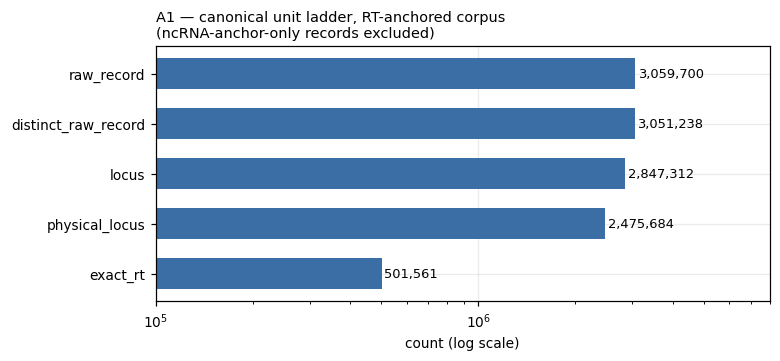

In [6]:
d = pd.read_csv(TABLES / "A1_unit_ladder.tsv", sep="\t").sort_values("rung")
lad = d[d.unit.isin(["raw_record", "distinct_raw_record", "locus", "physical_locus", "exact_rt"])]

fig, ax = plt.subplots(figsize=(7.2, 3.0))
y = np.arange(len(lad))[::-1]
ax.barh(y, lad["n"], color="#3b6ea5", height=0.62)
for yi, (u, n) in zip(y, lad[["unit", "n"]].itertuples(index=False)):
    ax.text(n * 1.02, yi, f"{n:,}", va="center", fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels(lad["unit"])
ax.set_xscale("log"); ax.set_xlim(1e5, 8e6)
ax.set_xlabel("count (log scale)")
ax.set_title("A1 — canonical unit ladder, RT-anchored corpus\n(ncRNA-anchor-only records excluded)",
             fontsize=9.5, loc="left")
savefig(fig, "A1_unit_ladder"); plt.show()

**Interpretation.** The ladder reproduces g2 exactly on every rung, which confirms the workbench
is reading the same canonical tables under the same keys. The collapse is severe and uneven:
3.06 M records carry only 501,561 distinct RT proteins, so **a record count is ~6× an exact-protein
count** — but that factor is an average over a heterogeneous corpus, not a conversion constant
(A2). `rt_taxonomic_occurrence` (2.74 M) sits *above* `locus` counts in informativeness for
taxonomic spread and *below* them for architecture; pick per question.

**Caveat.** `locus_key` is a coordinate interval on a contig *accession*, so two assembly versions
of the same contig are two loci. `physical_locus_key` normalises the `NZ_` spelling; the 371,628
RefSeq/GenBank twin collapses are all evidence-supported (identical window DNA, RT protein,
coordinates and strand), with zero disagreements.

## A2 — Redundancy ratios, and why they are not a constant

* **Question.** How much redundancy does each source database contribute, and how far does the
  locus→exact-RT conversion factor move between them?
* **Unit.** Source database × each rung of the ladder.
* **Denominator.** Distinct raw records (`is_first_copy`) of that source database. **Population:
  full corpus, not `POP_RT`** — this cell characterises the corpus as mined.
  **A locus can appear under more than one source database (203,921 do), so the per-database
  columns do not sum to the corpus totals.**
* **Data.** `rt_records_v1` → `source_database`, `is_first_copy`, `locus_key`,
  `physical_locus_key`, `rt_seq_hash`, `genome_id_norm`.

In [7]:
red = cache("A2_redundancy_by_database", """
    SELECT source_database,
           count(*)                                   AS n_records,
           count(DISTINCT locus_key)                  AS n_loci,
           count(DISTINCT physical_locus_key)         AS n_physical_loci,
           count(DISTINCT rt_seq_hash)                AS n_exact_rt,
           count(DISTINCT genome_id_norm)             AS n_genomes
    FROM rt_records WHERE is_first_copy
    GROUP BY 1 ORDER BY n_records DESC
""")
red["records_per_locus"]  = (red.n_records / red.n_loci).round(3)
red["loci_per_exact_rt"]  = (red.n_loci / red.n_exact_rt).round(2)
red["physical_loci_per_exact_rt"] = (red.n_physical_loci / red.n_exact_rt).round(2)
red["loci_per_genome"]    = (red.n_loci / red.n_genomes).round(3)
save(red, "A2_redundancy_by_database")
display(red)

print(f"\naccession-defined loci per exact RT: {red.loci_per_exact_rt.min():.2f} - {red.loci_per_exact_rt.max():.2f} "
      f"across source databases (~{red.loci_per_exact_rt.max()/red.loci_per_exact_rt.min():.1f}x spread).")
ident = (red.loci_per_exact_rt == red.physical_loci_per_exact_rt).all()
print(f"physical loci per exact RT is {'IDENTICAL' if ident else 'DIFFERENT'} within every database — "
      "the NZ_ twin collapse acts ACROSS databases (NCBI<->GTDB), never inside one, so the\n"
      "  per-database redundancy multiplier is unaffected by the choice of locus definition.")
print("corpus-wide ratios (distinct records / loci / physical loci per exact RT):")
f = pd.read_csv(TABLES / "A1_unit_ladder.tsv", sep="\t").set_index("unit")["n"]
for u in ["distinct_raw_record", "locus", "physical_locus"]:
    print(f"  {u:<22} {f[u] / f['exact_rt']:.3f} per exact RT")

,source_database,n_records,n_loci,n_physical_loci,n_exact_rt,n_genomes,records_per_locus,loci_per_exact_rt,physical_loci_per_exact_rt,loci_per_genome
0,ncbi_bacteria,2251359,2251354,2251354,409992,1237519,1.0,5.49,5.49,1.819
1,gtdb_bacteria,600551,600551,600551,220934,299306,1.0,2.72,2.72,2.006
2,mgnify_human_gut,142185,142185,142185,72910,87226,1.0,1.95,1.95,1.630
3,gem,22271,22271,22271,15852,13645,1.0,1.40,1.40,1.632
4,mgnify_soil,15658,15658,15658,14086,5461,1.0,1.11,1.11,2.867
5,mgnify_marine,7952,7952,7952,6009,4817,1.0,1.32,1.32,1.651
6,ncbi_archaea,7915,7915,7915,6956,4047,1.0,1.14,1.14,1.956
7,gtdb_archaea,3347,3347,3347,2766,1806,1.0,1.21,1.21,1.853



accession-defined loci per exact RT: 1.11 - 5.49 across source databases (~4.9x spread).
physical loci per exact RT is IDENTICAL within every database — the NZ_ twin collapse acts ACROSS databases (NCBI<->GTDB), never inside one, so the
  per-database redundancy multiplier is unaffected by the choice of locus definition.
corpus-wide ratios (distinct records / loci / physical loci per exact RT):
  distinct_raw_record    6.083 per exact RT
  locus                  5.677 per exact RT
  physical_locus         4.936 per exact RT


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


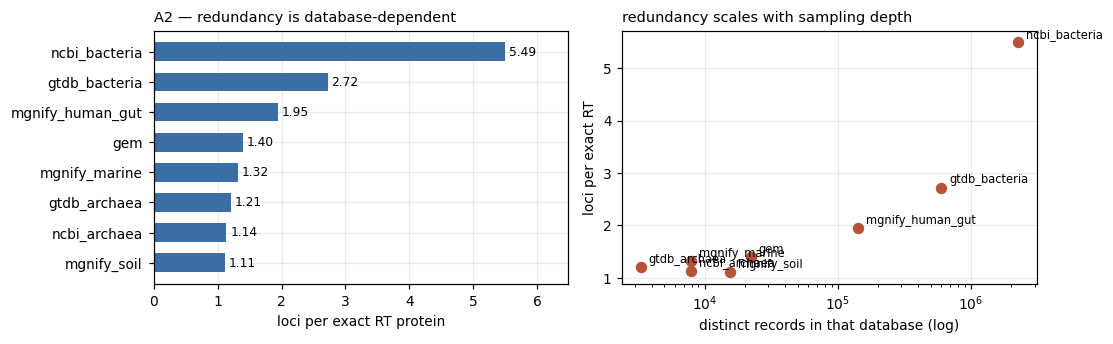

In [8]:
r = pd.read_csv(TABLES / "A2_redundancy_by_database.tsv", sep="\t").sort_values("loci_per_exact_rt")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.2))
ax = axes[0]
ax.barh(r.source_database, r.loci_per_exact_rt, color="#3b6ea5", height=0.62)
for i, v in enumerate(r.loci_per_exact_rt):
    ax.text(v + 0.06, i, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlabel("loci per exact RT protein"); ax.set_xlim(0, r.loci_per_exact_rt.max() * 1.18)
ax.set_title("A2 — redundancy is database-dependent", fontsize=9.5, loc="left")

ax = axes[1]
ax.scatter(r.n_records, r.loci_per_exact_rt, s=42, color="#b5533b", zorder=3)
for _, row in r.iterrows():
    ax.annotate(row.source_database, (row.n_records, row.loci_per_exact_rt),
                textcoords="offset points", xytext=(5, 3), fontsize=7.5)
ax.set_xscale("log"); ax.set_xlabel("distinct records in that database (log)")
ax.set_ylabel("loci per exact RT")
ax.set_title("redundancy scales with sampling depth", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "A2_redundancy_by_database"); plt.show()

**Interpretation.** The multiplier is **accession-defined loci per exact RT protein**, and within
a single source database it is numerically identical to *physical* loci per protein: the `NZ_`
twin collapse merges a RefSeq and a GenBank spelling of one contig, which by construction sit in
different databases. The locus-definition choice therefore changes corpus-wide totals but not the
per-database redundancy reported here. `loci_per_exact_rt` runs from **1.11** (`mgnify_soil`) to **5.49**
(`ncbi_bacteria`) — a ~5× spread, and it tracks how deeply the database was sampled rather than
anything about the RTs. This is the quantitative reason the project refuses a single
record↔protein conversion: an analysis reported on records is weighted by isolate-genome
sequencing effort, an analysis reported on exact RTs is not.

**Caveat.** These per-database columns overlap: 203,921 loci appear under more than one source
database, so column sums exceed the corpus totals in A1. The metagenomic databases (`mgnify_*`,
`gem`) look "less redundant" partly because near-identical MAG contigs receive different contig
accessions and therefore different `locus_key`s — low redundancy here is partly a naming effect.

## A3 — Occurrence distribution per exact RT protein

* **Question.** How is genomic occurrence distributed across distinct RT proteins — is the corpus
  a few hyper-abundant sequences plus a long tail of singletons?
* **Unit.** Exact RT protein (`V-RT`, `rt_seq_hash`), 501,561 of them.
* **Denominator.** All exact RT proteins in `rt_exact_v1` (this **includes** the MULTI stratum;
  the family split is B).
* **Data.** `rt_exact_v1` → `rt_seq_hash`, `n_records`, `n_loci`, `n_physical_loci`, `n_genomes`.
  `rt_seq` is deliberately not selected.

In [9]:
occ = cache("A3_occurrence_buckets", """
    WITH b AS (
      SELECT CASE WHEN n_genomes = 1 THEN '1'
                  WHEN n_genomes <= 10 THEN '2-10'
                  WHEN n_genomes <= 100 THEN '11-100'
                  WHEN n_genomes <= 1000 THEN '101-1000'
                  ELSE '>1000' END AS bucket,
             CASE WHEN n_genomes = 1 THEN 1 WHEN n_genomes <= 10 THEN 2
                  WHEN n_genomes <= 100 THEN 3 WHEN n_genomes <= 1000 THEN 4 ELSE 5 END AS ord,
             n_genomes, n_loci
      FROM rt_exact)
    SELECT bucket, ord, count(*) AS n_exact_rt, sum(n_genomes) AS n_taxocc, sum(n_loci) AS n_loci
    FROM b GROUP BY 1, 2 ORDER BY ord
""")
tot = occ.n_exact_rt.sum()
occ["pct_of_exact_rt"] = (100 * occ.n_exact_rt / tot).round(2)
occ["pct_of_taxocc"]   = (100 * occ.n_taxocc / occ.n_taxocc.sum()).round(2)
save(occ, "A3_occurrence_buckets")
display(occ[["bucket", "n_exact_rt", "pct_of_exact_rt", "n_taxocc", "pct_of_taxocc"]])

q = cache("A3_occurrence_quantiles", """
    SELECT 'n_genomes' AS measure, min(n_genomes) AS min,
           quantile_cont(n_genomes, 0.50) AS median, quantile_cont(n_genomes, 0.90) AS p90,
           quantile_cont(n_genomes, 0.99) AS p99, max(n_genomes) AS max, avg(n_genomes) AS mean
    FROM rt_exact
    UNION ALL SELECT 'n_loci', min(n_loci), quantile_cont(n_loci, 0.50), quantile_cont(n_loci, 0.90),
           quantile_cont(n_loci, 0.99), max(n_loci), avg(n_loci) FROM rt_exact
    UNION ALL SELECT 'n_records', min(n_records), quantile_cont(n_records, 0.50),
           quantile_cont(n_records, 0.90), quantile_cont(n_records, 0.99), max(n_records), avg(n_records)
    FROM rt_exact
""")
display(q.round(2))

top = cache("A3_top_recurrent_exact_rt", """
    SELECT rt_seq_hash, family_label_set, rt_aa_len, n_records, n_loci, n_physical_loci,
           n_genomes, n_source_databases
    FROM rt_exact ORDER BY n_genomes DESC LIMIT 20
""")
display(top.assign(rt_seq_hash=top.rt_seq_hash.str.slice(0, 12) + "…").head(10))

,bucket,n_exact_rt,pct_of_exact_rt,n_taxocc,pct_of_taxocc
0,1,328736,65.54,328736.0,12.01
1,2-10,158339,31.57,461154.0,16.85
2,11-100,12751,2.54,343869.0,12.56
3,101-1000,1482,0.30,396405.0,14.48
4,>1000,253,0.05,1207025.0,44.10


,measure,min,median,p90,p99,max,mean
0,n_genomes,1,1.0,4.0,32.0,118405,5.46
1,n_loci,1,1.0,4.0,34.0,118462,5.68
2,n_records,1,2.0,4.0,37.0,118634,6.08


,rt_seq_hash,family_label_set,rt_aa_len,n_records,n_loci,n_physical_loci,n_genomes,n_source_databases
0,4e86f2e42b1d…,Retron,311,118634,118462,115206,118405,4
1,cec659b114f0…,RVT-GII,494,82153,80997,62609,52979,5
2,6d07b3a55ae9…,RVT-UG11,254,33487,33441,32630,33439,3
3,9b0bd9c5f585…,RVT-GII,507,35909,35413,30179,31520,5
4,b9cbae36f998…,RVT-G2L,398,30693,30527,25849,30418,3
5,38a2e35211e6…,Retron,366,27047,26857,22307,26852,5
6,5be6ce56c3bc…,RVT-GII,636,25922,25849,23602,24799,4
7,9d2bfbf78c9a…,Retron,585,23653,23575,21235,23564,4
8,a21cc8d7874b…,Retron,338,23502,23409,19397,23408,3
9,bbaaf4cf689f…,RVT-GII,160,23405,23288,20691,23275,5


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


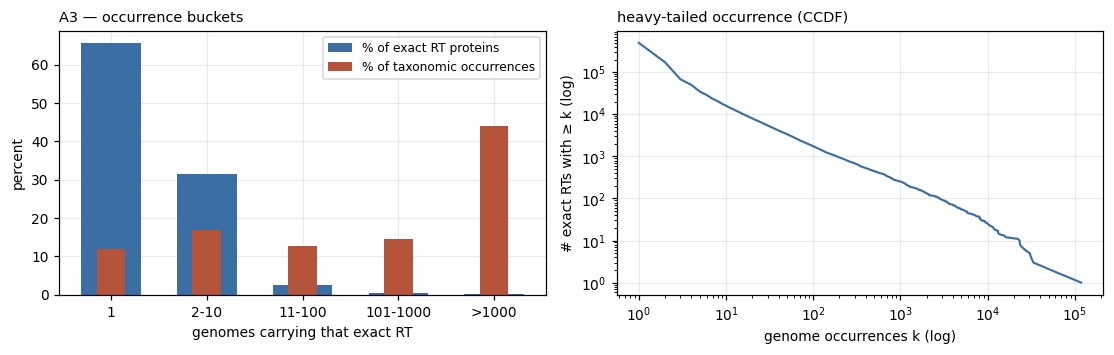

In [10]:
o = pd.read_csv(TABLES / "A3_occurrence_buckets.tsv", sep="\t").sort_values("ord")
ccdf = cache("A3_occurrence_ccdf", """
    WITH t AS (SELECT n_genomes AS k, count(*) AS c FROM rt_exact GROUP BY 1)
    SELECT k, c, sum(c) OVER (ORDER BY k DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS n_at_least
    FROM t ORDER BY k
""")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.3))
ax = axes[0]
ax.bar(o.bucket, o.pct_of_exact_rt, color="#3b6ea5", width=0.62, label="% of exact RT proteins")
ax.bar(o.bucket, o.pct_of_taxocc, color="#b5533b", width=0.30, label="% of taxonomic occurrences")
ax.set_ylabel("percent"); ax.set_xlabel("genomes carrying that exact RT")
ax.legend(fontsize=8); ax.set_title("A3 — occurrence buckets", fontsize=9.5, loc="left")

ax = axes[1]
ax.plot(ccdf.k, ccdf.n_at_least, color="#3b6ea5", lw=1.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("genome occurrences k (log)"); ax.set_ylabel("# exact RTs with ≥ k (log)")
ax.set_title("heavy-tailed occurrence (CCDF)", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "A3_occurrence_distribution"); plt.show()

**Interpretation.** **65.5 %** of exact RT proteins are seen in exactly one genome, while the
253 proteins found in >1,000 genomes account for a large share of all taxonomic occurrences. The
CCDF is close to straight on log–log over three decades, i.e. the corpus is heavy-tailed: any
statistic computed on records is dominated by a small number of hyper-sampled sequences, and the
same statistic computed on `V-RT` is dominated by singletons. Reporting both is the only honest
option.

**Caveat.** "Seen in one genome" is a statement about *this corpus at this sampling*, not about
rarity in nature. The singleton fraction is partly the metagenomic contribution, where every MAG
is its own genome id. The top of the table is the mirror image: hyper-abundant sequences are
concentrated in `ncbi_bacteria`, where the same organism is deposited thousands of times.

## A4 — Source-database attribution: why per-database columns do not sum

* **Question.** A2's per-database counts exceed the corpus totals. What is the overlap made of,
  and what is the right way to report "share of corpus by database"?
* **Unit.** (i) genomic locus (`V-LOC`); (ii) genome; (iii) exact RT protein (`V-RT`).
* **Denominator.** `POP_RT` loci / genomes / exact RTs. Two framings are shown side by side:
  **coverage** (non-exclusive: "how many loci does this database contain") and an **exclusive
  partition** under a declared primary-source rule.
* **Data.** `rt_records_v1` → `source_database`, `locus_key`, `genome_id_norm`, `rt_seq_hash`;
  `rt_exact_v1` → `n_source_databases`.

In [11]:
# 1. what the overlap is actually made of: the set of databases each locus appears under
dbsets = cache("A4_locus_database_sets", f"""
    WITH L AS (
      SELECT locus_key,
             string_agg(DISTINCT source_database, ' + ' ORDER BY source_database) AS database_set,
             count(DISTINCT source_database) AS n_databases
      FROM rt_records WHERE {POP_RT} GROUP BY 1)
    SELECT database_set, n_databases, count(*) AS n_loci
    FROM L GROUP BY 1, 2 ORDER BY n_loci DESC
""")
dbsets["pct_of_loci"] = (100 * dbsets.n_loci / dbsets.n_loci.sum()).round(3)
save(dbsets, "A4_locus_database_sets")
display(dbsets)

shared = dbsets[dbsets.n_databases > 1]
print(f"\nloci under >1 database: {int(shared.n_loci.sum()):,} "
      f"({100 * shared.n_loci.sum() / dbsets.n_loci.sum():.2f}% of POP_RT loci); "
      f"{100 * shared.n_loci.max() / shared.n_loci.sum():.1f}% of that overlap is a single pair.")

,database_set,n_databases,n_loci,pct_of_loci
0,ncbi_bacteria,1,2047331,72.535
1,gtdb_bacteria,1,399258,14.145
2,gtdb_bacteria + ncbi_bacteria,2,200792,7.114
3,mgnify_human_gut,1,124507,4.411
4,gem,1,22235,0.788
5,mgnify_soil,1,13655,0.484
6,mgnify_marine,1,7041,0.249
7,ncbi_archaea,1,4540,0.161
8,gtdb_archaea + ncbi_archaea,2,2439,0.086
9,gtdb_archaea,1,532,0.019



loci under >1 database: 203,448 (7.21% of POP_RT loci); 98.7% of that overlap is a single pair.


In [12]:
# 2. coverage (non-exclusive) vs an exclusive partition under a declared primary-source rule.
#    Rule: most-specific curated source wins. GTDB is a curated re-derivation of the same
#    assemblies NCBI publishes, so where a locus appears under both, GTDB is the primary.
PRIMARY_ORDER = ["gtdb_bacteria", "gtdb_archaea", "ncbi_bacteria", "ncbi_archaea",
                 "mgnify_human_gut", "mgnify_soil", "mgnify_marine", "gem"]
_rank = "CASE source_database " + " ".join(
    f"WHEN '{d}' THEN {i}" for i, d in enumerate(PRIMARY_ORDER)) + " ELSE 99 END"

attrib = cache("A4_database_attribution", f"""
    WITH cov AS (
      SELECT source_database, count(DISTINCT locus_key) AS n_loci_coverage
      FROM rt_records WHERE {POP_RT} GROUP BY 1),
    prim AS (
      SELECT locus_key, arg_min(source_database, {_rank}) AS primary_database
      FROM rt_records WHERE {POP_RT} GROUP BY 1),
    exc AS (
      SELECT primary_database AS source_database, count(*) AS n_loci_exclusive
      FROM prim GROUP BY 1)
    SELECT cov.source_database, cov.n_loci_coverage, coalesce(exc.n_loci_exclusive, 0) AS n_loci_exclusive
    FROM cov LEFT JOIN exc USING (source_database) ORDER BY n_loci_coverage DESC
""")
attrib["pct_of_partition"] = (100 * attrib.n_loci_exclusive / attrib.n_loci_exclusive.sum()).round(3)
attrib["coverage_minus_exclusive"] = attrib.n_loci_coverage - attrib.n_loci_exclusive
save(attrib, "A4_database_attribution")
display(attrib)

_pu = pd.read_csv(TABLES / "A0_pop_rt_units.tsv", sep="\t")
n_pop_loci = int(_pu.loc[_pu.population.str.startswith("POP_RT_CTX"), "n_loci"].iloc[0])
print(f"\ncoverage column sums to {int(attrib.n_loci_coverage.sum()):,} — "
      f"EXCEEDS the {n_pop_loci:,} POP_RT loci, so it is not a share.")
print(f"exclusive column sums to {int(attrib.n_loci_exclusive.sum()):,} — "
      f"{'partitions exactly' if int(attrib.n_loci_exclusive.sum()) == n_pop_loci else 'DOES NOT partition'}.")

,source_database,n_loci_coverage,n_loci_exclusive,pct_of_partition,coverage_minus_exclusive
0,ncbi_bacteria,2248245,2047331,72.535,200914
1,gtdb_bacteria,600145,600145,21.263,0
2,mgnify_human_gut,124507,124507,4.411,0
3,gem,22235,22235,0.788,0
4,mgnify_soil,13655,13655,0.484,0
5,ncbi_archaea,7074,4540,0.161,2534
6,mgnify_marine,7041,7041,0.249,0
7,gtdb_archaea,3093,3093,0.110,0



coverage column sums to 3,025,995 — EXCEEDS the 2,822,547 POP_RT loci, so it is not a share.
exclusive column sums to 2,822,547 — partitions exactly.


In [13]:
# 3. the same question one rung up the ladder: can exact RT proteins be attributed at all?
# NOTE: rt_exact is the FULL-CORPUS exact-RT table (501,561). This panel is therefore on the full
# corpus, unlike the two panels above which are POP_RT. Both are labelled on the figure.
spanning = cache("A4_exact_rt_database_span", """
    SELECT n_source_databases, count(*) AS n_exact_rt FROM rt_exact GROUP BY 1 ORDER BY 1
""")
spanning["pct_of_exact_rt"] = (100 * spanning.n_exact_rt / spanning.n_exact_rt.sum()).round(2)
save(spanning, "A4_exact_rt_database_span")
display(spanning)
multi_db = spanning[spanning.n_source_databases > 1].n_exact_rt.sum()
print(f"\n{multi_db:,} exact RT proteins ({100 * multi_db / spanning.n_exact_rt.sum():.1f}%) "
      f"occur in more than one source database.")

,n_source_databases,n_exact_rt,pct_of_exact_rt
0,1,274725,54.77
1,2,207753,41.42
2,3,17100,3.41
3,4,1943,0.39
4,5,38,0.01
5,6,2,0.00



226,836 exact RT proteins (45.2%) occur in more than one source database.


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


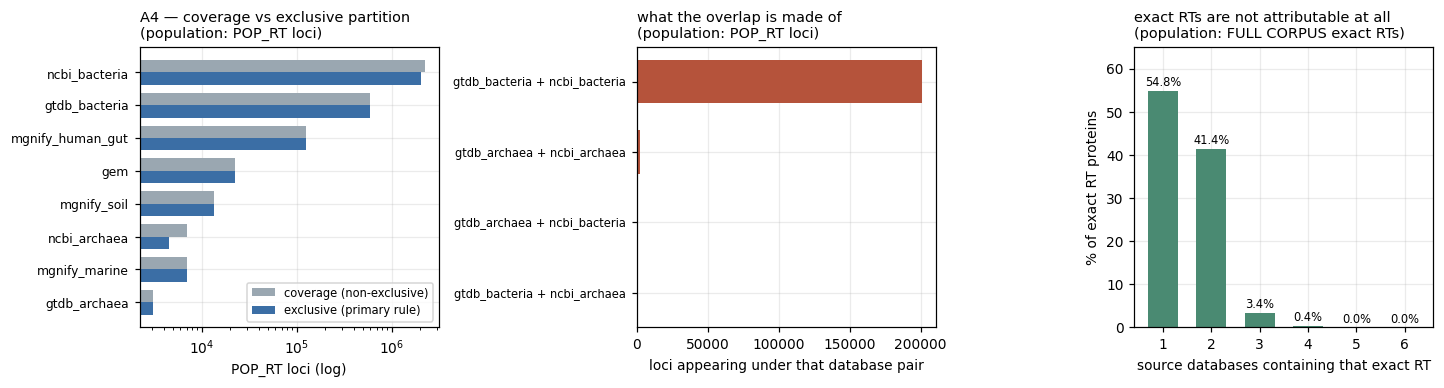

In [14]:
A = pd.read_csv(TABLES / "A4_database_attribution.tsv", sep="\t").iloc[::-1]
S = pd.read_csv(TABLES / "A4_exact_rt_database_span.tsv", sep="\t")
DS = pd.read_csv(TABLES / "A4_locus_database_sets.tsv", sep="\t")
DS = DS[DS.n_databases > 1].sort_values("n_loci")

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.6))

ax = axes[0]
y = np.arange(len(A)); h = 0.38
ax.barh(y + h/2, A.n_loci_coverage, height=h, color="#9aa7b1", label="coverage (non-exclusive)")
ax.barh(y - h/2, A.n_loci_exclusive, height=h, color="#3b6ea5", label="exclusive (primary rule)")
ax.set_yticks(y); ax.set_yticklabels(A.source_database, fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("POP_RT loci (log)"); ax.legend(fontsize=7.5, loc="lower right")
ax.set_title("A4 — coverage vs exclusive partition\n(population: POP_RT loci)", fontsize=9.5, loc="left")

ax = axes[1]
ax.barh(DS.database_set, DS.n_loci, color="#b5533b", height=0.62)
ax.set_xlabel("loci appearing under that database pair")
ax.set_title("what the overlap is made of\n(population: POP_RT loci)", fontsize=9.5, loc="left")
ax.tick_params(axis="y", labelsize=7.5)

ax = axes[2]
ax.bar(S.n_source_databases.astype(str), S.pct_of_exact_rt, color="#4a8a72", width=0.62)
for x, v in zip(range(len(S)), S.pct_of_exact_rt):
    ax.text(x, v + 1.2, f"{v:.1f}%", ha="center", fontsize=7.5)
ax.set_ylim(0, 65)
ax.set_xlabel("source databases containing that exact RT")
ax.set_ylabel("% of exact RT proteins")
ax.set_title("exact RTs are not attributable at all\n(population: FULL CORPUS exact RTs)", fontsize=9.5, loc="left")

fig.tight_layout(); savefig(fig, "A4_database_attribution"); plt.show()

**Interpretation — and the recommended rule.** The overlap is not diffuse: essentially all of it is
a single pair, `gtdb_bacteria + ncbi_bacteria` (plus the archaeal equivalent). GTDB is a curated
re-derivation of assemblies NCBI publishes, so those loci are **one organism seen twice**, not two
observations. Three consequences, in increasing severity up the unit ladder:

1. **Loci can be partitioned**, but only under a declared rule. The primary-source rule above
   (curated GTDB wins over NCBI; metagenomic databases never collide) sums exactly to the `POP_RT`
   locus total, so the `pct_of_partition` column is a legitimate share.
2. **Genomes overlap the same way** — 111,394 of 1,542,433 appear under two databases.
3. **Exact RT proteins cannot be attributed at all.** **45.23 %** occur in ≥2 databases — measured
   on the full-corpus exact-RT table (501,561), *not* on `POP_RT`, because database span is a
   property of all observations of a protein, and one protein
   in six databases is a meaningful biological statement, not a bookkeeping error. At the `V-RT`
   rung, "database" is a property of an *observation*, not of the object.

**So: how to address it.** Report per-database numbers as **coverage**, never as shares — that is
what A2 does, and it is correct for redundancy. When a share is genuinely needed (e.g. "what
fraction of the corpus is metagenomic"), do it **at the locus or genome rung under the declared
primary-source rule**, name the rule, and show the `coverage_minus_exclusive` column so the reader
sees what the rule moved. Never compute a database share on exact RTs.

**Caveat.** The primary-source rule is a *reporting* convention, not a claim that GTDB's copy is
the better one. Changing the priority order moves ~201 k loci between two rows and nothing else;
the metagenomic databases are unaffected because they never collide with anything.

---

# B. RT-family landscape

Family composition is reported on **exact RT proteins**, not records: on records the landscape is
a picture of which organisms were sequenced most. `MULTI` is held out as its own stratum
throughout (Rule 2) and `V-RT-CROSS` — exact proteins seen under more than one family label in
single-family files — is reported separately rather than assigned anywhere.

## B1 — Exact RT count and proportion by family

* **Question.** How is the distinct-protein diversity of the corpus distributed over RT families,
  and how different is that from the record-level distribution?
* **Unit.** Exact RT protein (`V-RT`), split into `V-RT-SINGLE` (493,956), `V-RT-MULTI` (7,593)
  and `V-RT-CROSS` (12).
* **Denominator.** `V-RT-SINGLE` exact RTs for family proportions. MULTI and CROSS are reported
  as their own rows and are **never** folded into a family.
* **Data.** `rt_family_baseline_v1` → `rt_seq_hash`, `family_label`, `view`, `rt_aa_len`;
  `rt_records_v1` → `file_label`, `is_first_copy` for the record-level comparison.

In [15]:
views = cache("B1_views", "SELECT view, count(*) AS n_exact_rt FROM rt_family_baseline GROUP BY 1 ORDER BY 2 DESC")
display(views)
print("against g4:")
for v, k in [("V-RT-SINGLE", "v_single"), ("V-RT-MULTI", "v_multi"), ("V-RT-CROSS", "v_cross")]:
    check(v, int(views.loc[views.view == v, "n_exact_rt"].iloc[0]), k)

fam = cache("B1_family_composition", """
    WITH rt AS (
      SELECT family_label, count(*) AS n_exact_rt
      FROM rt_family_baseline WHERE view = 'V-RT-SINGLE' GROUP BY 1),
    rec AS (
      SELECT file_label AS family_label, count(*) AS n_records, count(DISTINCT locus_key) AS n_loci
      FROM rt_records WHERE is_first_copy AND file_label <> 'MULTI' GROUP BY 1)
    SELECT rt.family_label, rt.n_exact_rt, rec.n_records, rec.n_loci
    FROM rt JOIN rec USING (family_label) ORDER BY rt.n_exact_rt DESC
""")
fam["pct_of_exact_rt"] = (100 * fam.n_exact_rt / fam.n_exact_rt.sum()).round(3)
fam["pct_of_records"]  = (100 * fam.n_records  / fam.n_records.sum()).round(3)
fam["loci_per_exact_rt"] = (fam.n_loci / fam.n_exact_rt).round(2)
save(fam, "B1_family_composition")
print(f"\n{len(fam)} single-family labels; "
      f"top 3 = {fam.pct_of_exact_rt.head(3).sum():.1f}% of V-RT-SINGLE exact RTs "
      f"vs {fam.pct_of_records.head(3).sum():.1f}% of distinct records.")
display(fam.head(15))

,view,n_exact_rt
0,V-RT-SINGLE,493956
1,V-RT-MULTI,7593
2,V-RT-CROSS,12


against g4:
  [MATCH] V-RT-SINGLE                                    recomputed=493956           canonical=493956.0
  [MATCH] V-RT-MULTI                                     recomputed=7593             canonical=7593.0
  [MATCH] V-RT-CROSS                                     recomputed=12               canonical=12.0

41 single-family labels; top 3 = 83.2% of V-RT-SINGLE exact RTs vs 82.4% of distinct records.


,family_label,n_exact_rt,n_records,n_loci,pct_of_exact_rt,pct_of_records,loci_per_exact_rt
0,RVT-GII,256624,1613901,1525893,51.953,53.050,5.95
1,Retron,78287,663308,632688,15.849,21.803,8.08
2,RVT-DGRs,76111,228165,173191,15.408,7.500,2.28
3,RVT-UG2,8423,46286,42793,1.705,1.521,5.08
4,RVT-UG8,7261,38721,37297,1.470,1.273,5.14
5,RVT-UG5,6439,52895,51344,1.304,1.739,7.97
6,RVT-AbiP2,6377,47306,44697,1.291,1.555,7.01
7,RVT-UG3,5821,39992,38549,1.178,1.315,6.62
8,RVT-UG4,4705,32526,31720,0.953,1.069,6.74
9,RVT-UG17,4702,39508,38354,0.952,1.299,8.16


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


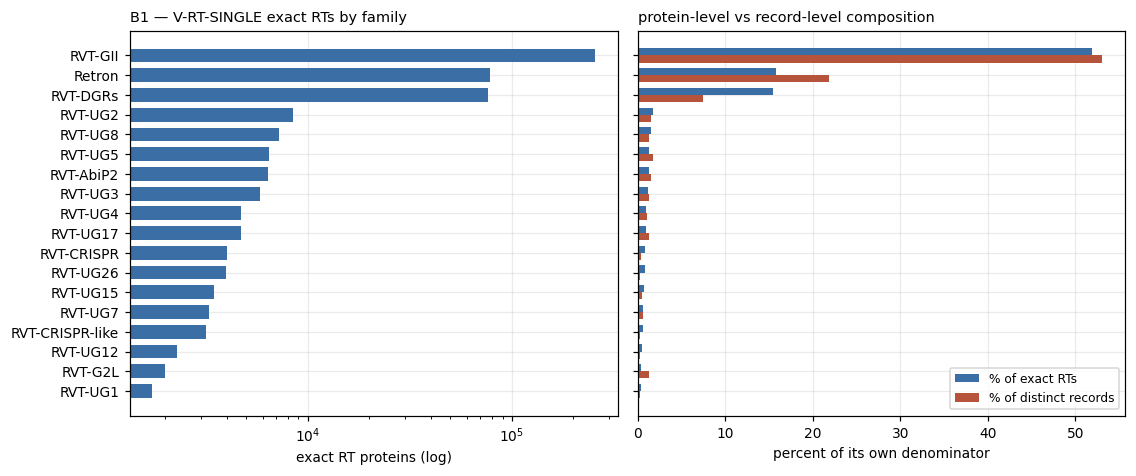

In [16]:
f = pd.read_csv(TABLES / "B1_family_composition.tsv", sep="\t").head(18).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), sharey=True)
y = np.arange(len(f))
ax = axes[0]
ax.barh(y, f.n_exact_rt, color="#3b6ea5", height=0.7)
ax.set_yticks(y); ax.set_yticklabels(f.family_label)
ax.set_xscale("log"); ax.set_xlabel("exact RT proteins (log)")
ax.set_title("B1 — V-RT-SINGLE exact RTs by family", fontsize=9.5, loc="left")

ax = axes[1]
h = 0.36
ax.barh(y + h/2, f.pct_of_exact_rt, height=h, color="#3b6ea5", label="% of exact RTs")
ax.barh(y - h/2, f.pct_of_records,  height=h, color="#b5533b", label="% of distinct records")
ax.set_xlabel("percent of its own denominator"); ax.legend(fontsize=8)
ax.set_title("protein-level vs record-level composition", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "B1_family_composition"); plt.show()

**Interpretation.** RVT-GII dominates distinct-protein diversity (~52 % of `V-RT-SINGLE`), with
Retron and RVT-DGRs next; the three together are ~83 % of exact RTs. The record-level bars differ
from the protein-level bars for every family, and the direction of the gap is informative:
families whose `% of records` exceeds `% of exact RTs` (see `loci_per_exact_rt` in the table)
are those concentrated in heavily redeposited isolate genomes.

**Caveat.** `family_label` here is the **corpus file the record came from** — a myRT-library
assignment, not an independent classification. A family's size is therefore partly the size and
sensitivity of its HMM. `MULTI` (7,593) and `V-RT-CROSS` (12) are excluded from these percentages
by construction; do not re-add them to reach 501,561.

## B2 — RT length distribution by family

* **Question.** Do the major RT families occupy distinguishable protein-length regimes, and does
  the recomputed distribution match the landed g4 baseline?
* **Unit.** Exact RT protein (`V-RT-SINGLE`), one length per distinct sequence.
* **Denominator.** `V-RT-SINGLE` exact RTs of that family label. Families with n < 30 get no
  Tukey fences (the g4 rule) and are omitted from the plot.
* **Data.** `rt_family_baseline_v1` → `family_label`, `rt_aa_len`, `view`.

In [17]:
lens = cache("B2_rt_length_by_family", """
    SELECT family_label, count(*) AS n_exact_rt,
           min(rt_aa_len) AS min,
           quantile_cont(rt_aa_len, 0.25) AS q25,
           quantile_cont(rt_aa_len, 0.50) AS median,
           quantile_cont(rt_aa_len, 0.75) AS q75,
           max(rt_aa_len) AS max,
           avg(rt_aa_len) AS mean
    FROM rt_family_baseline WHERE view = 'V-RT-SINGLE'
    GROUP BY 1 ORDER BY n_exact_rt DESC
""")
lens["iqr"] = lens.q75 - lens.q25
save(lens, "B2_rt_length_by_family")
display(lens.head(14).round(1))

print("\nagainst g4_rt_length_by_family:")
g4 = gate_table("dbchar_g4_family_baseline", "g4_rt_length_by_family")
m = lens.merge(g4[["family_label", "n_exact_rt", "median", "q25", "q75"]],
               on="family_label", suffixes=("", "_g4"))
bad = m[(m["median"] != m["median_g4"]) | (m.n_exact_rt != m.n_exact_rt_g4)]
print(f"  [{'MATCH' if bad.empty else ' DIFF'}] {len(m)} families compared on (n, median, q25, q75); "
      f"{len(bad)} disagree")
check("Retron median aa", float(lens.loc[lens.family_label == "Retron", "median"].iloc[0]), "retron_median_len")
check("RVT-GII median aa", float(lens.loc[lens.family_label == "RVT-GII", "median"].iloc[0]), "gii_median_len")

multi_len = Q("""SELECT count(*) AS n, quantile_cont(rt_aa_len, 0.50) AS median_aa_len
                 FROM rt_family_baseline WHERE view = 'V-RT-MULTI'""")
print(f"\nMULTI stratum (held out): n={int(multi_len.n[0]):,}, median {multi_len.median_aa_len[0]:.0f} aa")

,family_label,n_exact_rt,min,q25,median,q75,max,mean,iqr
0,RVT-GII,256624,20,244.0,407.0,470.0,10449,373.4,226.0
1,Retron,78287,26,289.0,342.0,442.0,9260,365.7,153.0
2,RVT-DGRs,76111,30,316.0,359.0,404.0,5001,354.5,88.0
3,RVT-UG2,8423,31,298.0,431.0,473.0,1499,390.7,175.0
4,RVT-UG8,7261,55,352.0,606.0,669.0,2473,515.0,317.0
5,RVT-UG5,6439,45,428.0,892.0,1006.0,1471,756.9,578.0
6,RVT-AbiP2,6377,42,360.0,498.0,517.0,2129,450.1,157.0
7,RVT-UG3,5821,37,310.0,409.0,432.0,3794,375.5,122.0
8,RVT-UG4,4705,32,198.0,309.0,358.0,2687,318.8,160.0
9,RVT-UG17,4702,54,284.0,427.5,454.0,1325,369.7,170.0



against g4_rt_length_by_family:
  [MATCH] 41 families compared on (n, median, q25, q75); 0 disagree
  [MATCH] Retron median aa                               recomputed=342.0            canonical=342.0
  [MATCH] RVT-GII median aa                              recomputed=407.0            canonical=407.0



MULTI stratum (held out): n=7,593, median 283 aa


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


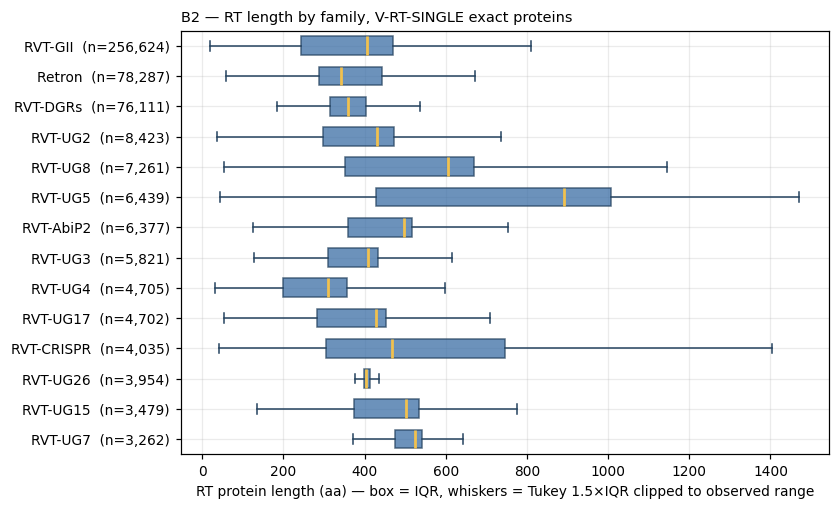

In [18]:
L = pd.read_csv(TABLES / "B2_rt_length_by_family.tsv", sep="\t")
L = L[L.n_exact_rt >= 30].head(14).iloc[::-1]

stats = [dict(label=f"{r.family_label}  (n={int(r.n_exact_rt):,})", med=r["median"],
              q1=r.q25, q3=r.q75,
              whislo=max(r["min"], r.q25 - 1.5 * (r.q75 - r.q25)),
              whishi=min(r["max"], r.q75 + 1.5 * (r.q75 - r.q25)), fliers=[])
         for _, r in L.iterrows()]

fig, ax = plt.subplots(figsize=(7.6, 5.0))
bp = ax.bxp(stats, vert=False, showfliers=False, patch_artist=True, widths=0.62)
for p in bp["boxes"]:
    p.set_facecolor("#3b6ea5"); p.set_alpha(0.75); p.set_edgecolor("#24425f")
for k in ("whiskers", "caps"):
    for p in bp[k]: p.set_color("#24425f")
for p in bp["medians"]: p.set_color("#f2c14e"); p.set_linewidth(1.8)
ax.set_xlabel("RT protein length (aa) — box = IQR, whiskers = Tukey 1.5×IQR clipped to observed range")
ax.set_title("B2 — RT length by family, V-RT-SINGLE exact proteins", fontsize=9.5, loc="left")
savefig(fig, "B2_rt_length_by_family"); plt.show()

**Interpretation.** The families separate but overlap heavily: Retron sits at a median 342 aa,
RVT-GII at 407 aa, and several ungrouped families (RVT-UG5, RVT-UG8) are far longer — these are
the domain-fusion families. Length alone is not a classifier; the IQRs of the three largest
families all intersect.

**Caveat.** The extremes are real records, not outliers to be trimmed: maxima above 9,000 aa occur
in Retron and RVT-GII and are retained (`g4_rt_length_named_outliers.tsv`). Length is also
confounded by completeness — a partial call is short by construction — which is why B3 reports
completeness on the same denominator. `MULTI` proteins are *shorter* than single-family ones
(median 283 aa), and HMM score scales with length, so part of the MULTI label tie may be a length
effect (see G).

## B3 — Completeness / partiality by family

* **Question.** How much of each family's protein-length distribution is carried by calls that are
  not complete ORFs?
* **Unit.** Exact RT protein (`V-RT-SINGLE`).
* **Denominator.** `V-RT-SINGLE` exact RTs of that family label.
* **Data.** `rt_family_baseline_v1` → `family_label`, `completeness_class`, `view`, `rt_aa_len`.
  `completeness_class` aggregates the Prodigal partial flags over all records of that exact
  sequence: **a missing flag is `no_completeness_evidence`, never `partial`** (g4 rule).

In [19]:
comp = cache("B3_completeness_by_family", """
    SELECT family_label, completeness_class, count(*) AS n_exact_rt,
           quantile_cont(rt_aa_len, 0.50) AS median_aa_len
    FROM rt_family_baseline WHERE view = 'V-RT-SINGLE'
    GROUP BY 1, 2
""")
piv = comp.pivot_table(index="family_label", columns="completeness_class",
                       values="n_exact_rt", fill_value=0)
piv["n_family"] = piv.sum(axis=1)
pct = (100 * piv.drop(columns="n_family").div(piv.n_family, axis=0)).round(2)
pct["n_family"] = piv.n_family
pct = pct.sort_values("n_family", ascending=False)
display(pct.head(15))

overall = Q("""SELECT completeness_class, count(*) AS n FROM rt_family_baseline GROUP BY 1 ORDER BY 2 DESC""")
overall["pct_of_all_exact_rt"] = (100 * overall.n / overall.n.sum()).round(2)
print("\nover all 501,561 exact RTs (all views):"); display(overall)

print("\nagainst g4_completeness_by_family (n_exact_rt per family x class):")
g4c = gate_table("dbchar_g4_family_baseline", "g4_completeness_by_family")
mm = comp.merge(g4c[["family_label", "completeness_class", "n_exact_rt"]],
                on=["family_label", "completeness_class"], suffixes=("", "_g4"))
print(f"  [{'MATCH' if (mm.n_exact_rt == mm.n_exact_rt_g4).all() else ' DIFF'}] "
      f"{len(mm)} (family, class) cells compared")

completeness_class,all_complete,all_partial,mixed_or_codon_evidence,n_family
family_label,,,,
RVT-GII,65.09,27.54,7.37,256624.0
Retron,69.84,25.49,4.67,78287.0
RVT-DGRs,79.11,14.36,6.52,76111.0
RVT-UG2,70.64,24.91,4.45,8423.0
RVT-UG8,54.12,43.33,2.55,7261.0
RVT-UG5,57.18,41.05,1.77,6439.0
RVT-AbiP2,62.00,33.51,4.48,6377.0
RVT-UG3,64.56,32.93,2.51,5821.0
RVT-UG4,75.13,23.93,0.94,4705.0



over all 501,561 exact RTs (all views):


,completeness_class,n,pct_of_all_exact_rt
0,all_complete,342256,68.24
1,all_partial,127473,25.42
2,mixed_or_codon_evidence,31832,6.35



against g4_completeness_by_family (n_exact_rt per family x class):
  [MATCH] 121 (family, class) cells compared


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


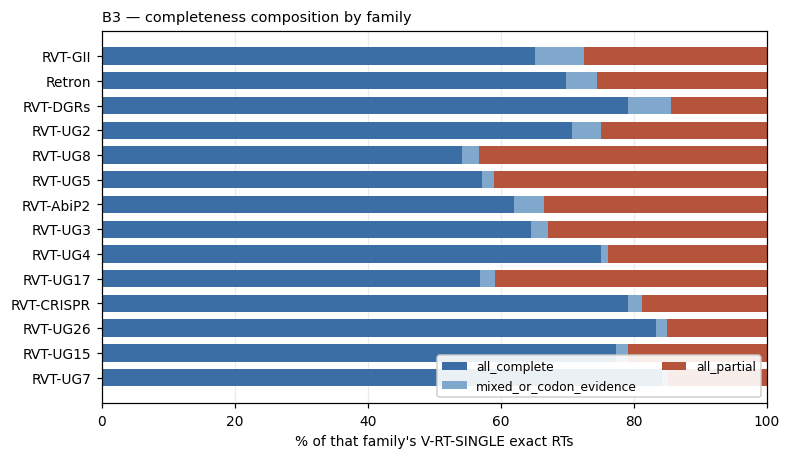

In [20]:
P = pd.read_csv(TABLES / "B3_completeness_by_family.tsv", sep="\t")
piv = P.pivot_table(index="family_label", columns="completeness_class", values="n_exact_rt", fill_value=0)
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index[:14]].iloc[::-1]
frac = 100 * piv.div(piv.sum(axis=1), axis=0)
order = [c for c in ["all_complete", "mixed_or_codon_evidence", "all_partial",
                     "no_completeness_evidence"] if c in frac.columns]
colors = {"all_complete": "#3b6ea5", "mixed_or_codon_evidence": "#7fa8cc",
          "all_partial": "#b5533b", "no_completeness_evidence": "#9a9a9a"}

fig, ax = plt.subplots(figsize=(7.8, 4.4))
left = np.zeros(len(frac))
for c in order:
    ax.barh(frac.index, frac[c], left=left, color=colors[c], label=c, height=0.7)
    left += frac[c].values
ax.set_xlim(0, 100); ax.set_xlabel("% of that family's V-RT-SINGLE exact RTs")
ax.legend(fontsize=8, ncol=2, loc="lower right", framealpha=0.9)
ax.set_title("B3 — completeness composition by family", fontsize=9.5, loc="left")
savefig(fig, "B3_completeness_by_family"); plt.show()

**Interpretation.** Partiality is not evenly distributed: roughly a quarter of all exact RTs are
`all_partial`, but the fraction varies strongly by family, and the families with the most partial
calls are also the ones whose length medians sit lowest. Any family-level length comparison should
therefore be repeated on `all_complete` only before it is interpreted as a protein-architecture
difference.

**Caveat.** `completeness_class` describes the *calls*, not the organism: a partial flag usually
means the ORF ran into a contig end, which is an assembly property. `no_completeness_evidence`
(absent Prodigal flag) is deliberately its own class and must not be read as "complete".

---

# C. ncRNA landscape

Two different things are counted in this section and must not be conflated: an **ncRNA call**
(a row of `rt_ncrna_calls_v1`, 346,722 of them) and an **exact ncRNA sequence**
(`nc_seq_hash`, 16,458 of them). A call is not a pair, and a pair is not a placement.

The single most important caveat for everything below: **the covariance models used are retron
models.** A zero-ncRNA rate outside the Retron family measures detector scope, not biology.

## C1 — ncRNA call counts, and zero / one / multiple calls per RT locus

* **Question.** How many ncRNA calls exist, how do they distribute over loci, and what fraction of
  loci of each RT family carry no call at all?
* **Unit.** (i) ncRNA call (`V-NCRNA-CALL`); (ii) exact ncRNA sequence (`nc_seq_hash`);
  (iii) RT locus (`V-LOC`) for the zero/one/multiple split.
* **Denominator.** For the zero-class: **loci of that family label**, built from distinct raw
  records (`is_first_copy`) — the g3 denominator. MULTI is its own row.
* **Data.** `rt_ncrna_calls_v1`; `rt_ncrna_pairs_v1` → `locus_key`, `geometry_eligible`;
  `rt_records_v1` → `file_label`, `locus_key`, `n_ncrna`, `is_first_copy`.

In [21]:
sizes = cache("C1_ncrna_view_sizes", """
    SELECT 'ncrna_calls (V-NCRNA-CALL)' AS view, count(*) AS n FROM rt_ncrna_calls
    UNION ALL SELECT 'placements, all',        count(*)                     FROM rt_ncrna_pairs
    UNION ALL SELECT 'placements, canonical',  count(*) FILTER (WHERE canonical) FROM rt_ncrna_pairs
    UNION ALL SELECT 'exact ncRNA sequences',  count(DISTINCT nc_seq_hash)  FROM rt_ncrna_calls
    UNION ALL SELECT 'exact RT-ncRNA pairs',   count(*)                     FROM rt_ncrna_exact_pairs
    UNION ALL SELECT 'loci carrying >=1 eligible call',
              count(DISTINCT locus_key) FILTER (WHERE geometry_eligible)    FROM rt_ncrna_pairs
""")
display(sizes)
print("against g3/g7:")
check("placements, all", int(sizes.loc[sizes.view == "placements, all", "n"].iloc[0]), "placements")
check("placements, canonical", int(sizes.loc[sizes.view == "placements, canonical", "n"].iloc[0]), "canonical")
check("exact RT-ncRNA pairs", int(sizes.loc[sizes.view == "exact RT-ncRNA pairs", "n"].iloc[0]), "pairs")

zero = cache("C1_zero_class_by_family", """
    SELECT file_label,
           count(DISTINCT locus_key)                                            AS n_loci,
           count(DISTINCT CASE WHEN n_ncrna > 0 THEN locus_key END)             AS n_loci_with_call,
           count(DISTINCT CASE WHEN n_ncrna = 0 THEN locus_key END)             AS n_loci_zero_ncrna
    FROM rt_records WHERE is_first_copy GROUP BY 1 ORDER BY n_loci DESC
""")
# A locus carries several records. If ANY record of a locus reported an ncRNA while another
# reported none, the locus would fall in both categories and the split would not be a partition.
# Verify rather than assume:
mixed = Q("""SELECT count(*) FILTER (WHERE mn = 0 AND mx > 0) AS mixed_loci, count(*) AS total_loci
             FROM (SELECT locus_key, min(n_ncrna) mn, max(n_ncrna) mx
                   FROM rt_records WHERE is_first_copy GROUP BY 1)""")
assert int(mixed.mixed_loci[0]) == 0, "zero/positive locus categories are NOT mutually exclusive"
print(f"  [OK] 0 of {int(mixed.total_loci[0]):,} loci have mixed records; "
      "the zero/positive split is a true partition.")
zero["pct_zero"] = (100 * zero.n_loci_zero_ncrna / zero.n_loci).round(4)
assert (zero.n_loci_with_call + zero.n_loci_zero_ncrna == zero.n_loci).all()
save(zero, "C1_zero_class_by_family")
display(zero.head(12))
print("\nagainst g3_zero_class_by_family:")
check("Retron  pct_zero", float(zero.loc[zero.file_label == "Retron", "pct_zero"].iloc[0]), "retron_zero", tol=1e-3)
check("RVT-GII pct_zero", float(zero.loc[zero.file_label == "RVT-GII", "pct_zero"].iloc[0]), "gii_zero", tol=1e-3)

perloc = cache("C1_calls_per_locus", """
    SELECT least(n_calls, 10) AS n_calls_capped, count(*) AS n_loci FROM (
      SELECT locus_key, count(*) AS n_calls FROM rt_ncrna_pairs
      WHERE geometry_eligible GROUP BY 1) GROUP BY 1 ORDER BY 1
""")
display(perloc)

,view,n
0,ncrna_calls (V-NCRNA-CALL),346722
1,"placements, all",346722
2,"placements, canonical",344154
3,exact ncRNA sequences,16466
4,exact RT-ncRNA pairs,30924
5,loci carrying >=1 eligible call,333957


against g3/g7:
  [MATCH] placements, all                                recomputed=346722           canonical=346722.0
  [MATCH] placements, canonical                          recomputed=344154           canonical=344154.0
  [MATCH] exact RT-ncRNA pairs                           recomputed=30924            canonical=30924.0


  [OK] 0 of 2,847,312 loci have mixed records; the zero/positive split is a true partition.


,file_label,n_loci,n_loci_with_call,n_loci_zero_ncrna,pct_zero
0,RVT-GII,1525893,120,1525773,99.9921
1,Retron,632688,333838,298850,47.2350
2,RVT-DGRs,173191,36,173155,99.9792
3,RVT-UG11,73555,0,73555,100.0000
4,RVT-UG5,51344,2,51342,99.9961
5,RVT-AbiP2,44697,8,44689,99.9821
6,RVT-UG2,42793,11,42782,99.9743
7,RVT-UG3,38549,2,38547,99.9948
8,RVT-UG17,38354,0,38354,100.0000
9,RVT-G2L,38031,0,38031,100.0000



against g3_zero_class_by_family:
  [MATCH] Retron  pct_zero                               recomputed=47.235           canonical=47.235
  [MATCH] RVT-GII pct_zero                               recomputed=99.9921          canonical=99.9921


,n_calls_capped,n_loci
0,1,322744
1,2,11148
2,3,5
3,4,51
4,6,9


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


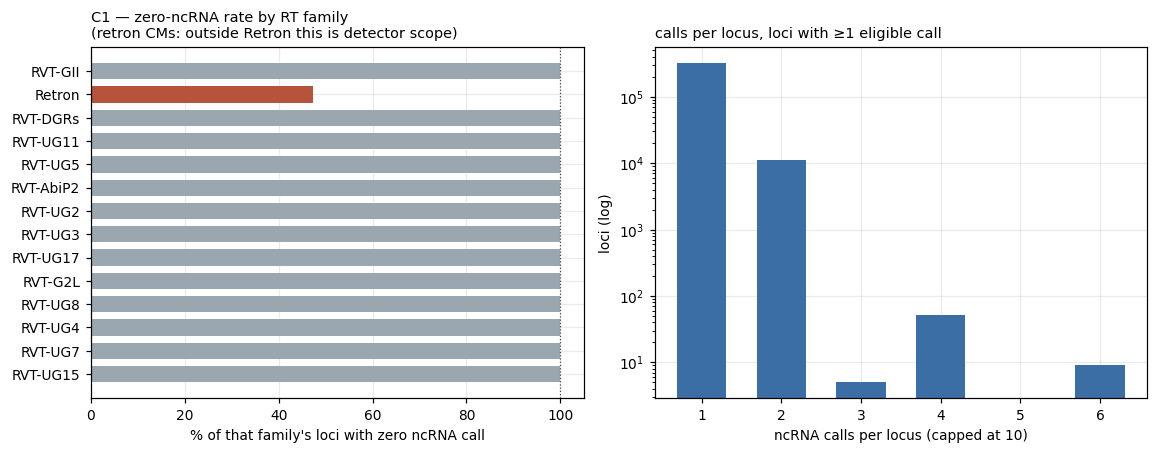

In [22]:
Z = pd.read_csv(TABLES / "C1_zero_class_by_family.tsv", sep="\t").head(14).iloc[::-1]
PL = pd.read_csv(TABLES / "C1_calls_per_locus.tsv", sep="\t")

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.2))
ax = axes[0]
cols = ["#b5533b" if f == "Retron" else "#9aa7b1" for f in Z.file_label]
ax.barh(Z.file_label, Z.pct_zero, color=cols, height=0.7)
ax.axvline(100, color="#444", lw=0.8, ls=":")
ax.set_xlim(0, 105); ax.set_xlabel("% of that family's loci with zero ncRNA call")
ax.set_title("C1 — zero-ncRNA rate by RT family\n(retron CMs: outside Retron this is detector scope)",
             fontsize=9.5, loc="left")

ax = axes[1]
ax.bar(PL.n_calls_capped, PL.n_loci, color="#3b6ea5", width=0.62)
ax.set_yscale("log"); ax.set_xlabel("ncRNA calls per locus (capped at 10)")
ax.set_ylabel("loci (log)")
ax.set_title("calls per locus, loci with ≥1 eligible call", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "C1_ncrna_call_landscape"); plt.show()

**Interpretation.** Retron loci carry a call **52.8 %** of the time (zero-rate 47.23 %); every
other family is at or above 99.9 % zero. That contrast is **not** evidence that non-Retron RTs lack
associated ncRNA — the models are retron models, so outside Retron this measures what the detector
can see. Among loci that do carry a call, the overwhelming majority carry exactly one; the
multi-call tail is small and is mostly the same call arriving from another record of the same
locus, not a second biological ncRNA (see the `multiplicity_class` breakdown in I).

**Caveat.** The denominator is *loci*, built from distinct raw records. A locus with no call and a
locus never examined by a CM look identical here. Any absence statement needs the positive control
in `results/dbchar_g3_pair_geometry/tables/c04_positive_controls.tsv`.

## C2 — ncRNA length distribution

* **Question.** What length regime do the called ncRNAs occupy, and does it differ by covariance
  model?
* **Unit.** Exact ncRNA sequence (`nc_seq_hash`), 16,458.
* **Denominator.** Exact ncRNA sequences called by that model. **Every exact ncRNA sequence in
  this corpus is hit by exactly one model** (verified below: `n_models > 1` for 0 of 16,458), so
  the per-model counts **do** partition the 16,458 sequences and C2 (representative model) and C3
  (call-level model) cannot disagree about which model a sequence belongs to.
* **Data.** `ncrna_family_baseline_v1` → `nc_seq_hash`, `nc_seq_len`, `detection_model`,
  `n_models`, `n_placements`.

In [23]:
nlen = cache("C2_ncrna_length_by_model", """
    SELECT detection_model, count(*) AS n_exact_ncrna,
           min(nc_seq_len) AS min,
           quantile_cont(nc_seq_len, 0.25) AS q25,
           quantile_cont(nc_seq_len, 0.50) AS median,
           quantile_cont(nc_seq_len, 0.75) AS q75,
           max(nc_seq_len) AS max
    FROM ncrna_family_baseline GROUP BY 1 ORDER BY n_exact_ncrna DESC
""")
display(nlen.head(16))

allb = Q("""SELECT count(*) AS n_exact_ncrna, min(nc_seq_len) AS min,
                   quantile_cont(nc_seq_len,0.25) AS q25, quantile_cont(nc_seq_len,0.50) AS median,
                   quantile_cont(nc_seq_len,0.75) AS q75, max(nc_seq_len) AS max,
                   count(*) FILTER (WHERE n_models > 1) AS n_multi_model,
                   count(*) FILTER (WHERE any_structure) AS n_with_structure
            FROM ncrna_family_baseline""")
print("\nall exact ncRNA sequences:"); display(allb)
assert int(allb.n_multi_model[0]) == 0, "an exact ncRNA is hit by >1 model; C2/C3 need reconciling"
assert int(nlen.n_exact_ncrna.sum()) == int(allb.n_exact_ncrna[0])
print(f"  [OK] per-model counts sum to {int(nlen.n_exact_ncrna.sum()):,} = every exact ncRNA "
      "sequence, each hit by exactly one model. C2 and C3 model labels are interchangeable.")

print("against g4_ncrna_length_by_model:")
g4n = gate_table("dbchar_g4_family_baseline", "g4_ncrna_length_by_model")
mm = nlen.merge(g4n[["detection_model", "n_exact_ncrna", "median"]], on="detection_model",
                suffixes=("", "_g4"))
print(f"  [{'MATCH' if (mm.n_exact_ncrna == mm.n_exact_ncrna_g4).all() and (mm['median'] == mm['median_g4']).all() else ' DIFF'}]"
      f" {len(mm)} models compared on (n, median)")

,detection_model,n_exact_ncrna,min,q25,median,q75,max
0,OutgroupA,3319,75,126.00,129.0,131.0,146
1,TypeIA_IIAI,2109,60,147.00,159.0,167.0,345
2,TypeIC1_IC2,2034,49,129.00,134.0,141.0,193
3,Ec107_like,2023,74,172.00,183.0,194.5,359
4,TypeXIIIB_Ne144,1534,66,221.00,224.0,230.0,265
5,TypeIIIA3,736,76,254.00,264.0,276.0,324
6,TypeIB1,574,81,140.00,147.0,153.0,183
7,TypeXIIIA_firmi,496,48,197.75,200.0,203.0,237
8,TypeIIIA1,439,89,134.00,137.0,143.0,177
9,TypeXIIIC_Mx162,425,45,246.00,255.0,258.0,395



all exact ncRNA sequences:


,n_exact_ncrna,min,q25,median,q75,max,n_multi_model,n_with_structure
0,16458,34,131.0,151.0,193.0,395,0,1251


  [OK] per-model counts sum to 16,458 = every exact ncRNA sequence, each hit by exactly one model. C2 and C3 model labels are interchangeable.
against g4_ncrna_length_by_model:
  [MATCH] 21 models compared on (n, median)


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


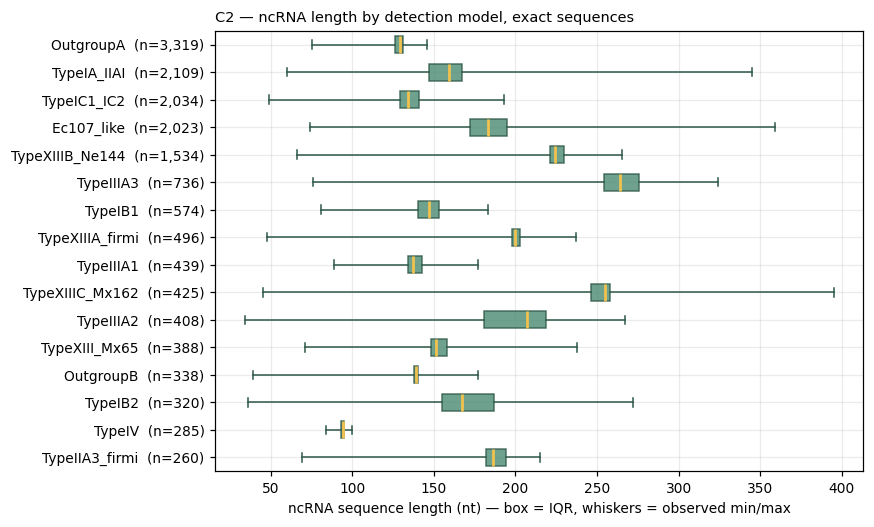

In [24]:
N = pd.read_csv(TABLES / "C2_ncrna_length_by_model.tsv", sep="\t")
N = N[N.n_exact_ncrna >= 30].head(16).iloc[::-1]
stats = [dict(label=f"{r.detection_model}  (n={int(r.n_exact_ncrna):,})", med=r["median"],
              q1=r.q25, q3=r.q75, whislo=r["min"], whishi=r["max"], fliers=[])
         for _, r in N.iterrows()]

fig, ax = plt.subplots(figsize=(7.6, 5.2))
bp = ax.bxp(stats, vert=False, showfliers=False, patch_artist=True, widths=0.62)
for p in bp["boxes"]: p.set_facecolor("#4a8a72"); p.set_alpha(0.8); p.set_edgecolor("#2d5747")
for k in ("whiskers", "caps"):
    for p in bp[k]: p.set_color("#2d5747")
for p in bp["medians"]: p.set_color("#f2c14e"); p.set_linewidth(1.8)
ax.set_xlabel("ncRNA sequence length (nt) — box = IQR, whiskers = observed min/max")
ax.set_title("C2 — ncRNA length by detection model, exact sequences", fontsize=9.5, loc="left")
savefig(fig, "C2_ncrna_length_by_model"); plt.show()

**Interpretation.** Called ncRNAs are tightly constrained: most models have an IQR narrower than
20 nt around a median of 120–170 nt, which is what a covariance-model hit *should* look like — the
model largely dictates the length of what it can match. Differences between models are therefore
first a statement about the model library and only second about msDNA/msr-msd architecture.

**Caveat.** Whiskers here are observed min/max, not Tukey fences, so single long hits stretch them.
These are **CM-hit lengths**, not independently established transcript boundaries: the model
largely dictates the extent of what it can match, so a per-model length is a statement about the
model as much as about the RNA. The two `Outgroup` models (`OutgroupA` 10,910 calls / 3,319
sequences, `OutgroupB` 2,018 / 338) are part of the shipped CM library; **their intended role is
not determinable from the corpus** and must be read from the myRT/PADLOC model documentation
before their hits are interpreted.

## C3 — Model / CM-family composition

* **Question.** Which covariance models produce the corpus's ncRNA calls, and how different is the
  composition at call level versus exact-sequence level?
* **Unit.** (i) ncRNA call; (ii) exact ncRNA sequence.
* **Denominator.** All 346,722 calls / all 16,458 exact ncRNA sequences.
* **Data.** `rt_ncrna_calls_v1` → `detection_model`, `nc_seq_hash`, `score`, `evalue`,
  `nc_source`, `has_structure_annotation`.

In [25]:
models = cache("C3_model_composition", """
    SELECT detection_model,
           count(*)                        AS n_calls,
           count(DISTINCT nc_seq_hash)     AS n_exact_ncrna,
           quantile_cont(score, 0.50)      AS median_score,
           quantile_cont(nc_seq_len, 0.50) AS median_len,
           count(*) FILTER (WHERE has_structure_annotation) AS n_with_structure
    FROM rt_ncrna_calls GROUP BY 1 ORDER BY n_calls DESC
""")
models["pct_of_calls"]     = (100 * models.n_calls / models.n_calls.sum()).round(2)
models["pct_of_exact_seq"] = (100 * models.n_exact_ncrna / models.n_exact_ncrna.sum()).round(2)
models["calls_per_exact_seq"] = (models.n_calls / models.n_exact_ncrna).round(1)
save(models, "C3_model_composition")
display(models)

src = Q("SELECT nc_source, count(*) AS n_calls FROM rt_ncrna_calls GROUP BY 1 ORDER BY 2 DESC")
print("\ncall source:"); display(src)

,detection_model,n_calls,n_exact_ncrna,median_score,median_len,n_with_structure,pct_of_calls,pct_of_exact_seq,calls_per_exact_seq
0,TypeIA_IIAI,150290,2111,126.10,158.0,705,43.35,12.82,71.2
1,TypeIC1_IC2,61667,2034,114.50,130.0,921,17.79,12.35,30.3
2,Ec107_like,36506,2027,95.30,184.0,1760,10.53,12.31,18.0
3,TypeIB2,36353,320,101.80,154.0,128,10.48,1.94,113.6
4,OutgroupA,10910,3319,50.10,126.0,502,3.15,20.16,3.3
5,TypeV,9977,218,72.20,171.0,46,2.88,1.32,45.8
6,TypeIV,7851,285,69.70,93.0,56,2.26,1.73,27.5
7,TypeIIIA3,4986,736,43.20,268.0,33,1.44,4.47,6.8
8,TypeXIIIB_Ne144,4480,1535,125.85,225.0,61,1.29,9.32,2.9
9,TypeIB1,4413,574,46.30,150.0,20,1.27,3.49,7.7



call source:


,nc_source,n_calls
0,infernal,346722


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


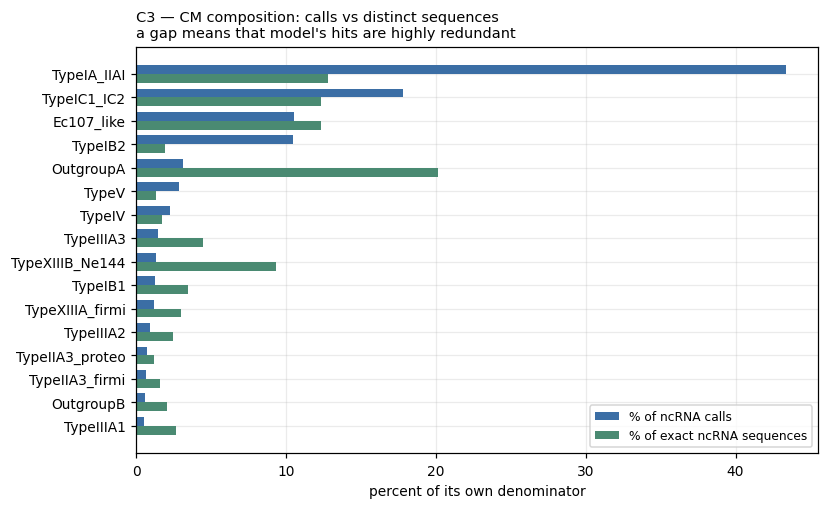

In [26]:
M = pd.read_csv(TABLES / "C3_model_composition.tsv", sep="\t").head(16).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.0, 4.8))
y = np.arange(len(M)); h = 0.38
ax.barh(y + h/2, M.pct_of_calls, height=h, color="#3b6ea5", label="% of ncRNA calls")
ax.barh(y - h/2, M.pct_of_exact_seq, height=h, color="#4a8a72", label="% of exact ncRNA sequences")
ax.set_yticks(y); ax.set_yticklabels(M.detection_model)
ax.set_xlabel("percent of its own denominator"); ax.legend(fontsize=8)
ax.set_title("C3 — CM composition: calls vs distinct sequences\n"
             "a gap means that model's hits are highly redundant", fontsize=9.5, loc="left")
savefig(fig, "C3_model_composition"); plt.show()

**Interpretation.** Call-level and sequence-level composition disagree sharply for the largest
models: `TypeIA_IIAI` and `Ec107_like` produce far more calls per distinct sequence than
`OutgroupA` does. `calls_per_exact_seq` is the redundancy of that model's hits, and it is the same
sequencing-effort effect seen in A2 reappearing on the ncRNA side — a model matching an ncRNA that
sits in a hyper-deposited organism accumulates calls without accumulating diversity.

**Caveat.** Model names are retron subtype labels from the CM library; they are the detector's
vocabulary, not an independent taxonomy of msDNA. Score and E-value medians are comparable
*within* a model only.

---

# D. RT–ncRNA geometry

This is the priority biological output of Stage 1. Everything here is computed on the
**coordinate-derived** geometry (`direction`, `signed_distance_bp`, `same_strand`,
`n_cds_between`). The shipped `position_relative_to_rt` field is **not** used: it is null on
331,897 placements and matches no coordinate frame (artefact 2 in `CONTEXT.md`).

## D1 — Direction: upstream / downstream / overlapping

* **Question.** Where does the ncRNA sit relative to its RT?
* **Unit.** Placement (`V-PAIR-PLACEMENT`).
* **Denominator.** `CANONICAL` placements = 344,154 (geometry-eligible and de-duplicated). The
  `ALL` population (346,722) is shown beside it so the denominator effect is visible.
* **Data.** `rt_ncrna_pairs_v1` → `direction`, `canonical`, `geometry_eligible`, `file_label`.

In [27]:
direc = cache("D1_direction", """
    SELECT 'ALL' AS population, direction, count(*) AS n_placements FROM rt_ncrna_pairs GROUP BY 1,2
    UNION ALL
    SELECT 'ELIGIBLE', direction, count(*) FROM rt_ncrna_pairs WHERE geometry_eligible GROUP BY 1,2
    UNION ALL
    SELECT 'CANONICAL', direction, count(*) FROM rt_ncrna_pairs WHERE canonical GROUP BY 1,2
""")
piv = direc.pivot_table(index="direction", columns="population", values="n_placements", fill_value=0)
piv = piv[["ALL", "ELIGIBLE", "CANONICAL"]]
piv.loc["TOTAL"] = piv.sum()
piv["pct_of_CANONICAL"] = (100 * piv.CANONICAL / piv.loc["TOTAL", "CANONICAL"]).round(3)
display(piv)

print("against g3 / g7:")
for d, k in [("upstream", "up"), ("downstream", "down"), ("overlapping", "overlap")]:
    check(f"canonical {d}", int(piv.loc[d, "CANONICAL"]), k)

strand = cache("D1_same_strand", """
    SELECT canonical, same_strand, count(*) AS n FROM rt_ncrna_pairs GROUP BY 1,2
""")
s = strand[strand.canonical == True]
pct_same = 100 * s.loc[s.same_strand == True, "n"].sum() / s.n.sum()
print(f"\nsame strand, canonical placements: {pct_same:.3f}%  "
      f"(opposite: {int(s.loc[s.same_strand == False, 'n'].sum()):,})")

# g3_same_strand.tsv is the canonical source. NOTE: the g7 REPORT.md prose says "99.8%" for this
# quantity; that string is a hard-coded literal in g7_stage1_report/scripts/findings.py (every
# other number in that sentence is a resolved placeholder) and is NOT in g7_resolved_values.tsv.
# Check against the gate table, which is the authority. See notes/2026-09-16_same_strand_discrepancy.md
g3s = gate_table("dbchar_g3_pair_geometry", "g3_same_strand")
g3c = g3s[g3s.population == "CANONICAL"]
g3_pct = 100 * g3c.loc[g3c.same_strand == True, "n_placements"].sum() / g3c.n_placements.sum()
check("canonical same-strand % (vs g3_same_strand.tsv)", round(pct_same, 3),
      expected=round(g3_pct, 3), tol=1e-3)
print('  [ NOTE] g7 REPORT.md prose states "99.8%" for this quantity — an unregistered literal;'
      f' the gate table gives {g3_pct:.3f}%.')

population,ALL,ELIGIBLE,CANONICAL,pct_of_CANONICAL
direction,,,,
downstream,6819.0,6794.0,6761.0,1.965
overlapping,12338.0,12259.0,12124.0,3.523
upstream,327565.0,326260.0,325269.0,94.513
TOTAL,346722.0,345313.0,344154.0,100.000


against g3 / g7:
  [MATCH] canonical upstream                             recomputed=325269           canonical=325269.0
  [MATCH] canonical downstream                           recomputed=6761             canonical=6761.0
  [MATCH] canonical overlapping                          recomputed=12124            canonical=12124.0

same strand, canonical placements: 99.116%  (opposite: 3,041)
  [MATCH] canonical same-strand % (vs g3_same_strand.tsv) recomputed=99.116           canonical=99.116
  [ NOTE] g7 REPORT.md prose states "99.8%" for this quantity — an unregistered literal; the gate table gives 99.116%.


## D2 — Signed genomic distance, and the technical downstream mode

* **Question.** What is the gap distribution between RT and ncRNA, and what happens to it when the
  contig-start-clipped windows are separated out?
* **Unit.** Placement (`V-PAIR-PLACEMENT`), `CANONICAL`.
* **Denominator.** 344,154 canonical placements; the stratified panel uses the same placements
  split by `true_start_clipped`.
* **Data.** `rt_ncrna_pairs_v1` → `signed_distance_bp`, `direction`, `canonical`,
  `true_start_clipped`, `clipped_end_flag`.
* **Convention.** Negative = ncRNA upstream of the RT; 0 = overlapping; positive = downstream.

In [28]:
dstats = cache("D2_distance_stats", """
    SELECT 'CANONICAL' AS population, direction, count(*) AS n,
           quantile_cont(signed_distance_bp, 0.25) AS q25,
           quantile_cont(signed_distance_bp, 0.50) AS median,
           quantile_cont(signed_distance_bp, 0.75) AS q75,
           min(signed_distance_bp) AS min, max(signed_distance_bp) AS max
    FROM rt_ncrna_pairs WHERE canonical GROUP BY 1,2
    UNION ALL
    SELECT 'CANONICAL_by_clip: ' || CASE WHEN true_start_clipped THEN 'true_start_clipped'
                                         ELSE 'not_clipped' END,
           direction, count(*), quantile_cont(signed_distance_bp, 0.25),
           quantile_cont(signed_distance_bp, 0.50), quantile_cont(signed_distance_bp, 0.75),
           min(signed_distance_bp), max(signed_distance_bp)
    FROM rt_ncrna_pairs WHERE canonical GROUP BY 1,2
    ORDER BY population, direction
""")
display(dstats)
check("canonical upstream median bp",
      float(dstats[(dstats.population == "CANONICAL") & (dstats.direction == "upstream")]["median"].iloc[0]),
      "up_median")

# THE DOWNSTREAM POPULATION IS NOT THE TECHNICAL MODE. g3 defines "the mode" as the placements
# within +/-150 bp of the downstream median (2,682 bp); that is a SUBSET of all downstream
# placements. Reporting "18 distinct ncRNAs" against the whole downstream population overstates
# how narrow it is. Both are computed here with their own denominators.
g3p = gate_table("dbchar_g3_pair_geometry", "g3_downstream_mode_profile").set_index("measure")["value"]
MODE_MEDIAN, MODE_HALFWIDTH = float(g3p["median_signed_distance_bp"]), 150.0

dmode = cache("D2_downstream_strata", f"""
    SELECT 'all canonical downstream' AS stratum, count(*) AS n_placements,
           count(DISTINCT nc_seq_hash) AS n_exact_ncrna, count(DISTINCT rt_seq_hash) AS n_exact_rt,
           count(DISTINCT detection_model) AS n_models,
           quantile_cont(signed_distance_bp, 0.50) AS median_bp,
           100.0 * count(*) FILTER (WHERE true_start_clipped) / count(*) AS pct_true_start_clipped
    FROM rt_ncrna_pairs WHERE canonical AND direction = 'downstream'
    UNION ALL SELECT 'THE MODE: within +/-{MODE_HALFWIDTH:.0f} bp of {MODE_MEDIAN:.0f} bp',
           count(*), count(DISTINCT nc_seq_hash), count(DISTINCT rt_seq_hash),
           count(DISTINCT detection_model), quantile_cont(signed_distance_bp, 0.50),
           100.0 * count(*) FILTER (WHERE true_start_clipped) / count(*)
    FROM rt_ncrna_pairs WHERE canonical AND direction = 'downstream'
      AND abs(signed_distance_bp - {MODE_MEDIAN}) <= {MODE_HALFWIDTH}
    UNION ALL SELECT 'downstream, contig-start-clipped', count(*), count(DISTINCT nc_seq_hash),
           count(DISTINCT rt_seq_hash), count(DISTINCT detection_model),
           quantile_cont(signed_distance_bp, 0.50),
           100.0 * count(*) FILTER (WHERE true_start_clipped) / count(*)
    FROM rt_ncrna_pairs WHERE canonical AND direction = 'downstream' AND true_start_clipped
    UNION ALL SELECT 'downstream, NOT clipped (near-range)', count(*), count(DISTINCT nc_seq_hash),
           count(DISTINCT rt_seq_hash), count(DISTINCT detection_model),
           quantile_cont(signed_distance_bp, 0.50),
           100.0 * count(*) FILTER (WHERE true_start_clipped) / count(*)
    FROM rt_ncrna_pairs WHERE canonical AND direction = 'downstream' AND NOT true_start_clipped
""")
display(dmode.round(2))
check("distinct exact ncRNA in THE MODE",
      int(dmode.loc[dmode.stratum.str.startswith("THE MODE"), "n_exact_ncrna"].iloc[0]),
      "dmode_seqs")
print(f"\n  all canonical downstream carries "
      f"{int(dmode.n_exact_ncrna.iloc[0])} distinct exact ncRNAs, NOT the 18 of the mode.")
print("  the unclipped downstream remainder sits at a median "
      f"{dmode.loc[dmode.stratum.str.contains('NOT clipped'), 'median_bp'].iloc[0]:.0f} bp — "
      "near-range, and NOT explained by the clipping artefact.")

,population,direction,n,q25,median,q75,min,max
0,CANONICAL,downstream,6761,2633.0,2682.0,2730.0,10.0,9083.0
1,CANONICAL,overlapping,12124,0.0,0.0,0.0,0.0,0.0
2,CANONICAL,upstream,325269,-1037.0,-55.0,-27.0,-9287.0,0.0
3,CANONICAL_by_clip: not_clipped,downstream,1041,64.0,64.0,208.0,10.0,9083.0
4,CANONICAL_by_clip: not_clipped,overlapping,8456,0.0,0.0,0.0,0.0,0.0
5,CANONICAL_by_clip: not_clipped,upstream,275881,-1037.0,-55.0,-31.0,-9287.0,0.0
6,CANONICAL_by_clip: true_start_clipped,downstream,5720,2636.0,2683.0,2730.0,11.0,8952.0
7,CANONICAL_by_clip: true_start_clipped,overlapping,3668,0.0,0.0,0.0,0.0,0.0
8,CANONICAL_by_clip: true_start_clipped,upstream,49388,-664.0,-39.0,-22.0,-8666.0,0.0


  [MATCH] canonical upstream median bp                   recomputed=-55.0            canonical=-55.0


,stratum,n_placements,n_exact_ncrna,n_exact_rt,n_models,median_bp,pct_true_start_clipped
0,all canonical downstream,6761,230,440,19,2682.0,84.60
1,THE MODE: within +/-150 bp of 2682 bp,5234,18,126,3,2714.5,99.81
2,"downstream, contig-start-clipped",5720,107,266,16,2683.0,100.00
3,"downstream, NOT clipped (near-range)",1041,149,207,19,64.0,0.00


  [MATCH] distinct exact ncRNA in THE MODE               recomputed=18               canonical=18.0

  all canonical downstream carries 230 distinct exact ncRNAs, NOT the 18 of the mode.
  the unclipped downstream remainder sits at a median 64 bp — near-range, and NOT explained by the clipping artefact.


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


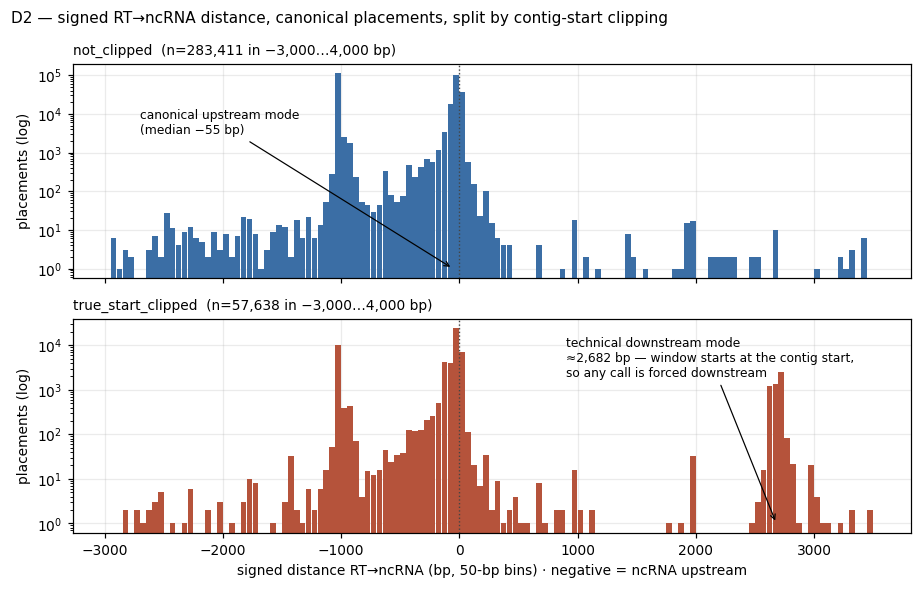

In [29]:
hist = cache("D2_distance_histogram", """
    SELECT CASE WHEN true_start_clipped THEN 'true_start_clipped' ELSE 'not_clipped' END AS stratum,
           50 * floor(signed_distance_bp / 50.0) AS bin_start,
           count(*) AS n
    FROM rt_ncrna_pairs
    WHERE canonical AND signed_distance_bp BETWEEN -3000 AND 4000
    GROUP BY 1, 2 ORDER BY 1, 2
""")
H = pd.read_csv(TABLES / "D2_distance_histogram.tsv", sep="\t")

fig, axes = plt.subplots(2, 1, figsize=(8.4, 5.4), sharex=True)
for ax, (stratum, color) in zip(axes, [("not_clipped", "#3b6ea5"), ("true_start_clipped", "#b5533b")]):
    h = H[H.stratum == stratum]
    ax.bar(h.bin_start, h.n, width=48, color=color, align="edge")
    ax.set_yscale("log"); ax.set_ylabel("placements (log)")
    ax.axvline(0, color="#444", lw=0.9, ls=":")
    ax.set_title(f"{stratum}  (n={int(h.n.sum()):,} in −3,000…4,000 bp)", fontsize=9, loc="left")
axes[1].set_xlabel("signed distance RT→ncRNA (bp, 50-bp bins) · negative = ncRNA upstream")
axes[0].annotate("canonical upstream mode\n(median −55 bp)", xy=(-55, 1), xytext=(-2700, 3e3),
                 fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
axes[1].annotate("technical downstream mode\n≈2,682 bp — window starts at the contig start,\n"
                 "so any call is forced downstream", xy=(2682, 1), xytext=(900, 2e3),
                 fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
fig.suptitle("D2 — signed RT→ncRNA distance, canonical placements, split by contig-start clipping",
             fontsize=10, x=0.01, ha="left")
fig.tight_layout(); savefig(fig, "D2_distance_distribution"); plt.show()

**Interpretation.** The biological signal is a tight upstream mode at a median **−55 bp**: the
ncRNA sits immediately 5′ of the RT, typically with no intervening CDS (D3). The apparently
bimodal distance distribution resolves once the strata are separated — the second mode at
~2,682 bp lives almost entirely in the `true_start_clipped` stratum, contains only 18 distinct
ncRNA sequences, and is an artefact of windows that begin at the contig start, where any call is
*forced* to appear downstream.

**Two populations must not be conflated here.** *All* canonical downstream placements number
**6,761 over 230 distinct exact ncRNA sequences**. *The technical mode* — defined by g3 as the
placements within ±150 bp of the 2,682 bp downstream median — is **5,234 placements (77.4 % of
downstream) over just 18 distinct ncRNA sequences, 126 exact RTs and 15 species, dominated by a
single `ncbi_bacteria` / Retron / `TypeV` stratum that is 99.96 % contig-start-clipped**. The
"18 sequences" figure belongs to the mode, not to downstream placements generally.

Separating the strata also surfaces something the artefact was hiding: the **1,041 downstream
placements that are *not* contig-start-clipped sit at a median of only 64 bp over 149 distinct
ncRNA sequences** — a genuine near-range downstream population that the technical mode does not
explain and that deserves its own examination.

**Caveat.** Do not use the technical mode as a prior for anything. Overlapping placements are
reported as distance 0 by construction, so the zero bin is a category, not a measurement. The
near-range unclipped downstream group above is a *description*; whether those are inverted
arrangements, mis-assigned RT boundaries or a distinct architecture is not established here.

## D3 — Intervening CDS and strand

* **Question.** How often is the RT–ncRNA arrangement a clean operon-like adjacency, with nothing
  transcribed between them?
* **Unit.** Placement (`V-PAIR-PLACEMENT`), `CANONICAL`.
* **Denominator.** 344,154 canonical placements.
* **Data.** `rt_ncrna_pairs_v1` → `n_cds_between`, `cds_between_bin`, `same_strand`,
  `overlaps_rt_cds`, `overlaps_non_rt_cds`.

In [30]:
cds = cache("D3_cds_between", """
    SELECT CASE WHEN n_cds_between >= 4 THEN '>3' ELSE CAST(n_cds_between AS VARCHAR) END AS n_cds_between,
           least(n_cds_between, 4) AS ord, count(*) AS n_placements
    FROM rt_ncrna_pairs WHERE canonical GROUP BY 1, 2 ORDER BY ord
""")
tot = cds.n_placements.sum()
cds["pct_of_canonical"] = (100 * cds.n_placements / tot).round(4)
save(cds, "D3_cds_between")
display(cds[["n_cds_between", "n_placements", "pct_of_canonical"]])
print("against g3_cds_between_explicit:")
for lab, key in [("0", "cds0"), ("1", "cds1"), (">3", "cds_gt3")]:
    check(f"{lab} CDS between", float(cds.loc[cds.n_cds_between == lab, "pct_of_canonical"].iloc[0]),
          key, tol=1e-3)

ov = cache("D3_overlap_profile", """
    SELECT overlaps_rt_cds, overlaps_non_rt_cds, same_strand, count(*) AS n
    FROM rt_ncrna_pairs WHERE canonical GROUP BY 1,2,3 ORDER BY n DESC
""")
display(ov.head(10))

,n_cds_between,n_placements,pct_of_canonical
0,0,324904,94.4066
1,1,12427,3.6109
2,2,939,0.2728
3,3,544,0.1581
4,>3,5340,1.5516


against g3_cds_between_explicit:
  [MATCH] 0 CDS between                                  recomputed=94.4066          canonical=94.4066
  [MATCH] 1 CDS between                                  recomputed=3.6109           canonical=3.6109
  [MATCH] >3 CDS between                                 recomputed=1.5516           canonical=1.5516


,overlaps_rt_cds,overlaps_non_rt_cds,same_strand,n
0,False,False,True,275491
1,False,True,True,53355
2,True,False,True,11788
3,False,False,False,2954
4,NaN,False,True,403
5,NaN,True,True,76
6,False,True,False,71
7,True,False,False,16


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


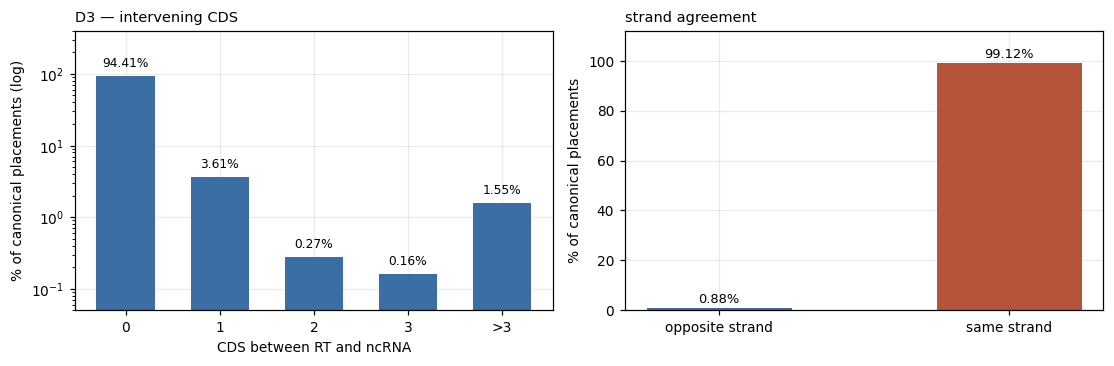

In [31]:
Cd = pd.read_csv(TABLES / "D3_cds_between.tsv", sep="\t").sort_values("ord")
St = pd.read_csv(TABLES / "D1_same_strand.tsv", sep="\t")
St = St[St.canonical == True]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.4))
ax = axes[0]
ax.bar(Cd.n_cds_between.astype(str), Cd.pct_of_canonical, color="#3b6ea5", width=0.62)
for x, v in zip(range(len(Cd)), Cd.pct_of_canonical):
    ax.text(x, v * 1.35, f"{v:.2f}%", ha="center", fontsize=8)
ax.set_yscale("log"); ax.set_ylim(0.05, 400)
ax.set_xlabel("CDS between RT and ncRNA"); ax.set_ylabel("% of canonical placements (log)")
ax.set_title("D3 — intervening CDS", fontsize=9.5, loc="left")

ax = axes[1]
lab = ["same strand" if b else "opposite strand" for b in St.same_strand]
ax.bar(lab, 100 * St.n / St.n.sum(), color=["#3b6ea5", "#b5533b"], width=0.5)
for x, v in enumerate(100 * St.n.values / St.n.sum()):
    ax.text(x, v + 2, f"{v:.2f}%", ha="center", fontsize=8.5)
ax.set_ylim(0, 112); ax.set_ylabel("% of canonical placements")
ax.set_title("strand agreement", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "D3_cds_and_strand"); plt.show()

**Interpretation.** **94.41 %** of canonical placements have *no* CDS between the RT and its ncRNA,
and **99.12 %** are on the same strand (`g3_same_strand.tsv`; the g7 report prose says 99.8 %, an
unregistered literal — see D1 and `notes/`). Combined with the −55 bp median gap of D2, the dominant
genomic arrangement is a close, same-strand, 5′ adjacency with no annotated CDS between the two
features. **This is an arrangement, not a demonstrated transcriptional relationship** — these
coordinates are compatible with cotranscription but do not establish it, and nothing here speaks
to cognate RT–ncRNA recognition. The ~5.6 % with intervening CDS and the ~0.88 % opposite-strand cases (3,041 placements) are retained as
atypical biology, not filtered (project convention).

**Caveat.** `n_cds_between` depends on the annotation present in the extracted window. A window
with sparse Prodigal calls will show "0 CDS between" for a reason that is annotational, not
genomic. Overlapping placements are their own category and by definition have no gap to populate.

## D4 — Geometry by RT family

* **Question.** Do the non-Retron families whose loci *do* carry a retron-CM call show the same
  geometry as Retron loci?
* **Unit.** Placement (`V-PAIR-PLACEMENT`), geometry-eligible.
* **Denominator.** Eligible placements **of that family label**. Note how small the non-Retron
  denominators are — this is the detector-scope effect of C1, not a family-size effect.
* **Data.** `rt_ncrna_pairs_v1` → `file_label`, `direction`, `same_strand`,
  `signed_distance_bp`, `n_cds_between`, `geometry_eligible`.

In [32]:
geo = cache("D4_geometry_by_family", """
    SELECT file_label, count(*) AS n_placements,
           100.0 * count(*) FILTER (WHERE direction = 'upstream')    / count(*) AS pct_upstream,
           100.0 * count(*) FILTER (WHERE direction = 'downstream')  / count(*) AS pct_downstream,
           100.0 * count(*) FILTER (WHERE direction = 'overlapping') / count(*) AS pct_overlapping,
           100.0 * count(*) FILTER (WHERE same_strand)               / count(*) AS pct_same_strand,
           100.0 * count(*) FILTER (WHERE n_cds_between = 0)         / count(*) AS pct_no_cds_between,
           quantile_cont(signed_distance_bp, 0.50)                              AS median_signed_bp,
           count(DISTINCT nc_seq_hash)                                          AS n_exact_ncrna
    FROM rt_ncrna_pairs WHERE geometry_eligible
    GROUP BY 1 ORDER BY n_placements DESC
""")
display(geo.round(2))
print("\nnon-Retron single-family eligible placements (the g3 candidate population):")
nr = geo[(geo.file_label != "Retron") & (geo.file_label != "MULTI")]
print(f"  n_placements = {int(nr.n_placements.sum()):,}   "
      f"pct_upstream = {100 * (nr.pct_upstream * nr.n_placements / 100).sum() / nr.n_placements.sum():.3f}%")
check("non-Retron eligible placements", int(nr.n_placements.sum()), "nonretron")

,file_label,n_placements,pct_upstream,pct_downstream,pct_overlapping,pct_same_strand,pct_no_cds_between,median_signed_bp,n_exact_ncrna
0,Retron,345047,94.51,1.94,3.55,99.13,94.45,-46.0,16351
1,RVT-GII,137,70.07,29.20,0.73,48.18,32.12,-498.0,63
2,RVT-DGRs,51,39.22,58.82,1.96,72.55,11.76,2149.0,22
3,RVT-UG2,11,18.18,81.82,0.00,100.00,0.00,7704.0,2
4,RVT-UG14,10,100.00,0.00,0.00,100.00,100.00,-15.0,1
5,RVT-UG26,10,0.00,100.00,0.00,80.00,20.00,4451.0,3
6,RVT-AbiP2,9,77.78,22.22,0.00,0.00,77.78,-348.0,2
7,RVT-UG10,9,33.33,66.67,0.00,33.33,66.67,100.0,2
8,MULTI,6,50.00,50.00,0.00,66.67,0.00,1332.5,5
9,RVT-UG12,4,75.00,25.00,0.00,100.00,75.00,-362.0,2



non-Retron single-family eligible placements (the g3 candidate population):
  n_placements = 260   pct_upstream = 57.692%
  [MATCH] non-Retron eligible placements                 recomputed=260              canonical=260.0


True

/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


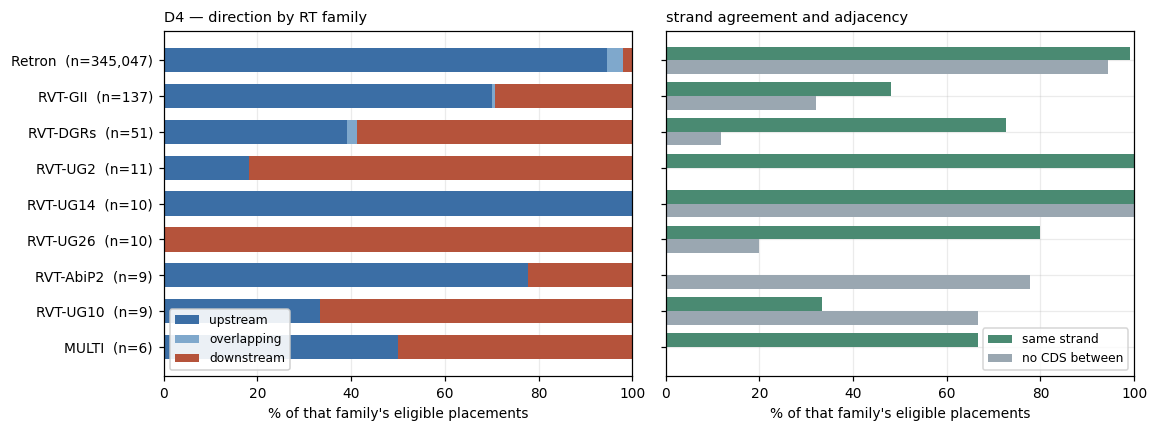

In [33]:
G = pd.read_csv(TABLES / "D4_geometry_by_family.tsv", sep="\t")
G = G[G.n_placements >= 5].sort_values("n_placements", ascending=False).head(12).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0), sharey=True)
y = np.arange(len(G))
ax = axes[0]
left = np.zeros(len(G))
for col, c, lab in [("pct_upstream", "#3b6ea5", "upstream"),
                    ("pct_overlapping", "#7fa8cc", "overlapping"),
                    ("pct_downstream", "#b5533b", "downstream")]:
    ax.barh(y, G[col], left=left, color=c, label=lab, height=0.68); left += G[col].values
ax.set_yticks(y)
ax.set_yticklabels([f"{f}  (n={int(n):,})" for f, n in zip(G.file_label, G.n_placements)])
ax.set_xlim(0, 100); ax.set_xlabel("% of that family's eligible placements")
ax.legend(fontsize=8, loc="lower left", framealpha=0.9)
ax.set_title("D4 — direction by RT family", fontsize=9.5, loc="left")

ax = axes[1]
h = 0.38
ax.barh(y + h/2, G.pct_same_strand, height=h, color="#4a8a72", label="same strand")
ax.barh(y - h/2, G.pct_no_cds_between, height=h, color="#9aa7b1", label="no CDS between")
ax.set_xlim(0, 100); ax.set_xlabel("% of that family's eligible placements"); ax.legend(fontsize=8)
ax.set_title("strand agreement and adjacency", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "D4_geometry_by_family"); plt.show()

**Interpretation.** Retron placements dominate the eligible population and set the canonical
geometry. The non-Retron families that carry a retron-CM call amount to only a few hundred
placements in total, with a markedly weaker upstream preference (~57.7 % vs Retron's ~95 %). Stage 1
retains these as a **candidate** population and explicitly does **not** call them novel retrons.

**Caveat.** The per-family denominators here differ by four orders of magnitude, so a percentage on
a family with n < 50 is not comparable to Retron's. These placements exist because a retron CM
matched next to a non-Retron RT; the first hypotheses to exclude are CM cross-matching and
RT-family mislabelling, not novel biology. The 266-row candidate table
(`rt_ncrna_nonretron_candidates_v1`) is examined in section I — note that the report's **260** is
its single-family subset, with 6 MULTI rows held out.

## D5 — Strand agreement, and what the opposite-strand placements actually are

* **Question.** What is the correct same-strand rate, and are the opposite-strand placements a
  scattered error tail or a structured population?
* **Unit.** Placement (`V-PAIR-PLACEMENT`), `CANONICAL`; MULTI additionally held out for the
  `POP_RT`-consistent figure.
* **Denominator.** 344,154 canonical placements (and 344,148 with MULTI removed). Sub-profiles use
  the 3,041 opposite-strand placements as their own denominator and say so.
* **Data.** `rt_ncrna_pairs_v1` → `same_strand`, `direction`, `signed_distance_bp`,
  `n_cds_between`, `true_start_clipped`, `rt_strand`, `detection_model`, `file_label`,
  `nc_seq_hash`, `rt_seq_hash`, `canonical`.

**Why this section exists.** The g7 REPORT.md prose states 99.8 % same-strand. That string is a
hard-coded literal in `dbchar_g7_stage1_report/scripts/findings.py:190` — every other number in
that sentence is a placeholder resolved from `g7_resolved_values.tsv`, and there is no
`same_strand` key in that registry. The gate table `g3_same_strand.tsv` says **99.12 %**. Rather
than restate the correct number, this section measures it under every relevant population and then
characterises the difference the two numbers are arguing about.

In [34]:
# 1. the rate under every population, so the figure cannot be quoted without its denominator
rates = cache("D5_same_strand_by_population", f"""
    SELECT 'ALL placements' AS population, count(*) AS n,
           count(*) FILTER (WHERE same_strand) AS n_same,
           count(*) FILTER (WHERE NOT same_strand) AS n_opposite FROM rt_ncrna_pairs
    UNION ALL SELECT 'ELIGIBLE', count(*), count(*) FILTER (WHERE same_strand),
           count(*) FILTER (WHERE NOT same_strand) FROM rt_ncrna_pairs WHERE geometry_eligible
    UNION ALL SELECT 'CANONICAL', count(*), count(*) FILTER (WHERE same_strand),
           count(*) FILTER (WHERE NOT same_strand) FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'CANONICAL, MULTI held out (POP_RT-consistent)', count(*),
           count(*) FILTER (WHERE same_strand), count(*) FILTER (WHERE NOT same_strand)
           FROM rt_ncrna_pairs WHERE canonical AND file_label <> 'MULTI'
    UNION ALL SELECT 'CANONICAL, Retron only', count(*), count(*) FILTER (WHERE same_strand),
           count(*) FILTER (WHERE NOT same_strand) FROM rt_ncrna_pairs
           WHERE canonical AND file_label = 'Retron'
""")
rates["pct_same_strand"] = (100 * rates.n_same / rates.n).round(3)
save(rates, "D5_same_strand_by_population")
display(rates)

g3s = gate_table("dbchar_g3_pair_geometry", "g3_same_strand")
g3c = g3s[g3s.population == "CANONICAL"]
g3_pct = 100 * g3c.loc[g3c.same_strand == True, "n_placements"].sum() / g3c.n_placements.sum()
check("CANONICAL same-strand % (vs g3_same_strand.tsv)",
      float(rates.loc[rates.population == "CANONICAL", "pct_same_strand"].iloc[0]),
      expected=round(g3_pct, 3), tol=1e-3)

print('\n  provenance of the disputed figure:')
print('    g3_same_strand.tsv (gate table)          -> %.3f%%   REGISTERED, reproduced above' % g3_pct)
print('    g7 REPORT.md prose                       -> 99.8%     hard-coded literal, findings.py:190')
print('    g7_resolved_values.tsv                   -> %s' %
      ("absent — the quantity was never registered"
       if not (RESOLVED.key.str.contains("strand")).any() else "present"))

,population,n,n_same,n_opposite,pct_same_strand
0,ALL placements,346722,343625,3097,99.107
1,ELIGIBLE,345313,342218,3095,99.104
2,CANONICAL,344154,341113,3041,99.116
3,"CANONICAL, MULTI held out (POP_RT-consistent)",344148,341109,3039,99.117
4,"CANONICAL, Retron only",343892,340961,2931,99.148


  [MATCH] CANONICAL same-strand % (vs g3_same_strand.tsv) recomputed=99.116           canonical=99.116

  provenance of the disputed figure:
    g3_same_strand.tsv (gate table)          -> 99.116%   REGISTERED, reproduced above
    g7 REPORT.md prose                       -> 99.8%     hard-coded literal, findings.py:190
    g7_resolved_values.tsv                   -> absent — the quantity was never registered


In [35]:
# 2. are the 3,041 opposite-strand placements noise, or structured?
prof = cache("D5_opposite_strand_profile", """
    SELECT CASE WHEN same_strand THEN 'same strand' ELSE 'opposite strand' END AS stratum,
           count(*) AS n_placements,
           count(DISTINCT nc_seq_hash) AS n_exact_ncrna,
           count(DISTINCT rt_seq_hash) AS n_exact_rt,
           count(DISTINCT detection_model) AS n_models,
           quantile_cont(signed_distance_bp, 0.50) AS median_signed_bp,
           100.0 * count(*) FILTER (WHERE n_cds_between = 0) / count(*) AS pct_no_cds_between,
           100.0 * count(*) FILTER (WHERE true_start_clipped) / count(*) AS pct_true_start_clipped,
           100.0 * count(*) FILTER (WHERE rt_strand = '-') / count(*) AS pct_rt_on_minus_strand
    FROM rt_ncrna_pairs WHERE canonical GROUP BY 1
""")
display(prof.round(2))

comp = cache("D5_opposite_strand_composition", """
    SELECT 'detection_model' AS dimension, detection_model AS value, count(*) AS n
    FROM rt_ncrna_pairs WHERE canonical AND NOT same_strand GROUP BY 1, 2
    UNION ALL SELECT 'file_label', file_label, count(*)
    FROM rt_ncrna_pairs WHERE canonical AND NOT same_strand GROUP BY 1, 2
    UNION ALL SELECT 'direction', direction, count(*)
    FROM rt_ncrna_pairs WHERE canonical AND NOT same_strand GROUP BY 1, 2
    ORDER BY dimension, n DESC
""")
n_opp = int(comp[comp.dimension == "file_label"].n.sum())
comp["pct_of_opposite"] = (100 * comp.n / n_opp).round(2)
save(comp, "D5_opposite_strand_composition")
for dim in ["detection_model", "file_label", "direction"]:
    print(f"\n-- {dim} (denominator: {n_opp:,} opposite-strand canonical placements)")
    display(comp[comp.dimension == dim].head(6)[["value", "n", "pct_of_opposite"]])

,stratum,n_placements,n_exact_ncrna,n_exact_rt,n_models,median_signed_bp,pct_no_cds_between,pct_true_start_clipped,pct_rt_on_minus_strand
0,opposite strand,3041,288,439,19,-4750.0,12.53,33.77,51.20
1,same strand,341113,15731,28544,21,-44.0,95.14,16.93,34.02



-- detection_model (denominator: 3,041 opposite-strand canonical placements)


,value,n,pct_of_opposite
0,TypeXIIIA_firmi,2571,84.54
1,TypeIB1,143,4.70
2,OutgroupA,118,3.88
3,TypeIC1_IC2,100,3.29
4,TypeXIIIC_Mx162,17,0.56
5,TypeIIIA2,15,0.49



-- file_label (denominator: 3,041 opposite-strand canonical placements)


,value,n,pct_of_opposite
22,Retron,2931,96.38
23,RVT-GII,71,2.33
24,RVT-DGRs,14,0.46
25,RVT-AbiP2,9,0.30
26,RVT-UG10,6,0.20
27,RVT-UG23,3,0.10



-- direction (denominator: 3,041 opposite-strand canonical placements)


,value,n,pct_of_opposite
19,upstream,2964,97.47
20,downstream,61,2.01
21,overlapping,16,0.53


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


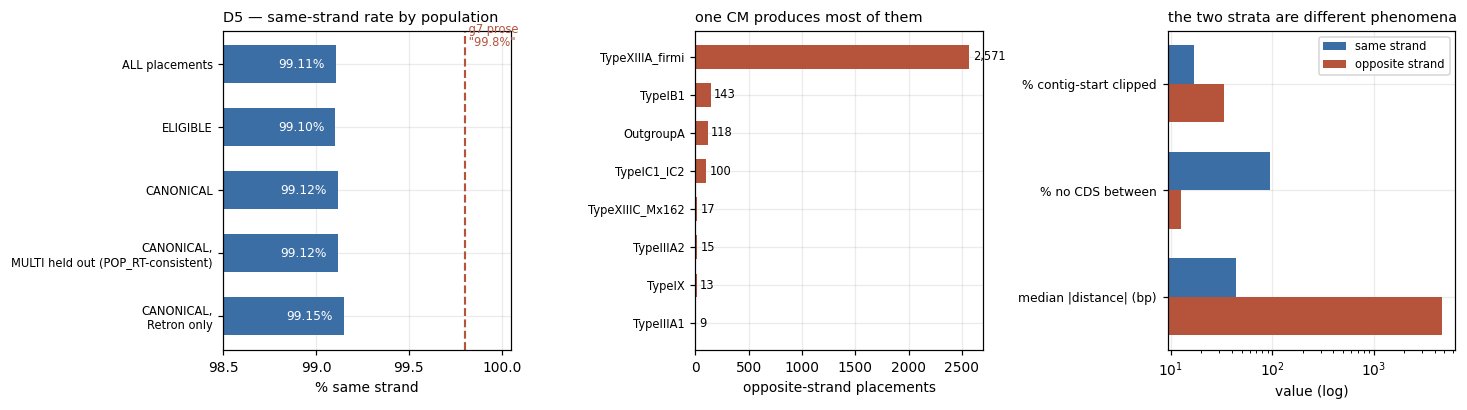

In [36]:
P = pd.read_csv(TABLES / "D5_same_strand_by_population.tsv", sep="\t")
C = pd.read_csv(TABLES / "D5_opposite_strand_composition.tsv", sep="\t")
PR = pd.read_csv(TABLES / "D5_opposite_strand_profile.tsv", sep="\t")

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.8))

ax = axes[0]
p = P.iloc[::-1]
ax.barh(np.arange(len(p)), p.pct_same_strand, color="#3b6ea5", height=0.6)
for i, v in enumerate(p.pct_same_strand):
    ax.text(v - 0.06, i, f"{v:.2f}%", va="center", ha="right", fontsize=8, color="white")
ax.axvline(99.8, color="#b5533b", lw=1.4, ls="--")
ax.text(99.8, len(p) - 0.35, ' g7 prose\n "99.8%"', color="#b5533b", fontsize=7.5, va="top")
ax.set_yticks(np.arange(len(p)))
ax.set_yticklabels([t.replace(", ", ",\n") for t in p.population], fontsize=7.5)
ax.set_xlim(98.5, 100.05); ax.set_xlabel("% same strand")
ax.set_title("D5 — same-strand rate by population", fontsize=9.5, loc="left")

ax = axes[1]
m = C[C.dimension == "detection_model"].sort_values("n").tail(8)
ax.barh(m.value, m.n, color="#b5533b", height=0.62)
for i, (v, n) in enumerate(zip(m.value, m.n)):
    ax.text(n + 30, i, f"{n:,}", va="center", fontsize=7.5)
ax.set_xlabel("opposite-strand placements")
ax.tick_params(axis="y", labelsize=7.5)
ax.set_title("one CM produces most of them", fontsize=9.5, loc="left")

ax = axes[2]
labels = ["median |distance| (bp)", "% no CDS between", "% contig-start clipped"]
same = PR[PR.stratum == "same strand"].iloc[0]
opp  = PR[PR.stratum == "opposite strand"].iloc[0]
vals_same = [abs(same.median_signed_bp), same.pct_no_cds_between, same.pct_true_start_clipped]
vals_opp  = [abs(opp.median_signed_bp),  opp.pct_no_cds_between,  opp.pct_true_start_clipped]
y = np.arange(len(labels)); h = 0.36
ax.barh(y + h/2, vals_same, height=h, color="#3b6ea5", label="same strand")
ax.barh(y - h/2, vals_opp,  height=h, color="#b5533b", label="opposite strand")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("value (log)"); ax.legend(fontsize=7.5)
ax.set_title("the two strata are different phenomena", fontsize=9.5, loc="left")

fig.tight_layout(); savefig(fig, "D5_strand_agreement"); plt.show()

**Interpretation.** The same-strand rate is **99.12 %** on canonical placements, and it barely moves
across populations (99.12 % on ALL, ELIGIBLE, CANONICAL, and with MULTI held out) — so the gap to
the prose's 99.8 % is not a denominator disagreement. The gate table is right and the report
sentence is an unregistered literal.

The more useful result is what the 3,041 opposite-strand placements *are*: **not an error tail**.
They are strongly structured —

* **2,571 of 3,041 (84.5 %) come from one covariance model, `TypeXIIIA_firmi`**, and 96 % sit at
  Retron loci;
* their median distance is **−4,750 bp** against −44 bp for same-strand placements;
* only **12.5 %** have no intervening CDS, against 95.1 % for same-strand placements;
* they collapse onto just **288 distinct ncRNA sequences** over 439 exact RTs, with one sequence
  alone accounting for 452 placements.

So the opposite-strand stratum is a distant, CDS-separated, single-CM population — architecturally
a *different thing* from the canonical adjacent retron arrangement, and the leading hypothesis is
TypeXIII CM matching at distance rather than an inverted retron. Rounding it away into "99.8 %
same strand" is precisely what loses it.

**Caveat.** This is a description, not an identification: nothing here shows what those 288
sequences are. Before any of them is read as biology, the CM cross-matching hypothesis has to be
excluded on the same evidence standard used for the 266 non-Retron candidates (section I) — and
the same-strand comparison bars above use a log axis precisely because the two strata differ by
two orders of magnitude on distance, which no linear panel would show honestly.

## D6 — Joint geometry, and whether repeated sequences drive it

* **Question.** The D1–D3 marginals each describe one axis. How do direction, strand, distance and
  intervening-CDS count co-occur, and does the dominant arrangement survive when repeated
  observations of the same sequence or the same physical locus are collapsed?
* **Unit.** Placement (`V-PAIR-PLACEMENT`), then the same set re-weighted to one row per **physical
  locus** and one row per **exact (RT, ncRNA) pair**.
* **Denominator.** 344,154 canonical placements; the distinct physical loci carrying one; and the
  **30,427 exact pairs derivable from canonical placements**. Note this is *not* the registered
  exact-pair view (30,924), which is built on the wider ELIGIBLE population — see F0. Each column
  is stated on its own row; the three are comparable as *compositions* only, never as counts.
* **Data.** `rt_ncrna_pairs_v1` → `direction`, `same_strand`, `signed_distance_bp`,
  `n_cds_between`, `physical_locus_key`, `rt_seq_hash`, `nc_seq_hash`, `canonical`, `file_label`.

In [37]:
# The joint profile: one row per observed (direction, strand, adjacency, distance band) combination.
joint = cache("D6_joint_geometry", """
    WITH j AS (
      SELECT direction,
             CASE WHEN same_strand THEN 'same' ELSE 'opposite' END AS strand,
             CASE WHEN n_cds_between = 0 THEN 'no CDS between' ELSE '>=1 CDS between' END AS adjacency,
             CASE WHEN direction = 'overlapping' THEN 'overlapping (0)'
                  WHEN abs(signed_distance_bp) <= 200  THEN '<=200 bp'
                  WHEN abs(signed_distance_bp) <= 1000 THEN '200-1000 bp'
                  WHEN abs(signed_distance_bp) <= 5000 THEN '1-5 kb'
                  ELSE '>5 kb' END AS distance_band,
             physical_locus_key, rt_seq_hash, nc_seq_hash
      FROM rt_ncrna_pairs WHERE canonical)
    SELECT direction, strand, adjacency, distance_band,
           count(*)                                        AS n_placements,
           count(DISTINCT physical_locus_key)              AS n_physical_loci,
           count(DISTINCT (rt_seq_hash, nc_seq_hash))      AS n_exact_pairs
    FROM j GROUP BY 1,2,3,4 ORDER BY n_placements DESC
""")
for col, tot in [("n_placements", None), ("n_physical_loci", None), ("n_exact_pairs", None)]:
    joint["pct_" + col.replace("n_", "")] = (100 * joint[col] / joint[col].sum()).round(3)
save(joint, "D6_joint_geometry")
print(f"{len(joint)} distinct geometry combinations observed.\n")
display(joint.head(12))

top = joint.iloc[0]
print(f"\ndominant combination: {top.direction} / {top.strand} strand / {top.adjacency} / "
      f"{top.distance_band}")
print(f"  {top.pct_placements:.2f}% of placements | {top.pct_physical_loci:.2f}% of physical loci "
      f"| {top.pct_exact_pairs:.2f}% of exact pairs")
print("\nagreement across the three columns means the combination is NOT carried by repeated")
print("observation of the same locus or the same sequence pair; divergence localises where it is.")
joint["pair_vs_placement_shift"] = (joint.pct_exact_pairs - joint.pct_placements).round(2)
print("\nlargest shifts between placement-weighted and pair-weighted composition:")
display(joint.reindex(joint.pair_vs_placement_shift.abs().sort_values(ascending=False).index)
             .head(6)[["direction", "strand", "adjacency", "distance_band",
                       "pct_placements", "pct_exact_pairs", "pair_vs_placement_shift"]])
save(joint, "D6_joint_geometry")

26 distinct geometry combinations observed.



,direction,strand,adjacency,distance_band,n_placements,n_physical_loci,n_exact_pairs,pct_placements,pct_physical_loci,pct_exact_pairs,pair_vs_placement_shift
0,upstream,same,no CDS between,<=200 bp,190038,156748,22528,55.219,52.618,73.860,18.64
1,upstream,same,no CDS between,1-5 kb,112969,108849,901,32.825,36.539,2.954,-29.87
2,overlapping,same,no CDS between,overlapping (0),12108,8938,3148,3.518,3.000,10.321,6.80
3,upstream,same,>=1 CDS between,1-5 kb,9578,8333,597,2.783,2.797,1.957,-0.83
4,upstream,same,no CDS between,200-1000 bp,8300,6140,1885,2.412,2.061,6.180,3.77
5,downstream,same,>=1 CDS between,1-5 kb,5436,5359,196,1.580,1.799,0.643,-0.94
6,upstream,opposite,>=1 CDS between,1-5 kb,2310,1234,270,0.671,0.414,0.885,0.21
7,upstream,same,>=1 CDS between,200-1000 bp,1309,940,429,0.380,0.316,1.407,1.03
8,downstream,same,no CDS between,<=200 bp,887,558,145,0.258,0.187,0.475,0.22
9,upstream,opposite,no CDS between,<=200 bp,312,196,98,0.091,0.066,0.321,0.23



dominant combination: upstream / same strand / no CDS between / <=200 bp
  55.22% of placements | 52.62% of physical loci | 73.86% of exact pairs

agreement across the three columns means the combination is NOT carried by repeated
observation of the same locus or the same sequence pair; divergence localises where it is.

largest shifts between placement-weighted and pair-weighted composition:


,direction,strand,adjacency,distance_band,pct_placements,pct_exact_pairs,pair_vs_placement_shift
1,upstream,same,no CDS between,1-5 kb,32.825,2.954,-29.87
0,upstream,same,no CDS between,<=200 bp,55.219,73.860,18.64
2,overlapping,same,no CDS between,overlapping (0),3.518,10.321,6.80
4,upstream,same,no CDS between,200-1000 bp,2.412,6.180,3.77
7,upstream,same,>=1 CDS between,200-1000 bp,0.380,1.407,1.03
5,downstream,same,>=1 CDS between,1-5 kb,1.580,0.643,-0.94


,direction,strand,adjacency,distance_band,n_placements,n_physical_loci,n_exact_pairs,pct_placements,pct_physical_loci,pct_exact_pairs,pair_vs_placement_shift
0,upstream,same,no CDS between,<=200 bp,190038,156748,22528,55.219,52.618,73.860,18.64
1,upstream,same,no CDS between,1-5 kb,112969,108849,901,32.825,36.539,2.954,-29.87
2,overlapping,same,no CDS between,overlapping (0),12108,8938,3148,3.518,3.000,10.321,6.80
3,upstream,same,>=1 CDS between,1-5 kb,9578,8333,597,2.783,2.797,1.957,-0.83
4,upstream,same,no CDS between,200-1000 bp,8300,6140,1885,2.412,2.061,6.180,3.77
5,downstream,same,>=1 CDS between,1-5 kb,5436,5359,196,1.580,1.799,0.643,-0.94
6,upstream,opposite,>=1 CDS between,1-5 kb,2310,1234,270,0.671,0.414,0.885,0.21
7,upstream,same,>=1 CDS between,200-1000 bp,1309,940,429,0.380,0.316,1.407,1.03
8,downstream,same,no CDS between,<=200 bp,887,558,145,0.258,0.187,0.475,0.22
9,upstream,opposite,no CDS between,<=200 bp,312,196,98,0.091,0.066,0.321,0.23


In [38]:
# Concentration: how much of the placement population is carried by how few distinct pairs?
conc = cache("D6_weighting_comparison", """
    SELECT 'placements'    AS weighting, count(*)                                   AS n FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'distinct physical loci', count(DISTINCT physical_locus_key)     FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'distinct exact pairs',   count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'distinct exact RTs',     count(DISTINCT rt_seq_hash)           FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'distinct exact ncRNAs',  count(DISTINCT nc_seq_hash)           FROM rt_ncrna_pairs WHERE canonical
""")
display(conc)

# the four headline marginals under all three weightings
marg = cache("D6_marginals_by_weighting", """
    WITH j AS (SELECT direction, same_strand, n_cds_between, physical_locus_key,
                      rt_seq_hash, nc_seq_hash FROM rt_ncrna_pairs WHERE canonical)
    SELECT 'upstream' AS measure,
           100.0 * count(*) FILTER (WHERE direction = 'upstream') / count(*) AS pct_placements,
           100.0 * count(DISTINCT physical_locus_key) FILTER (WHERE direction = 'upstream')
                 / count(DISTINCT physical_locus_key) AS pct_physical_loci,
           100.0 * count(DISTINCT (rt_seq_hash, nc_seq_hash)) FILTER (WHERE direction = 'upstream')
                 / count(DISTINCT (rt_seq_hash, nc_seq_hash)) AS pct_exact_pairs FROM j
    UNION ALL SELECT 'same strand',
           100.0 * count(*) FILTER (WHERE same_strand) / count(*),
           100.0 * count(DISTINCT physical_locus_key) FILTER (WHERE same_strand)
                 / count(DISTINCT physical_locus_key),
           100.0 * count(DISTINCT (rt_seq_hash, nc_seq_hash)) FILTER (WHERE same_strand)
                 / count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM j
    UNION ALL SELECT 'no CDS between',
           100.0 * count(*) FILTER (WHERE n_cds_between = 0) / count(*),
           100.0 * count(DISTINCT physical_locus_key) FILTER (WHERE n_cds_between = 0)
                 / count(DISTINCT physical_locus_key),
           100.0 * count(DISTINCT (rt_seq_hash, nc_seq_hash)) FILTER (WHERE n_cds_between = 0)
                 / count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM j
""")
save(marg, "D6_marginals_by_weighting")
display(marg.round(3))
print("\nNOTE: the physical-locus and exact-pair columns can exceed 100% summed across categories,")
print("because one physical locus or pair may be observed under more than one geometry. The")
print("comparison that matters is per-row: does the percentage move when redundancy is collapsed?")

,weighting,n
0,placements,344154
1,distinct physical loci,297793
2,distinct exact pairs,30427
3,distinct exact RTs,28976
4,distinct exact ncRNAs,16011


,measure,pct_placements,pct_physical_loci,pct_exact_pairs
0,upstream,94.513,94.906,88.096
1,same strand,99.116,99.455,98.321
2,no CDS between,94.407,94.566,94.630



NOTE: the physical-locus and exact-pair columns can exceed 100% summed across categories,
because one physical locus or pair may be observed under more than one geometry. The
comparison that matters is per-row: does the percentage move when redundancy is collapsed?


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


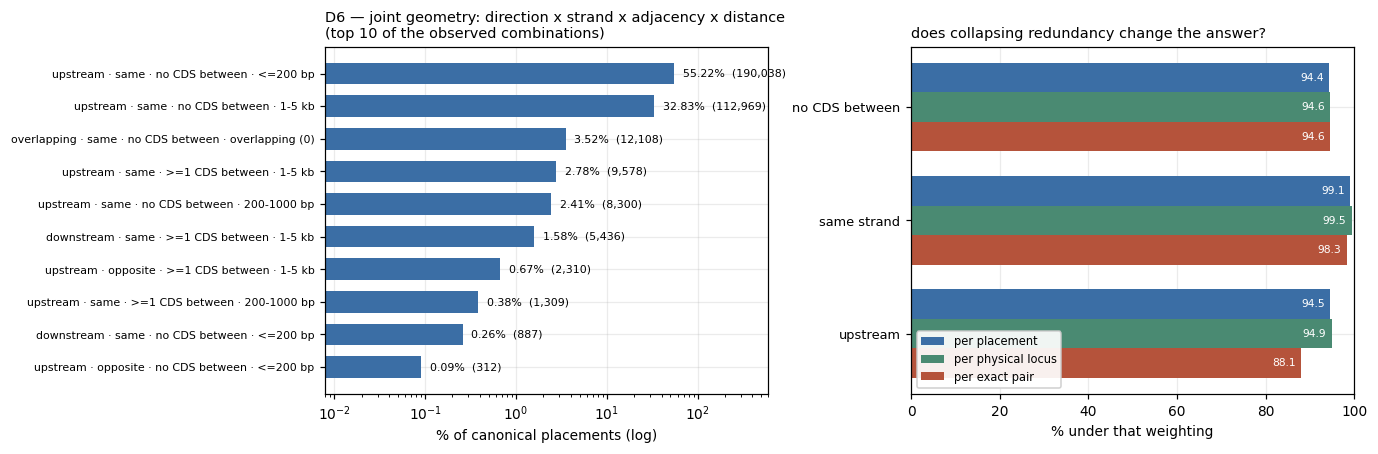

In [39]:
J = pd.read_csv(TABLES / "D6_joint_geometry.tsv", sep="\t").head(10).iloc[::-1]
M = pd.read_csv(TABLES / "D6_marginals_by_weighting.tsv", sep="\t")

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))

ax = axes[0]
labels = [f"{r.direction} · {r.strand} · {r.adjacency} · {r.distance_band}" for _, r in J.iterrows()]
y = np.arange(len(J))
ax.barh(y, J.pct_placements, color="#3b6ea5", height=0.66)
for i, (v, n) in enumerate(zip(J.pct_placements, J.n_placements)):
    ax.text(max(v, 0.012) * 1.25, i, f"{v:.2f}%  ({n:,})", va="center", fontsize=7.2)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7.2)
ax.set_xscale("log"); ax.set_xlim(0.008, 600)
ax.set_xlabel("% of canonical placements (log)")
ax.set_title("D6 — joint geometry: direction x strand x adjacency x distance\n"
             "(top 10 of the observed combinations)", fontsize=9.5, loc="left")

ax = axes[1]
y = np.arange(len(M)); h = 0.26
ax.barh(y + h, M.pct_placements,    height=h, color="#3b6ea5", label="per placement")
ax.barh(y,     M.pct_physical_loci, height=h, color="#4a8a72", label="per physical locus")
ax.barh(y - h, M.pct_exact_pairs,   height=h, color="#b5533b", label="per exact pair")
for i, r in enumerate(M.itertuples()):
    for off, v in [(h, r.pct_placements), (0, r.pct_physical_loci), (-h, r.pct_exact_pairs)]:
        ax.text(v - 1.2, i + off, f"{v:.1f}", va="center", ha="right", fontsize=7, color="white")
ax.set_yticks(y); ax.set_yticklabels(M.measure, fontsize=8.5)
ax.set_xlim(0, 100); ax.set_xlabel("% under that weighting")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.92)
ax.set_title("does collapsing redundancy change the answer?", fontsize=9.5, loc="left")

fig.tight_layout(); savefig(fig, "D6_joint_geometry"); plt.show()

**Interpretation.** The axes of D1–D3 are strongly coupled. One joint combination — **upstream,
same strand, no annotated CDS between, within 200 bp** — carries **55.2 % of canonical placements**,
and the composition tail falls away by orders of magnitude.

**Re-weighting is not neutral, and the way it moves is informative.** Collapsing placements to
distinct physical loci barely changes anything (upstream 94.51 % → 94.91 %, same strand 99.12 % →
99.45 %, no CDS between 94.41 % → 94.57 %): the arrangement is not an artefact of one genomic
position being deposited repeatedly. Collapsing to **distinct exact (RT, ncRNA) pairs** does move
it, and differently per band:

| joint combination | % of placements | % of exact pairs | direction of change |
|---|---|---|---|
| upstream · same · no CDS · **≤ 200 bp** | 55.22 % | **73.86 %** | **strengthens** |
| upstream · same · no CDS · **1–5 kb** | 32.83 % | **2.95 %** | **collapses** |
| overlapping · same · no CDS | 3.52 % | 10.32 % | strengthens |
| upstream · same · no CDS · 200–1000 bp | 2.41 % | 6.18 % | strengthens |

The 1–5 kb upstream band is a third of all placements but only **3 % of distinct pairs** — it is
carried by a small number of sequence pairs observed very many times, i.e. it is largely a
redundancy signal. The close-adjacency band behaves in the opposite way: it becomes *more*
dominant when each sequence pair is counted once.

Overall `upstream` falls from **94.51 % of placements to 88.10 % of exact pairs** — a 6.4-point
drop, meaning the non-upstream geometries are borne by proportionally more distinct sequence pairs
than the upstream ones. **The correct summary is therefore: close (≤ 200 bp), same-strand, 5′
adjacency with no intervening CDS is the dominant arrangement under every weighting, and it is the
only band that strengthens when redundancy is removed** — not that the marginals are
weighting-invariant.

**Caveats.** (i) The three weightings have different denominators (344,154 placements / 341,111
physical loci / 30,924 exact pairs) and are comparable as *compositions* only, never as counts.
(ii) A physical locus or exact pair observed under more than one geometry contributes to more than
one row, so columns need not sum to 100 %. (iii) Robustness across weightings excludes a redundancy
artefact; it does **not** establish cotranscription, cognate recognition, or any functional
relationship. These are coordinates, and they are compatible with — not evidence of — a shared
transcriptional unit.

---

# F. Exact RT–ncRNA pairing topology and independent recurrence

Two distinct questions, deliberately separated: **is an observed association unambiguous** (does
this RT sequence go with exactly one ncRNA sequence and vice versa), and **is its recurrence
independent** (does it recur across genomes and species, or only as repeated database copies of a
single physical locus)? The first bears on dataset selection; only the second bears on any
co-evolutionary reading.

## F0 — Which placement population the pair view is built on

The registered exact-pair view (`rt_ncrna_exact_pairs_v1`, **30,924** pairs) is derived from the
**ELIGIBLE** placement population (345,313), not the CANONICAL one (344,154). The difference is not
cosmetic, so it is measured rather than assumed.

In [40]:
basis = cache("F0_pair_view_basis", """
    SELECT 'ALL placements' AS placement_population,
           count(DISTINCT (rt_seq_hash, nc_seq_hash)) AS n_exact_pairs,
           count(DISTINCT rt_seq_hash) AS n_exact_rt, count(DISTINCT nc_seq_hash) AS n_exact_ncrna
    FROM rt_ncrna_pairs
    UNION ALL SELECT 'ELIGIBLE', count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash)
    FROM rt_ncrna_pairs WHERE geometry_eligible
    UNION ALL SELECT 'CANONICAL', count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash)
    FROM rt_ncrna_pairs WHERE canonical
    UNION ALL SELECT 'rt_ncrna_exact_pairs_v1 (the registered view)', count(*),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash) FROM rt_ncrna_exact_pairs
""")
display(basis)
check("registered pair view size",
      int(basis.loc[basis.placement_population.str.startswith("rt_ncrna_exact_pairs"), "n_exact_pairs"].iloc[0]),
      "pairs")

orphan = Q("""SELECT count(*) AS n FROM rt_ncrna_exact_pairs e
              WHERE NOT EXISTS (SELECT 1 FROM rt_ncrna_pairs p
                                WHERE p.canonical AND p.rt_seq_hash = e.rt_seq_hash
                                  AND p.nc_seq_hash = e.nc_seq_hash)""")
print(f"""
  registered pair view (ELIGIBLE-based) ....... 30,924
  pairs derivable from CANONICAL placements ... 30,427
  difference .................................. {int(orphan.n[0])} pairs

  Those {int(orphan.n[0])} pairs are represented ONLY by placements that are geometry-eligible but were
  removed by placement de-duplication (the ATYPICAL population, 1,159 placements). They are real
  sequence pairs; they simply have no surviving canonical placement.
""")

,placement_population,n_exact_pairs,n_exact_rt,n_exact_ncrna
0,ALL placements,31029,29297,16466
1,ELIGIBLE,30924,29192,16458
2,CANONICAL,30427,28976,16011
3,rt_ncrna_exact_pairs_v1 (the registered view),30924,29192,16458


  [MATCH] registered pair view size                      recomputed=30924            canonical=30924.0



  registered pair view (ELIGIBLE-based) ....... 30,924
  pairs derivable from CANONICAL placements ... 30,427
  difference .................................. 497 pairs

  Those 497 pairs are represented ONLY by placements that are geometry-eligible but were
  removed by placement de-duplication (the ATYPICAL population, 1,159 placements). They are real
  sequence pairs; they simply have no surviving canonical placement.



**Interpretation.** Section F uses the **registered 30,924-pair view** so that its numbers match the
landed g3 topology tables. Section D6, which compares geometry compositions, uses the
**canonical-derived 30,427 pairs**, because a geometry can only be attributed to a pair through a
placement that survived de-duplication. Both are correct for their purpose; **quoting one figure
while citing the other is not.** Any dataset row in section K states which basis it used.

## F1 — Partner-count distributions on both sides

* **Question.** How many partners does each side of the association have?
* **Unit.** Exact RT protein and exact ncRNA sequence, **within the exact-pair view**.
* **Denominator.** The side named in the measure, within the pair view — **29,192 exact RTs and
  16,458 exact ncRNAs**, not the 501,561 exact RTs of the corpus, since most carry no call at all.
* **Data.** `rt_ncrna_exact_pairs_v1` → `rt_seq_hash`, `nc_seq_hash`.

In [41]:
deg = cache("F1_partner_degrees", """
    WITH rt AS (SELECT rt_seq_hash, count(DISTINCT nc_seq_hash) AS k FROM rt_ncrna_exact_pairs GROUP BY 1),
         nc AS (SELECT nc_seq_hash, count(DISTINCT rt_seq_hash) AS k FROM rt_ncrna_exact_pairs GROUP BY 1)
    SELECT 'exact RT -> n ncRNA partners' AS side, least(k, 10) AS k_capped, count(*) AS n FROM rt GROUP BY 1,2
    UNION ALL
    SELECT 'exact ncRNA -> n RT partners', least(k, 10), count(*) FROM nc GROUP BY 1,2
    ORDER BY side, k_capped
""")
for side in deg.side.unique():
    deg.loc[deg.side == side, "pct_of_side"] = (
        100 * deg.loc[deg.side == side, "n"] / deg.loc[deg.side == side, "n"].sum()).round(3)
save(deg, "F1_partner_degrees")
display(deg)

summ = cache("F1_topology_summary", """
    WITH rt AS (SELECT rt_seq_hash, count(DISTINCT nc_seq_hash) AS k FROM rt_ncrna_exact_pairs GROUP BY 1),
         nc AS (SELECT nc_seq_hash, count(DISTINCT rt_seq_hash) AS k FROM rt_ncrna_exact_pairs GROUP BY 1)
    SELECT 'exact RTs in the pair view' AS measure, count(*) AS n, NULL::DOUBLE AS pct FROM rt
    UNION ALL SELECT 'exact RTs with exactly one ncRNA partner', count(*) FILTER (WHERE k = 1),
           100.0 * count(*) FILTER (WHERE k = 1) / count(*) FROM rt
    UNION ALL SELECT 'exact RTs with more than one', count(*) FILTER (WHERE k > 1),
           100.0 * count(*) FILTER (WHERE k > 1) / count(*) FROM rt
    UNION ALL SELECT 'max ncRNA partners on one exact RT', max(k), NULL FROM rt
    UNION ALL SELECT 'exact ncRNAs in the pair view', count(*), NULL FROM nc
    UNION ALL SELECT 'exact ncRNAs with exactly one RT partner', count(*) FILTER (WHERE k = 1),
           100.0 * count(*) FILTER (WHERE k = 1) / count(*) FROM nc
    UNION ALL SELECT 'exact ncRNAs with more than one', count(*) FILTER (WHERE k > 1),
           100.0 * count(*) FILTER (WHERE k > 1) / count(*) FROM nc
    UNION ALL SELECT 'max RT partners on one exact ncRNA', max(k), NULL FROM nc
""")
display(summ.round(3))

print("\nagainst g3_topology_degrees:")
g3t = gate_table("dbchar_g3_pair_geometry", "g3_topology_degrees").set_index("measure")["n"]
for lab, key in [("exact RTs in the pair view", "exact_RTs_in_the_pair_view"),
                 ("exact RTs with exactly one ncRNA partner", "exact_RTs_paired_with_exactly_one_ncRNA_sequence"),
                 ("exact ncRNAs in the pair view", "exact_ncRNA_sequences_in_the_pair_view"),
                 ("exact ncRNAs with exactly one RT partner", "exact_ncRNA_sequences_paired_with_exactly_one_RT"),
                 ("max RT partners on one exact ncRNA", "max_exact_RTs_on_one_ncRNA_sequence")]:
    check(lab, int(summ.loc[summ.measure == lab, "n"].iloc[0]), expected=float(g3t[key]))

,side,k_capped,n,pct_of_side
0,exact RT -> n ncRNA partners,1,28271,96.845
1,exact RT -> n ncRNA partners,2,724,2.480
2,exact RT -> n ncRNA partners,3,115,0.394
3,exact RT -> n ncRNA partners,4,36,0.123
4,exact RT -> n ncRNA partners,5,12,0.041
5,exact RT -> n ncRNA partners,6,8,0.027
6,exact RT -> n ncRNA partners,7,4,0.014
7,exact RT -> n ncRNA partners,8,4,0.014
8,exact RT -> n ncRNA partners,9,5,0.017
9,exact RT -> n ncRNA partners,10,13,0.045


,measure,n,pct
0,exact RTs in the pair view,29192,NaN
1,exact RTs with exactly one ncRNA partner,28271,96.845
2,exact RTs with more than one,921,3.155
3,max ncRNA partners on one exact RT,176,NaN
4,exact ncRNAs in the pair view,16458,NaN
5,exact ncRNAs with exactly one RT partner,13542,82.282
6,exact ncRNAs with more than one,2916,17.718
7,max RT partners on one exact ncRNA,705,NaN



against g3_topology_degrees:
  [MATCH] exact RTs in the pair view                     recomputed=29192            canonical=29192.0
  [MATCH] exact RTs with exactly one ncRNA partner       recomputed=28271            canonical=28271.0
  [MATCH] exact ncRNAs in the pair view                  recomputed=16458            canonical=16458.0
  [MATCH] exact ncRNAs with exactly one RT partner       recomputed=13542            canonical=13542.0
  [MATCH] max RT partners on one exact ncRNA             recomputed=705              canonical=705.0


## F2 — Component shapes: which associations are unambiguous

* **Question.** Treating exact RTs and exact ncRNAs as a bipartite graph, how many associations are
  cleanly one-to-one, and how much of the data sits in large entangled components?
* **Unit.** Connected component of the exact RT–ncRNA bipartite graph.
* **Denominator.** All 14,918 components.
* **Data.** `rt_ncrna_exact_pairs_v1`; cross-checked against `g3_topology_components.tsv`.

In [42]:
comp = gate_table("dbchar_g3_pair_geometry", "g3_topology_components")
comp["pct_of_components"] = (100 * comp.n_components / comp.n_components.sum()).round(3)
comp["pct_of_exact_rt_in_view"] = (100 * comp.n_exact_rt / comp.n_exact_rt.sum()).round(3)
save(comp, "F2_component_shapes")
display(comp[["shape", "n_components", "pct_of_components", "n_exact_rt",
              "pct_of_exact_rt_in_view", "n_exact_ncrna",
              "max_rt_in_a_component", "max_ncrna_in_a_component"]])

check("1:1 components", int(comp.loc[comp.shape_ if False else comp["shape"] == "1:1", "n_components"].iloc[0]),
      "pairs_1to1")
one2one = int(comp.loc[comp["shape"] == "1:1", "n_components"].iloc[0])
print(f"\n{one2one:,} strictly 1:1 components: {100*one2one/comp.n_components.sum():.2f}% of components, "
      f"but only {100*one2one/comp.n_exact_rt.sum():.2f}% of the exact RTs in the pair view.")
print("The many:1 and many:many components hold few components but most of the RT sequences —\n"
      "ambiguity is concentrated, not spread.")

,shape,n_components,pct_of_components,n_exact_rt,pct_of_exact_rt_in_view,n_exact_ncrna,max_rt_in_a_component,max_ncrna_in_a_component
0,1:1,12079,80.969,12079,41.378,12079,1,1
1,1:many,179,1.200,179,0.613,390,1,9
2,many:1,2293,15.371,8092,27.720,2293,214,1
3,many:many,367,2.460,8842,30.289,1696,706,190


  [MATCH] 1:1 components                                 recomputed=12079            canonical=12079.0

12,079 strictly 1:1 components: 80.97% of components, but only 41.38% of the exact RTs in the pair view.
The many:1 and many:many components hold few components but most of the RT sequences —
ambiguity is concentrated, not spread.


## F3 — Recurrence: independent observation versus repeated database copies

* **Question.** When a pair recurs, what kind of repetition is it?
* **Unit.** Exact (RT, ncRNA) pair.
* **Denominator.** All 30,924 exact pairs.
* **Data.** `rt_ncrna_exact_pair_recurrence_v1` → `recurrence_class`, `n_placements`, `n_loci`,
  `n_physical_loci`, `n_genomes`, `n_species`, `n_databases`.

In [43]:
rec = cache("F3_recurrence_classes", """
    SELECT recurrence_class, count(*) AS n_pairs,
           median(n_placements) AS median_placements, median(n_physical_loci) AS median_physical_loci,
           median(n_genomes) AS median_genomes, median(n_species) AS median_species
    FROM rt_ncrna_exact_pair_recurrence GROUP BY 1 ORDER BY n_pairs DESC
""")
rec["pct_of_pairs"] = (100 * rec.n_pairs / rec.n_pairs.sum()).round(3)
save(rec, "F3_recurrence_classes")
display(rec)

INDEPENDENT = ["multiple_species", "one_species_multiple_genomes", "one_genome_multiple_loci"]
ind = rec[rec.recurrence_class.isin(INDEPENDENT)].n_pairs.sum()
dbcopy = rec[rec.recurrence_class.str.contains("physical_locus")].n_pairs.sum()
once = rec[rec.recurrence_class == "single_placement"].n_pairs.sum()
tot = rec.n_pairs.sum()
print(f"""
  observed once .................................. {once:>6,}  ({100*once/tot:5.2f}%)
  recurs only as copies of ONE physical locus .... {dbcopy:>6,}  ({100*dbcopy/tot:5.2f}%)  <- database redundancy
  recurs across genomes or species ............... {ind:>6,}  ({100*ind/tot:5.2f}%)  <- independent observation
  ---------------------------------------------------------
  total exact pairs .............................. {tot:>6,}
""")

# cross-tabulate independence against how unambiguous the association is
cross = cache("F3_recurrence_x_ambiguity", """
    WITH deg AS (
      SELECT rt_seq_hash, nc_seq_hash,
             count(*) OVER (PARTITION BY rt_seq_hash) AS rt_partners,
             count(*) OVER (PARTITION BY nc_seq_hash) AS nc_partners
      FROM rt_ncrna_exact_pairs)
    SELECT r.recurrence_class,
           CASE WHEN d.rt_partners = 1 AND d.nc_partners = 1 THEN 'unambiguous (1:1)'
                ELSE 'ambiguous (>1 partner on a side)' END AS ambiguity,
           count(*) AS n_pairs
    FROM rt_ncrna_exact_pair_recurrence r
    JOIN deg d USING (rt_seq_hash, nc_seq_hash)
    GROUP BY 1, 2 ORDER BY n_pairs DESC
""")
piv = cross.pivot_table(index="recurrence_class", columns="ambiguity", values="n_pairs", fill_value=0)
piv["total"] = piv.sum(axis=1)
display(piv.sort_values("total", ascending=False))

,recurrence_class,n_pairs,median_placements,median_physical_loci,median_genomes,median_species,pct_of_pairs
0,single_placement,12005,1.0,1.0,1.0,1.0,38.821
1,one_physical_locus_multiple_database_copies,9362,2.0,1.0,2.0,2.0,30.274
2,multiple_species,5056,4.0,3.0,4.0,2.0,16.350
3,one_species_multiple_genomes,4452,4.0,3.0,3.0,1.0,14.397
4,one_genome_multiple_loci,36,2.0,2.0,1.0,1.0,0.116
5,one_physical_locus_multiple_records,13,2.0,1.0,1.0,1.0,0.042



  observed once .................................. 12,005  (38.82%)
  recurs only as copies of ONE physical locus ....  9,375  (30.32%)  <- database redundancy
  recurs across genomes or species ...............  9,544  (30.86%)  <- independent observation
  ---------------------------------------------------------
  total exact pairs .............................. 30,924



ambiguity,ambiguous (>1 partner on a side),unambiguous (1:1),total
recurrence_class,,,
single_placement,7561.0,4444.0,12005.0
one_physical_locus_multiple_database_copies,4473.0,4889.0,9362.0
multiple_species,3132.0,1924.0,5056.0
one_species_multiple_genomes,3647.0,805.0,4452.0
one_genome_multiple_loci,26.0,10.0,36.0
one_physical_locus_multiple_records,6.0,7.0,13.0


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


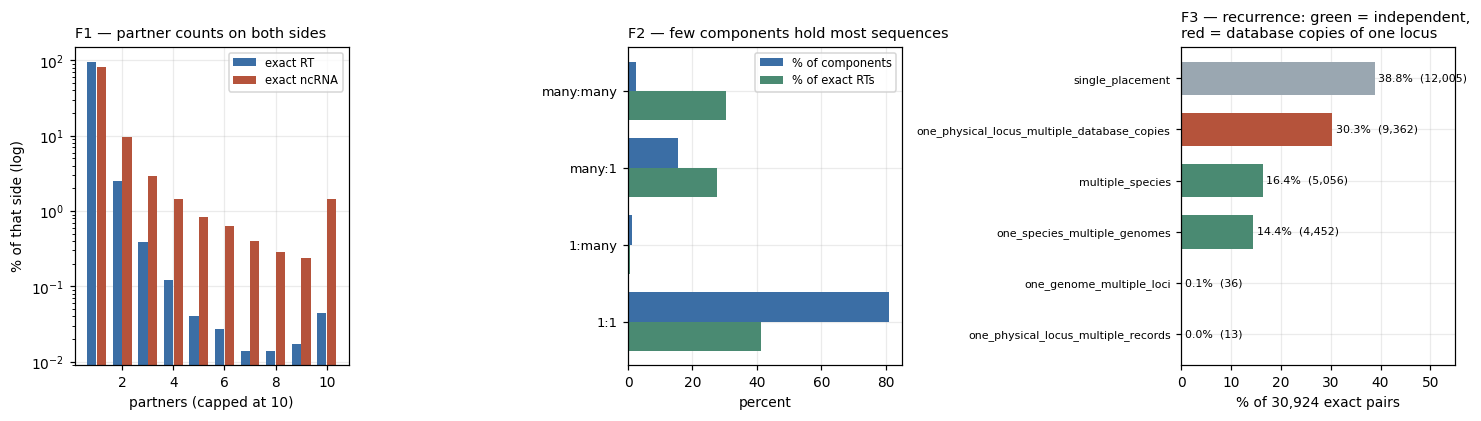

In [44]:
R = pd.read_csv(TABLES / "F3_recurrence_classes.tsv", sep="\t").sort_values("n_pairs")
Dg = pd.read_csv(TABLES / "F1_partner_degrees.tsv", sep="\t")
Cp = pd.read_csv(TABLES / "F2_component_shapes.tsv", sep="\t")

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.9))

ax = axes[0]
for side, color, off in [("exact RT -> n ncRNA partners", "#3b6ea5", -0.19),
                         ("exact ncRNA -> n RT partners", "#b5533b", 0.19)]:
    d = Dg[Dg.side == side]
    ax.bar(d.k_capped + off, d.pct_of_side, width=0.36, color=color, label=side.split(" -> ")[0])
ax.set_yscale("log"); ax.set_xlabel("partners (capped at 10)")
ax.set_ylabel("% of that side (log)"); ax.legend(fontsize=7.5)
ax.set_title("F1 — partner counts on both sides", fontsize=9.5, loc="left")

ax = axes[1]
y = np.arange(len(Cp)); h = 0.38
ax.barh(y + h/2, Cp.pct_of_components, height=h, color="#3b6ea5", label="% of components")
ax.barh(y - h/2, Cp.pct_of_exact_rt_in_view, height=h, color="#4a8a72", label="% of exact RTs")
ax.set_yticks(y); ax.set_yticklabels(Cp["shape"], fontsize=8.5)
ax.set_xlabel("percent"); ax.legend(fontsize=7.5)
ax.set_title("F2 — few components hold most sequences", fontsize=9.5, loc="left")

ax = axes[2]
colors = ["#b5533b" if "physical_locus" in c else
          ("#9aa7b1" if c == "single_placement" else "#4a8a72") for c in R.recurrence_class]
ax.barh(R.recurrence_class, R.pct_of_pairs, color=colors, height=0.66)
for i, (v, n) in enumerate(zip(R.pct_of_pairs, R.n_pairs)):
    ax.text(v + 0.7, i, f"{v:.1f}%  ({n:,})", va="center", fontsize=7.2)
ax.set_xlim(0, 55); ax.set_xlabel("% of 30,924 exact pairs")
ax.tick_params(axis="y", labelsize=7.2)
ax.set_title("F3 — recurrence: green = independent,\nred = database copies of one locus",
             fontsize=9.5, loc="left")

fig.tight_layout(); savefig(fig, "F_pairing_topology"); plt.show()

**Interpretation.** The association is predominantly unambiguous *as observed*: **96.85 % of exact
RTs in the pair view have exactly one ncRNA partner** and **82.28 % of exact ncRNAs have exactly one
RT partner**. But ambiguity is concentrated rather than spread — the 1:1 components are 80.97 % of
components while holding only 41.38 % of the exact RTs in the view, and a single component reaches
706 RTs and 190 ncRNAs.

The recurrence split is the result that matters for any evolutionary reading. Of 30,924 exact
pairs, **38.82 % are seen once**, **30.32 % recur only as multiple database copies of a single
physical locus**, and only **30.86 % recur across distinct genomes or species**. Roughly **a third
of the apparent recurrence in this resource is database redundancy, not independent observation** —
and the cross-tabulation shows it is not evenly distributed across the ambiguity classes.

**Caveats.** (i) "Unambiguous" here means *unambiguous in this corpus under exact-sequence
identity*: a single amino-acid difference creates a new `rt_seq_hash` and therefore a new node, so
these degrees are an upper bound on distinctness and a lower bound on partner sharing. (ii) A 1:1
observed association **does not demonstrate orthogonality or cognate specificity** — it is a
selection criterion for a downstream dataset, not evidence of exclusive biological pairing.
(iii) Pair membership is inherited from placement geometry, which is detector-defined (§C, §E), so
the pair view inherits every scope limit of the covariance-model library.

---

# E. Detection / tool relationships  *(scaffold — not yet implemented)*

* **Question.** How do myRT, PADLOC and DefenseFinder partition the corpus, and how much of the
  apparent biology of a tool-defined subset is a detector-definition effect?
* **Unit.** Distinct record (`V-REC-DISTINCT`, `record_key`). `rt_tool_calls_v1` **is** that
  population — 3,051,238 rows, i.e. `is_first_copy`.
* **Denominator.** Retron records for the headline tool percentages (to match g6); state clearly
  whenever the denominator is all RT records instead.
* **Data.** `rt_tool_calls_v1` → `by_myRT`, `by_PADLOC`, `by_DefenseFinder`, `detected_by_set`,
  `n_tools`, `n_ncrna`, `file_label`, `subtypes_padloc`, `subtypes_defensefinder`.

Planned:
1. 3-set Venn over the seven `detected_by_set` classes (`matplotlib_venn.venn3`).
2. ncRNA carriage per tool intersection — the 89.23 % (myRT+PADLOC) vs 13.50 % (myRT alone) contrast.
3. Subtype agreement where both tools wrote one (365,708 records; 160,381 agree).
4. An explicit **detector-definition vs biology** panel.

**Hard caveat to carry into every cell here:** the three tools share model lineage, so agreement is
not independent corroboration; and *"tool absent from a record"* cannot be distinguished from
*"tool never run on that genome"*. A tool-defined subset of this corpus is **not** a random subset.

# G. The MULTI population  *(scaffold — not yet implemented)*

* **Question.** What is the basis of the multiple family labels — mislabelling, or genuine
  profile ambiguity?
* **Unit.** Exact RT protein in `V-RT-MULTI` (7,593); the record-level stratum is 9,012.
* **Denominator.** MULTI exact RTs. **MULTI is never appended to a single family** (Rule 2).
* **Data.** `multi_hmm_evidence_v1` → `labels`, `best_family`, `best_score`, `second_family`,
  `second_score`, `margin_bits`, `best_in_labels`, `rt_aa_len`; `rt_family_baseline_v1`.

Planned: margin distribution vs the seeded single-family control (5 bits vs 81.7 bits);
label-set combinations; length and completeness of MULTI vs `V-RT-SINGLE`; margin-vs-length to
test the length confound.

**Caveat.** Stage 1 does **not** resolve MULTI, and neither should this section. MULTI proteins are
shorter than single-family ones and HMM score scales with length, so part of the small margin may
be a length effect rather than biological ambiguity. Treat it as an ambiguity population.

# H. Taxonomic representation  *(scaffold — not yet implemented)*

* **Question.** How is the corpus distributed over taxa, and what changes when redundancy is
  corrected?
* **Unit.** Report **both** distinct record (`V-REC-DISTINCT`) and exact RT (`V-RT`) /
  RT taxonomic occurrence (`V-RT-TAXOCC`); the difference *is* the result.
* **Denominator.** Per taxonomy system, never pooled: `ncbi` 2,267,726 records ·
  `gtdb` 769,698 · `unknown` 22,276.
* **Data.** `rt_records_v1` → `taxonomy_system`, `tax_domain`, `tax_phylum`, `tax_class`,
  `tax_species`, `genome_id_norm`, `rt_seq_hash`, `is_first_copy`.

Planned: representation by domain/phylum/class per schema; the record→exact-RT shift
(*E. coli* 19.97 % → 6.09 %; top-10 species 66.21 % → 18.95 %); an explicit
raw-representation vs normalised-enrichment pair.

**Caveats.** (i) NCBI rows carry **no phylum by construction** — 0.00 % coverage is a schema fact,
not missing data; report GTDB and NCBI separately and never pool ranks. (ii) Record counts measure
sequencing effort. Any enrichment claim needs a stated normalisation and a denominator of genomes
*surveyed*, which this corpus — harvested by RT presence — does not contain. Prefer
"representation" over "enrichment" unless that denominator is supplied.

# I. QC and exceptional populations  *(scaffold — not yet implemented)*

* **Question.** What does the corpus look like at its edges, and what does each eligibility rule
  cost its denominator?
* **Unit.** Varies per sub-analysis — declared per cell.
* **Denominator.** Declared per cell; every eligibility filter reports (n eligible, n ineligible,
  by reason).
* **Data.** `rt_cds_recovery_v1` (31,504), `rt_ncrna_pairs_v1` (`geometry_ineligible_reason`,
  `multiplicity_class`), `rt_records_v1` (`window_inverted`, `true_start_clipped`,
  `clipped_end_flag`, `rt_at_window_edge`, `bt_status`),
  `rt_ncrna_nonretron_candidates_v1` (266), `g3_atypical_catalogue.tsv`.

Planned:
1. RT-CDS recovery classes — `RECOVERED` 14,188 / `SEQUENCE_ONLY` 16,688 / `ILL_POSED` 628, and
   `representation_class` (9,128 wholly beyond the retrieved contig).
2. Geometry-ineligible placements by reason (2,568 non-canonical: 1,303 byte-identical duplicate
   lines, 41 + 37 + 28 QC).
3. Atypical / inverted windows (3,924 inverted-no-sequence) and the atypical catalogue.
4. The **266** retron-CM / non-Retron-RT candidates (260 single-family + 6 MULTI).
5. Back-translation status: 2,532,006 exact vs 618 mismatch.

**Caveat.** Atypical biology is **flagged before it is filtered** (project convention). Nothing in
this section is a cleanup step; it is the measurement of what each rule removes. And "verified"
only means two fields of one record agree.

# J. Open exploratory analyses

Space for analyses added on request. Each new block follows the same shape:

1. Markdown declaration — **question · unit · denominator · datasets/columns**.
2. Computation cell using `Q(...)` / `cache("<Jn_name>", "<sql>")`.
3. Compact table.
4. One plot, drawn from the cached table.
5. Markdown interpretation **and caveat**.

Before adding one, check whether the value already exists in `g7_resolved_values.tsv` — if it does,
load it rather than creating a second definition.

In [45]:
# Scratch cell — free exploration. Anything worth keeping becomes a J-section block above.
# Q("SELECT ... FROM rt_records WHERE ... LIMIT 20")

---

## Session inventory

Run this last to list what this session produced.

In [46]:
rows = []
for d, kind in [(TABLES, "table"), (FIGURES, "figure"), (EXPORTS, "export")]:
    for p in sorted(d.iterdir()):
        if p.is_file():
            rows.append({"kind": kind, "name": p.name, "kB": round(p.stat().st_size / 1024, 1)})
inv = pd.DataFrame(rows)
print(f"{len(inv)} artefacts under {WB}")
display(inv)

73 artefacts under /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7-dbchar-workbench/ARIS_OUTPUT/dbchar_workbench


,kind,name,kB
0,table,A0_pop_rt_units.tsv,0.2
1,table,A0_population_cascade.tsv,0.3
2,table,A0_recovery_vs_eligibility.tsv,0.3
3,table,A1_unit_ladder.tsv,0.2
4,table,A2_redundancy_by_database.tsv,0.6
...,...,...,...
68,figure,FIGURE_PROVENANCE.tsv,1.6
69,figure,F_pairing_topology.png,97.1
70,figure,L_dataset_rule_and_multiplicity.png,93.9
71,export,RESULTS_database_characterization_DRAFT.md,34.1


---

# K. Dataset inventory

One row per named dataset this characterization can hand downstream, each with its inclusion rule,
its counts under that exact rule, and — as important — what it may **not** be used to claim.

Rows marked **PROVISIONAL** cannot be populated yet because their selection rule is an operator
decision that has not been made (§K2). They are listed with their open parameters rather than
filled with a default, because a threshold invented here would silently become the project's
definition of a confident RT–ncRNA association.

## K1 — Populated rows

* **Question.** Under each precise inclusion rule, how large is the resulting dataset in every unit
  a downstream task might need?
* **Unit.** Varies per row; every row reports records, loci, physical loci, exact RTs, exact ncRNAs
  and exact pairs where the concept applies.
* **Denominator.** Each row is its own population; the `overlap` column states its relation to the
  others rather than implying they partition anything.
* **Data.** All canonical tables.

In [47]:
def counts(where_records=None, where_pairs=None):
    """Count one dataset in every unit that applies to it."""
    out = {}
    if where_records:
        r = Q(f"""SELECT count(*) AS n_records, count(DISTINCT locus_key) AS n_loci,
                         count(DISTINCT physical_locus_key) AS n_physical_loci,
                         count(DISTINCT rt_seq_hash) AS n_exact_rt,
                         count(DISTINCT genome_id_norm) AS n_genomes
                  FROM rt_records WHERE {where_records}""").iloc[0].to_dict()
        out.update(r)
    if where_pairs:
        p = Q(f"""SELECT count(*) AS n_placements,
                         count(DISTINCT physical_locus_key) AS n_physical_loci,
                         count(DISTINCT rt_seq_hash) AS n_exact_rt,
                         count(DISTINCT nc_seq_hash) AS n_exact_ncrna,
                         count(DISTINCT (rt_seq_hash, nc_seq_hash)) AS n_exact_pairs
                  FROM rt_ncrna_pairs WHERE {where_pairs}""").iloc[0].to_dict()
        out.update(p)
    return out

ROWS = [
    dict(dataset="D1 full RT corpus", purpose="provenance, corpus description",
         unit="raw record", rule="every RT-anchored record as mined",
         rec="TRUE", pair=None),
    dict(dataset="D2 distinct-record corpus", purpose="anything record-level",
         unit="distinct record", rule="is_first_copy",
         rec="is_first_copy", pair=None),
    dict(dataset="D3 sequence resource (POP_RT_SEQ)",
         purpose="family composition, length, completeness, diversity, clustering",
         unit="exact RT protein", rule="distinct, single-family, well-formed protein",
         rec=POP_RT_SEQ, pair=None),
    dict(dataset="D4 context resource (POP_RT_CTX)",
         purpose="geometry, locus architecture, genomic context",
         unit="record / locus", rule="POP_RT_SEQ + elig_geometry",
         rec=POP_RT_CTX, pair=None),
    dict(dataset="D5 MULTI stratum", purpose="family-ambiguity analysis only",
         unit="exact RT protein", rule="file_label = MULTI or multilabel",
         rec="is_first_copy AND (file_label = 'MULTI' OR multilabel)", pair=None),
    dict(dataset="D6 technically unresolved", purpose="QC, method development",
         unit="record", rule="distinct, single-family, NOT elig_geometry",
         rec="is_first_copy AND file_label <> 'MULTI' AND NOT multilabel AND NOT elig_geometry",
         pair=None),
    dict(dataset="D7 observed placements (canonical)",
         purpose="RT-ncRNA geometry as observed",
         unit="placement",
         rule="geometry-eligible and de-duplicated; pair counts here are canonical-derived (30,427)",
         rec=None, pair="canonical"),
    dict(dataset="D8 observed placements, Retron only",
         purpose="retron-specific geometric conclusions",
         unit="placement", rule="canonical AND file_label = Retron",
         rec=None, pair="canonical AND file_label = 'Retron'"),
    dict(dataset="D9 exact-pair resource (registered view)",
         purpose="pair-level association, co-evolution input",
         unit="exact (RT, ncRNA) pair",
         rule="rt_ncrna_exact_pairs_v1 — built on ELIGIBLE placements, not canonical (see F0)",
         rec=None, pair=None, registered_pairs=True),
    dict(dataset="D10 atypical placements",
         purpose="exception review; never a background set",
         unit="placement",
         rule="canonical AND (opposite strand OR >2 CDS between OR |distance| > 5 kb)",
         rec=None,
         pair="canonical AND (NOT same_strand OR n_cds_between > 2 OR abs(signed_distance_bp) > 5000)"),
    dict(dataset="D11 retron-CM / non-Retron-RT candidates",
         purpose="candidate cross-family associations",
         unit="placement", rule="eligible, retron CM, non-Retron single-family RT",
         rec=None,
         pair="geometry_eligible AND file_label NOT IN ('Retron','MULTI')"),
]

rows = []
for r in ROWS:
    if r.get("registered_pairs"):
        c = Q("""SELECT count(*) AS n_exact_pairs, count(DISTINCT rt_seq_hash) AS n_exact_rt,
                        count(DISTINCT nc_seq_hash) AS n_exact_ncrna
                 FROM rt_ncrna_exact_pairs""").iloc[0].to_dict()
    else:
        c = counts(r["rec"], r["pair"])
    rows.append({**{k: r[k] for k in ("dataset", "purpose", "unit", "rule")}, **c})
inv = pd.DataFrame(rows)
for col in ["n_records", "n_loci", "n_physical_loci", "n_exact_rt", "n_genomes",
            "n_placements", "n_exact_ncrna", "n_exact_pairs"]:
    if col in inv: inv[col] = inv[col].astype("Int64")
save(inv, "K1_dataset_inventory")
display(inv[["dataset", "unit", "n_records", "n_loci", "n_physical_loci", "n_exact_rt",
             "n_placements", "n_exact_ncrna", "n_exact_pairs"]])

,dataset,unit,n_records,n_loci,n_physical_loci,n_exact_rt,n_placements,n_exact_ncrna,n_exact_pairs
0,D1 full RT corpus,raw record,3059700,2847312,2475684,501561,<NA>,<NA>,<NA>
1,D2 distinct-record corpus,distinct record,3051238,2847312,2475684,501561,<NA>,<NA>,<NA>
2,D3 sequence resource (POP_RT_SEQ),exact RT protein,3042216,2838761,2467291,493964,<NA>,<NA>,<NA>
3,D4 context resource (POP_RT_CTX),record / locus,3026000,2822547,2451078,477956,<NA>,<NA>,<NA>
4,D5 MULTI stratum,exact RT protein,9022,8551,8393,7598,<NA>,<NA>,<NA>
5,D6 technically unresolved,record,16216,16214,16213,16014,<NA>,<NA>,<NA>
6,D7 observed placements (canonical),placement,<NA>,<NA>,297793,28976,344154,16011,30427
7,"D8 observed placements, Retron only",placement,<NA>,<NA>,297608,28838,343892,15906,30287
8,D9 exact-pair resource (registered view),"exact (RT, ncRNA) pair",<NA>,<NA>,<NA>,29192,<NA>,16458,30924
9,D10 atypical placements,placement,<NA>,<NA>,7296,746,8852,431,846


In [48]:
K = pd.read_csv(TABLES / "K1_dataset_inventory.tsv", sep="\t")

USES = {
 "D1 full RT corpus": ("corpus provenance; per-file composition",
                       "ANY biological rate — it double-counts loci mined more than once"),
 "D2 distinct-record corpus": ("record-level QC, tool-call analysis",
                       "diversity statements — one protein appears at many records"),
 "D3 sequence resource (POP_RT_SEQ)": ("family composition, length, completeness, clustering",
                       "anything needing genomic context — 16,008 of these proteins have none"),
 "D4 context resource (POP_RT_CTX)": ("geometry, neighbourhood, locus architecture",
                       "protein diversity — it discards usable proteins with broken context"),
 "D5 MULTI stratum": ("family-ambiguity analysis",
                       "any single-family statistic; do not merge into a family"),
 "D6 technically unresolved": ("QC and extraction-method development",
                       "biology of any kind"),
 "D7 observed placements (canonical)": ("observed geometry, distance, strand, adjacency",
                       "cotranscription, cognate recognition, or 'validated pairs'"),
 "D8 observed placements, Retron only": ("retron-specific geometric conclusions",
                       "cross-family generalisation"),
 "D9 exact-pair resource (registered view)": ("pair-level association; recurrence-class-filtered co-evolution input",
                       "orthogonality — 1:1 as observed is not exclusive pairing"),
 "D10 atypical placements": ("exception review, hypothesis generation",
                       "a background or null distribution"),
 "D11 retron-CM / non-Retron-RT candidates": ("candidate list for annotation follow-up",
                       "novel retrons — CM cross-matching is not excluded"),
}
K["suitable_for"] = K.dataset.map(lambda d: USES[d][0])
K["NOT_usable_for"] = K.dataset.map(lambda d: USES[d][1])
K["retained_uncertainty"] = K.dataset.map({
 "D1 full RT corpus": "duplicate lines; ncRNA-anchored records excluded by rule",
 "D2 distinct-record corpus": "cross-database locus overlap (200,914 loci)",
 "D3 sequence resource (POP_RT_SEQ)": "partiality (~25% all_partial); family label is HMM-assigned",
 "D4 context resource (POP_RT_CTX)": "~41% contig-clipped windows retained and stratified, not excluded",
 "D5 MULTI stratum": "unresolved; margin result confounded with protein length",
 "D6 technically unresolved": "628 ill-posed; 16,688 sequence-only",
 "D7 observed placements (canonical)": "detector scope (retron CMs only); technical downstream mode",
 "D8 observed placements, Retron only": "zero-ncRNA rate 47.23% is not measured absence",
 "D9 exact-pair resource (registered view)": "30.3% of recurrence is database copies of one physical locus; ELIGIBLE-based, 497 pairs have no canonical placement",
 "D10 atypical placements": "mixed causes: artefact, annotation gap, and possible biology",
 "D11 retron-CM / non-Retron-RT candidates": "partner ambiguity and CM-hit quality not yet assessed",
})
save(K, "K1_dataset_inventory")
pd.set_option("display.max_colwidth", 58)
display(K[["dataset", "suitable_for", "NOT_usable_for", "retained_uncertainty"]])
pd.set_option("display.max_colwidth", 50)
print(f"\nwritten: {TABLES / 'K1_dataset_inventory.tsv'}")

,dataset,suitable_for,NOT_usable_for,retained_uncertainty
0,D1 full RT corpus,corpus provenance; per-file composition,ANY biological rate — it double-counts loci mined more...,duplicate lines; ncRNA-anchored records excluded by rule
1,D2 distinct-record corpus,"record-level QC, tool-call analysis",diversity statements — one protein appears at many rec...,"cross-database locus overlap (200,914 loci)"
2,D3 sequence resource (POP_RT_SEQ),"family composition, length, completeness, clustering","anything needing genomic context — 16,008 of these pro...",partiality (~25% all_partial); family label is HMM-ass...
3,D4 context resource (POP_RT_CTX),"geometry, neighbourhood, locus architecture",protein diversity — it discards usable proteins with b...,"~41% contig-clipped windows retained and stratified, n..."
4,D5 MULTI stratum,family-ambiguity analysis,any single-family statistic; do not merge into a family,unresolved; margin result confounded with protein length
5,D6 technically unresolved,QC and extraction-method development,biology of any kind,"628 ill-posed; 16,688 sequence-only"
6,D7 observed placements (canonical),"observed geometry, distance, strand, adjacency","cotranscription, cognate recognition, or 'validated pa...",detector scope (retron CMs only); technical downstream...
7,"D8 observed placements, Retron only",retron-specific geometric conclusions,cross-family generalisation,zero-ncRNA rate 47.23% is not measured absence
8,D9 exact-pair resource (registered view),pair-level association; recurrence-class-filtered co-e...,orthogonality — 1:1 as observed is not exclusive pairing,30.3% of recurrence is database copies of one physical...
9,D10 atypical placements,"exception review, hypothesis generation",a background or null distribution,"mixed causes: artefact, annotation gap, and possible b..."



written: /home/borg/RESEARCH-in-sleep-FINAL_RETRON_PROJECT_v7-dbchar-workbench/ARIS_OUTPUT/dbchar_workbench/tables/K1_dataset_inventory.tsv


## K2 — PROVISIONAL rows: what is still undecided

Three datasets named in the review cannot be populated from the current evidence, because each
needs a selection rule that is an **operator decision**, not a computation. They are specified here
with their open parameters so the decision can be made explicitly.

### K2.1 — "Confident RT–ncRNA associations"

The term *canonical placement* means **technically eligible and de-duplicated under the existing
geometry rules**. It must not be renamed "biologically validated pair". A confidence rule needs
values for, at minimum:

| parameter | candidate basis in the data | currently undecided |
|---|---|---|
| maximum RT–ncRNA distance | the ≤ 200 bp band holds 73.9 % of exact pairs (D6) | is the cut 200 bp, 500 bp, or distribution-derived? |
| strand requirement | 99.12 % same-strand; opposite-strand is a single-CM population (D5) | require same strand, or retain opposite as flagged? |
| intervening CDS | 94.41 % have none | require 0, or allow 1? |
| direction | upstream 94.5 %; overlapping 3.5 % | are overlapping placements included? |
| CM hit quality | `score` / `evalue` exist per call and are **not yet used anywhere** | no threshold set; per-model or global? |
| partner ambiguity | 96.85 % of RTs have one partner (F1) | require 1:1, or allow ambiguous with a flag? |
| recurrence independence | only 30.86 % recur across genomes/species (F3) | require independent recurrence, or allow singletons? |
| context completeness | `POP_RT_CTX` only, or also clipped windows? | |

**Until these are set, the confident-association dataset does not exist and should not be quoted.**
The counts under any candidate rule are one query away once the rule is chosen.

### K2.2 — Modeling dataset
Needs K2.1 plus a train/test split rule that does not leak: exact pairs recurring only as database
copies of one physical locus (30.32 %) must not be split across folds, or performance will be
inflated by memorisation.

### K2.3 — Experimental-prioritization dataset
Needs K2.1 plus task-specific criteria (host tractability, subtype coverage, sequence novelty
against known retrons) that this characterization does not measure.

In [49]:
# The confidence rule is not set, so no dataset is produced. What CAN be shown is how many exact
# pairs survive each candidate criterion INDEPENDENTLY — the input to choosing the rule.
sens = cache("K2_criterion_sensitivity", """
    WITH p AS (SELECT * FROM rt_ncrna_pairs WHERE canonical),
         d AS (SELECT rt_seq_hash, nc_seq_hash,
                      count(*) OVER (PARTITION BY rt_seq_hash) AS rt_partners,
                      count(*) OVER (PARTITION BY nc_seq_hash) AS nc_partners
               FROM rt_ncrna_exact_pairs)
    SELECT 'all exact pairs derivable from CANONICAL placements' AS criterion,
           count(DISTINCT (rt_seq_hash, nc_seq_hash)) AS n_exact_pairs FROM p
    UNION ALL SELECT 'same strand', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE same_strand
    UNION ALL SELECT 'upstream only', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE direction = 'upstream'
    UNION ALL SELECT 'no CDS between', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE n_cds_between = 0
    UNION ALL SELECT 'distance <= 200 bp', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE abs(signed_distance_bp) <= 200
    UNION ALL SELECT 'distance <= 500 bp', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE abs(signed_distance_bp) <= 500
    UNION ALL SELECT 'not contig-start-clipped', count(DISTINCT (rt_seq_hash, nc_seq_hash)) FROM p WHERE NOT true_start_clipped
    UNION ALL SELECT '1:1 partner topology', count(*) FROM d WHERE rt_partners = 1 AND nc_partners = 1
    UNION ALL SELECT 'recurs across genomes/species',
           count(*) FROM rt_ncrna_exact_pair_recurrence
           WHERE recurrence_class IN ('multiple_species','one_species_multiple_genomes','one_genome_multiple_loci')
""")
base = int(sens.n_exact_pairs.iloc[0])   # canonical-derived baseline, 30,427 (see F0)
sens["pct_of_all_pairs"] = (100 * sens.n_exact_pairs / base).round(2)
save(sens, "K2_criterion_sensitivity")
display(sens)
print("\nEach row is that criterion applied ALONE, not cumulatively. The intersection depends on the")
print("rule chosen in K2.1 and is deliberately not computed here.")

,criterion,n_exact_pairs,pct_of_all_pairs
0,all exact pairs derivable from CANONICAL place...,30427,100.00
1,same strand,29916,98.32
2,upstream only,26805,88.10
3,no CDS between,28793,94.63
4,distance <= 200 bp,25938,85.25
5,distance <= 500 bp,26999,88.73
6,not contig-start-clipped,20253,66.56
7,1:1 partner topology,12079,39.70
8,recurs across genomes/species,9544,31.37



Each row is that criterion applied ALONE, not cumulatively. The intersection depends on the
rule chosen in K2.1 and is deliberately not computed here.


**Interpretation.** Baseline here is the **canonical-derived 30,427 pairs** (F0), not the registered
30,924. Every individual criterion retains a large share of them, so
the confident-association dataset is not obviously small under any single rule — but the criteria
are correlated, and their **intersection** is the number that matters. That intersection is not
computed here on purpose: producing one would make an arbitrary threshold into the project's
operating definition of a confident association.

**What to decide next, in order:** (1) distance cut and whether overlapping placements are in;
(2) whether CM hit quality enters at all — `score` and `evalue` are present on every call and are
currently unused anywhere in this characterization; (3) whether 1:1 topology is required or flagged;
(4) whether independent recurrence is required. Once those four are set, K2.1, K2.2 and K2.3
populate in a single pass.

---

# L. Resolved questions from the thesis draft

Each subsection answers one `\todo` from the written report, with the query that answers it.
Where the answer is a decision rather than a measurement, that is said explicitly.

In [50]:
# L1 — Why are 16,688 records "sequence only"? Metagenomic assembly, gene calling, or quality?
L1 = cache("L1_sequence_only_by_database", """
    WITH base AS (SELECT source_database, count(*) AS n_all FROM rt_records WHERE is_first_copy GROUP BY 1),
         rec  AS (SELECT r.source_database, v.representation_class, count(*) AS n
                  FROM rt_cds_recovery v JOIN rt_records r USING (record_key)
                  WHERE v.recovery_state = 'SEQUENCE_ONLY' GROUP BY 1, 2)
    SELECT rec.source_database, rec.representation_class, rec.n, base.n_all,
           round(100.0 * rec.n / base.n_all, 4) AS pct_of_that_database
    FROM rec JOIN base USING (source_database) ORDER BY rec.n DESC
""")
display(L1)
iso = L1[L1.source_database.str.startswith(("ncbi", "gtdb"))].n.sum()
print(f"\n  SEQUENCE_ONLY records from ISOLATE databases (ncbi_*, gtdb_*): {iso}")
print(f"  SEQUENCE_ONLY records from METAGENOMIC databases (mgnify_*, gem): {L1.n.sum() - iso:,}")
print("  -> the sequence-only category is ENTIRELY a metagenomic-assembly phenomenon.")

# L2 — which 12 proteins are cross-label?
L2 = cache("L2_cross_label_proteins", """
    SELECT e.rt_seq_hash, e.family_label_set, e.rt_aa_len, e.n_records, e.n_loci, e.n_genomes
    FROM rt_exact e JOIN rt_family_baseline f USING (rt_seq_hash)
    WHERE f.view = 'V-RT-CROSS' ORDER BY e.n_records DESC
""")
display(L2.assign(rt_seq_hash=L2.rt_seq_hash.str.slice(0, 12) + "…"))
print(f"  all {len(L2)} carry the SAME label pair: {sorted(set(L2.family_label_set))}")

# L3 — Prodigal partial flags
L3 = cache("L3_prodigal_partial_flags", """
    SELECT coalesce(nullif(rtcds_partial, ''), '(no RT CDS)') AS rtcds_partial,
           count(*) AS n_records,
           round(100.0 * count(*) / sum(count(*)) OVER (), 3) AS pct
    FROM rt_records WHERE is_first_copy GROUP BY 1 ORDER BY n_records DESC
""")
L3["meaning"] = L3.rtcds_partial.map({
    "00": "complete at both ends (a true ORF: start codon and stop codon both found)",
    "10": "5' end partial — the gene runs off the left edge of the contig",
    "01": "3' end partial — the gene runs off the right edge of the contig",
    "11": "partial at both ends — the contig is shorter than the gene",
    "(no RT CDS)": "no annotated RT CDS on the record (the g2b recovery population)"})
display(L3)

,source_database,representation_class,n,n_all,pct_of_that_database
0,mgnify_human_gut,rt_beyond_a_contig_end_clipped_window,8485,142185,5.9676
1,mgnify_human_gut,window_inverted_no_sequence_retrieved,3611,142185,2.5396
2,mgnify_human_gut,rt_crosses_a_contig_end_clipped_window,3268,142185,2.2984
3,mgnify_marine,rt_beyond_a_contig_end_clipped_window,383,7952,4.8164
4,mgnify_soil,rt_beyond_a_contig_end_clipped_window,257,15658,1.6413
5,mgnify_marine,rt_crosses_a_contig_end_clipped_window,216,7952,2.7163
6,mgnify_marine,window_inverted_no_sequence_retrieved,167,7952,2.1001
7,mgnify_soil,rt_crosses_a_contig_end_clipped_window,149,15658,0.9516
8,mgnify_soil,window_inverted_no_sequence_retrieved,127,15658,0.8111
9,gem,window_inverted_no_sequence_retrieved,19,22271,0.0853



  SEQUENCE_ONLY records from ISOLATE databases (ncbi_*, gtdb_*): 0
  SEQUENCE_ONLY records from METAGENOMIC databases (mgnify_*, gem): 16,688
  -> the sequence-only category is ENTIRELY a metagenomic-assembly phenomenon.


,rt_seq_hash,family_label_set,rt_aa_len,n_records,n_loci,n_genomes
0,8ad44480c224…,RVT-CRISPR|RVT-CRISPR-like,946,89,51,50
1,3ccb0ceba871…,RVT-CRISPR|RVT-CRISPR-like,955,59,32,32
2,4694b7797d09…,RVT-CRISPR|RVT-CRISPR-like,933,57,31,31
3,e8ed1aea3695…,RVT-CRISPR|RVT-CRISPR-like,490,10,5,5
4,8b3bc9d36b0d…,RVT-CRISPR|RVT-CRISPR-like,308,7,4,4
5,401ab0bbf94b…,RVT-CRISPR|RVT-CRISPR-like,983,6,3,3
6,ba902b6fcf18…,RVT-CRISPR|RVT-CRISPR-like,856,6,4,4
7,daee58073a07…,RVT-CRISPR|RVT-CRISPR-like,335,6,4,4
8,63c41053fcae…,RVT-CRISPR|RVT-CRISPR-like,290,5,3,3
9,309703bc8b38…,RVT-CRISPR|RVT-CRISPR-like,202,4,3,3


  all 12 carry the SAME label pair: ['RVT-CRISPR|RVT-CRISPR-like']


,rtcds_partial,n_records,pct,meaning
0,00,2690883,88.190,complete at both ends (a true ORF: start codon...
1,10,146099,4.788,5' end partial — the gene runs off the left ed...
2,01,131403,4.307,3' end partial — the gene runs off the right e...
3,11,51349,1.683,partial at both ends — the contig is shorter t...
4,(no RT CDS),31504,1.032,no annotated RT CDS on the record (the g2b rec...


**L1 — the sequence-only category is metagenomic assembly fragmentation.** All 16,688
`SEQUENCE_ONLY` records come from metagenome-derived databases (`mgnify_human_gut` 15,364,
`mgnify_marine` 766, `mgnify_soil` 533, `gem` 25) and **none** from isolate databases
(`ncbi_*`, `gtdb_*`). Within `mgnify_human_gut` they are **10.81 %** of records. The mechanism is
therefore short, fragmented MAG contigs on which the RT runs past the contig edge — not a gene-call
disagreement and not a genome-quality filter. The three representation classes (RT beyond the
contig, RT crossing a contig end, inverted window) are all consistent with that single cause.

**L2 — the 12 cross-label proteins are one family boundary, not scattered ambiguity.** Every one
carries the label set `RVT-CRISPR | RVT-CRISPR-like` — two adjacent labels in the myRT library. This
is a statement about where two profiles overlap, not about 12 unrelated confusions.

**L3 — Prodigal partial flags.** The two digits are the 5′ and 3′ ends of the called gene; `0` means
the end was found, `1` means the gene ran off the contig. `00` = complete (88.19 % of distinct
records), `10` = 5′ partial (4.79 %), `01` = 3′ partial (4.31 %), `11` = both (1.68 %). The empty
value (1.03 %) is the no-RT-CDS population. Partiality is an **assembly** property, which is why a
missing flag is classed `no_completeness_evidence` and never "complete".

In [51]:
# L4 — is the opposite-strand TypeXIIIA_firmi group one genome re-sequenced, or independent?
L4 = cache("L4_opposite_strand_independence", """
    SELECT detection_model,
           CASE WHEN same_strand THEN 'same strand' ELSE 'opposite strand' END AS stratum,
           count(*) AS n_placements, count(DISTINCT physical_locus_key) AS n_physical_loci,
           count(DISTINCT genome_id_norm) AS n_genomes, count(DISTINCT tax_species) AS n_species,
           count(DISTINCT source_database) AS n_databases,
           count(DISTINCT nc_seq_hash) AS n_exact_ncrna, count(DISTINCT rt_seq_hash) AS n_exact_rt,
           quantile_cont(signed_distance_bp, 0.50) AS median_bp
    FROM rt_ncrna_pairs WHERE canonical AND detection_model = 'TypeXIIIA_firmi'
    GROUP BY 1, 2 ORDER BY n_placements DESC
""")
display(L4)

# L5 — geometry of the non-Retron candidates, in bp
L5 = cache("L5_nonretron_distance", """
    SELECT direction, count(*) AS n_placements,
           quantile_cont(signed_distance_bp, 0.50) AS median_signed_bp,
           quantile_cont(abs(signed_distance_bp), 0.50) AS median_abs_bp,
           avg(signed_distance_bp) AS mean_signed_bp,
           count(DISTINCT genome_id_norm) AS n_genomes, count(DISTINCT nc_seq_hash) AS n_exact_ncrna
    FROM rt_ncrna_pairs WHERE geometry_eligible AND file_label NOT IN ('Retron', 'MULTI')
    GROUP BY 1 ORDER BY n_placements DESC
""")
display(L5.round(1))
ret_med = Q("""SELECT quantile_cont(signed_distance_bp, 0.50) AS m FROM rt_ncrna_pairs
               WHERE canonical AND file_label = 'Retron' AND direction = 'upstream'""").m[0]
print(f"\n  Retron upstream median: {ret_med:.0f} bp")
print(f"  non-Retron upstream median: {L5.loc[L5.direction=='upstream','median_signed_bp'].iloc[0]:.0f} bp"
      f"  -> {abs(L5.loc[L5.direction=='upstream','median_signed_bp'].iloc[0]/ret_med):.0f}x further away.")

,detection_model,stratum,n_placements,n_physical_loci,n_genomes,n_species,n_databases,n_exact_ncrna,n_exact_rt,median_bp
0,TypeXIIIA_firmi,opposite strand,2571,1324,1322,67,2,142,255,-4750.0
1,TypeXIIIA_firmi,same strand,1576,1032,1359,292,8,327,428,64.0


,direction,n_placements,median_signed_bp,median_abs_bp,mean_signed_bp,n_genomes,n_exact_ncrna
0,upstream,150,-1801.5,1801.5,-2630.7,124,56
1,downstream,108,4280.5,4280.5,4203.9,84,51
2,overlapping,2,0.0,0.0,0.0,2,2



  Retron upstream median: -55 bp
  non-Retron upstream median: -1802 bp  -> 33x further away.


**L4 — the opposite-strand group is not re-sequencing of one genome.** Its 2,571 placements span
**1,324 physical loci, 1,322 genomes, 67 species and 2 databases**, so the pattern recurs across
independent assemblies. More informative still, the *same* covariance model produces two completely
different geometries: 1,576 **same-strand** placements at a median of **+64 bp** across 292 species,
and 2,571 **opposite-strand** placements at a median of **−4,750 bp** across 67 species. One model,
two populations, disjoint in both distance and taxonomic range.

That rules out the simplest artefact (database redundancy) but does **not** establish biology. The
remaining hypotheses — the CM matching a second, unrelated element at distance; or a genuine distant
antisense arrangement in a restricted clade — are distinguishable only by inspecting what those 142
ncRNA sequences are, which this characterization does not do.

**L5 — the non-Retron candidates are not retron-like in architecture.** Their upstream placements
sit at a median of **−1,801 bp** and their downstream placements at **+4,281 bp**, against the
Retron upstream median of **−55 bp** — roughly **33× further away**. A retron-CM hit 1.8 kb from a
non-Retron RT does not resemble a retron locus. The reasonable reading is chance CM hits in the
genomic neighbourhood, and the burden of proof for "divergent retron" is not met by proximity alone.

In [52]:
# L6 — why do some RTs have many ncRNA partners (max 176) and some ncRNAs many RTs (max 705)?
L6a = cache("L6_partner_multiplicity_source", """
    WITH multi AS (SELECT rt_seq_hash FROM rt_ncrna_exact_pairs
                   GROUP BY 1 HAVING count(DISTINCT nc_seq_hash) > 1)
    SELECT n_distinct_ncrna_seq_at_locus, count(*) AS n_placements
    FROM rt_ncrna_pairs WHERE canonical AND rt_seq_hash IN (SELECT rt_seq_hash FROM multi)
    GROUP BY 1 ORDER BY 1
""")
display(L6a)
print("  -> multi-partner RTs almost always carry ONE distinct ncRNA sequence AT EACH LOCUS.")
print("     The multiplicity comes from the same protein sitting at many loci, not from")
print("     several ncRNA matches being stored against one locus.\n")

L6b = cache("L6_partner_length_spread", """
    WITH multi AS (SELECT rt_seq_hash FROM rt_ncrna_exact_pairs
                   GROUP BY 1 HAVING count(DISTINCT nc_seq_hash) > 1),
         spread AS (SELECT p.rt_seq_hash,
                           max(b.nc_seq_len) - min(b.nc_seq_len) AS len_spread
                    FROM rt_ncrna_exact_pairs p JOIN multi USING (rt_seq_hash)
                    JOIN ncrna_family_baseline b USING (nc_seq_hash) GROUP BY 1)
    SELECT CASE WHEN len_spread <= 5 THEN 'a. <=5 nt  (boundary jitter)'
                WHEN len_spread <= 20 THEN 'b. 6-20 nt'
                WHEN len_spread <= 50 THEN 'c. 21-50 nt'
                ELSE 'd. >50 nt  (genuinely different RNAs)' END AS partner_length_spread,
           count(*) AS n_exact_rt FROM spread GROUP BY 1 ORDER BY 1
""")
L6b["pct"] = (100 * L6b.n_exact_rt / L6b.n_exact_rt.sum()).round(2)
save(L6b, "L6_partner_length_spread")
display(L6b)

L6c = cache("L6_top_degree_ncrna", """
    WITH t AS (SELECT nc_seq_hash FROM rt_ncrna_exact_pairs
               GROUP BY 1 ORDER BY count(DISTINCT rt_seq_hash) DESC LIMIT 1)
    SELECT count(DISTINCT p.rt_seq_hash) AS n_rt_partners,
           count(DISTINCT r.tax_species) AS n_species, count(DISTINCT r.genome_id_norm) AS n_genomes,
           min(e.rt_aa_len) AS min_rt_aa, quantile_cont(e.rt_aa_len, 0.50) AS median_rt_aa,
           max(e.rt_aa_len) AS max_rt_aa
    FROM rt_ncrna_exact_pairs p JOIN t USING (nc_seq_hash)
    JOIN rt_exact e ON e.rt_seq_hash = p.rt_seq_hash
    JOIN rt_ncrna_pairs r ON r.rt_seq_hash = p.rt_seq_hash AND r.nc_seq_hash = p.nc_seq_hash
""")
display(L6c)

,n_distinct_ncrna_seq_at_locus,n_placements
0,1,237965
1,2,319
2,3,57


  -> multi-partner RTs almost always carry ONE distinct ncRNA sequence AT EACH LOCUS.
     The multiplicity comes from the same protein sitting at many loci, not from
     several ncRNA matches being stored against one locus.



,partner_length_spread,n_exact_rt,pct
0,a. <=5 nt (boundary jitter),659,71.55
1,b. 6-20 nt,91,9.88
2,c. 21-50 nt,61,6.62
3,d. >50 nt (genuinely different RNAs),110,11.94


,n_rt_partners,n_species,n_genomes,min_rt_aa,median_rt_aa,max_rt_aa
0,705,17,25748,58,585.0,1254


**L6 — both ends of the multiplicity have prosaic explanations, and neither is "multiple matches
stored per locus".**

*Why one RT has many ncRNA partners.* For RTs with more than one partner, essentially every
placement occurs at a locus carrying **exactly one** distinct ncRNA sequence (237,965 placements at
1-sequence loci versus 376 at 2–3-sequence loci). The multiplicity is therefore not several
competing CM matches recorded against one locus — it is **the same exact RT protein occurring at
many loci whose ncRNA calls differ slightly**. Confirming that: for **659 of the 921 multi-partner
RTs (71.6 %)** the partners' lengths span **≤ 5 nt**, i.e. they are boundary variants of one RNA.
Only 110 RTs (12 %) have partners differing by more than 50 nt and can be said to carry genuinely
different RNAs. The 176-partner extreme is a near-continuous length ladder from 68 to 223 nt with 57
sequences at exactly 158 nt — textbook CM hit-boundary jitter.

*Why one ncRNA has many RT partners.* The 705-partner extreme spans **25,748 genomes but only 17
species**, and its RT partners range from **58 to 1,254 aa** (median 585). So it is the combination
of a hyper-sequenced species group and **RT length/truncation variants** each hashing to a distinct
`rt_seq_hash`. Exact-sequence identity is a very fine equivalence: a single residue difference or a
partial call creates a new node.

**Consequence for dataset construction.** Exact-sequence identity over-counts distinctness on both
sides. Before multiplicity is interpreted — and before any train/test split — ncRNAs should be
collapsed by sequence clustering (or by trimming to a common CM-defined boundary) and RTs by
clustering at a stated identity threshold. Splitting on un-clustered exact hashes would place
boundary variants of the same RNA in both train and test.

In [53]:
# L7 — the operator's proposed rule: same strand + immediately upstream, built cumulatively
L7 = cache("L7_dataset_rule_cascade", """
    WITH p AS (SELECT * FROM rt_ncrna_pairs WHERE canonical)
    SELECT 1 AS step, 'canonical placements' AS rule, count(*) AS n_placements,
           count(DISTINCT (rt_seq_hash, nc_seq_hash)) AS n_exact_pairs,
           count(DISTINCT rt_seq_hash) AS n_exact_rt, count(DISTINCT nc_seq_hash) AS n_exact_ncrna,
           count(DISTINCT physical_locus_key) AS n_physical_loci FROM p
    UNION ALL SELECT 2, '+ Retron family only', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron'
    UNION ALL SELECT 3, '+ same strand', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron' AND same_strand
    UNION ALL SELECT 4, '+ upstream', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron' AND same_strand AND direction = 'upstream'
    UNION ALL SELECT 5, '+ no CDS between', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron' AND same_strand AND direction = 'upstream' AND n_cds_between = 0
    UNION ALL SELECT 6, '+ within 200 bp', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron' AND same_strand AND direction = 'upstream'
        AND n_cds_between = 0 AND abs(signed_distance_bp) <= 200
    UNION ALL SELECT 7, '+ not contig-start-clipped', count(*), count(DISTINCT (rt_seq_hash, nc_seq_hash)),
           count(DISTINCT rt_seq_hash), count(DISTINCT nc_seq_hash), count(DISTINCT physical_locus_key)
      FROM p WHERE file_label = 'Retron' AND same_strand AND direction = 'upstream'
        AND n_cds_between = 0 AND abs(signed_distance_bp) <= 200 AND NOT true_start_clipped
    ORDER BY step
""")
L7["pairs_retained_pct"] = (100 * L7.n_exact_pairs / L7.n_exact_pairs.iloc[0]).round(2)
save(L7, "L7_dataset_rule_cascade")
display(L7)

L7b = cache("L7_rule_recurrence", """
    WITH sel AS (SELECT DISTINCT rt_seq_hash, nc_seq_hash FROM rt_ncrna_pairs
                 WHERE canonical AND file_label = 'Retron' AND same_strand
                   AND direction = 'upstream' AND n_cds_between = 0
                   AND abs(signed_distance_bp) <= 200)
    SELECT r.recurrence_class, count(*) AS n_pairs
    FROM sel JOIN rt_ncrna_exact_pair_recurrence r USING (rt_seq_hash, nc_seq_hash)
    GROUP BY 1 ORDER BY n_pairs DESC
""")
L7b["pct"] = (100 * L7b.n_pairs / L7b.n_pairs.sum()).round(2)
save(L7b, "L7_rule_recurrence")
display(L7b)
IND = ["multiple_species", "one_species_multiple_genomes", "one_genome_multiple_loci"]
print(f"\n  independently recurrent pairs within the rule: "
      f"{int(L7b[L7b.recurrence_class.isin(IND)].n_pairs.sum()):,} of {int(L7b.n_pairs.sum()):,}")

,step,rule,n_placements,n_exact_pairs,n_exact_rt,n_exact_ncrna,n_physical_loci,pairs_retained_pct
0,1,canonical placements,344154,30427,28976,16011,297793,100.00
1,2,+ Retron family only,343892,30287,28838,15906,297608,99.54
2,3,+ same strand,340961,29837,28465,15666,296061,98.06
3,4,+ upstream,322223,26293,25043,13793,280986,86.41
4,5,+ no CDS between,311279,25295,24134,13252,271714,83.13
5,6,+ within 200 bp,190028,22526,21610,11514,156741,74.03
6,7,+ not contig-start-clipped,154066,14905,14268,8382,127057,48.99


,recurrence_class,n_pairs,pct
0,single_placement,8660,38.44
1,one_physical_locus_multiple_database_copies,6686,29.68
2,multiple_species,3761,16.70
3,one_species_multiple_genomes,3399,15.09
4,one_genome_multiple_loci,20,0.09



  independently recurrent pairs within the rule: 7,180 of 22,526


/tmp/claude-1000/ipykernel_6/47515599.py:37: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_utc": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


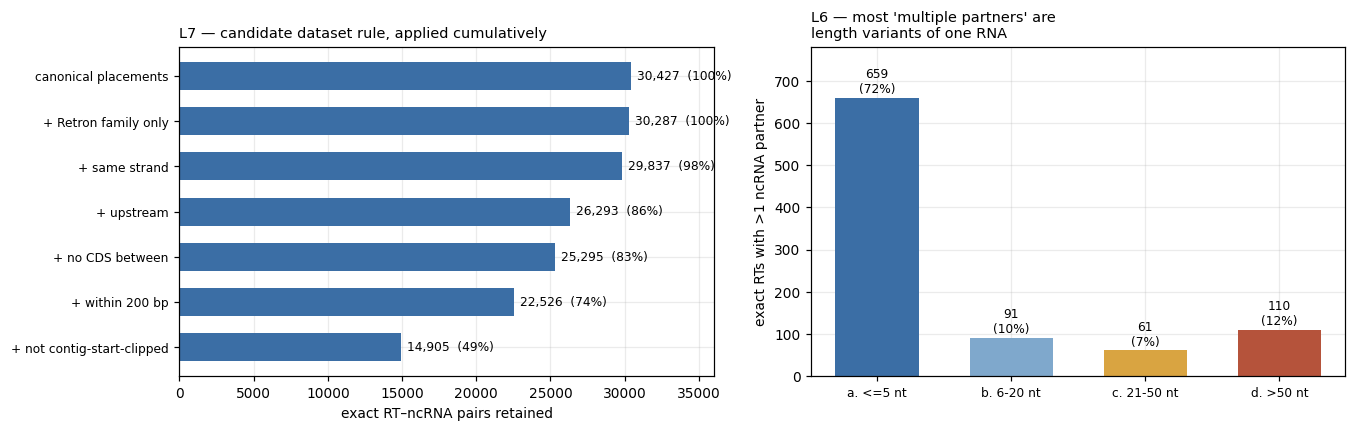

In [54]:
C7 = pd.read_csv(TABLES / "L7_dataset_rule_cascade.tsv", sep="\t").sort_values("step")
S6 = pd.read_csv(TABLES / "L6_partner_length_spread.tsv", sep="\t")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0))
ax = axes[0]
y = np.arange(len(C7))[::-1]
ax.barh(y, C7.n_exact_pairs, color="#3b6ea5", height=0.62)
for yi, (n, p) in zip(y, C7[["n_exact_pairs", "pairs_retained_pct"]].itertuples(index=False)):
    ax.text(n + 400, yi, f"{n:,}  ({p:.0f}%)", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(C7.rule, fontsize=8)
ax.set_xlim(0, 36000); ax.set_xlabel("exact RT–ncRNA pairs retained")
ax.set_title("L7 — candidate dataset rule, applied cumulatively", fontsize=9.5, loc="left")

ax = axes[1]
ax.bar(S6.partner_length_spread, S6.n_exact_rt,
       color=["#3b6ea5", "#7fa8cc", "#d9a441", "#b5533b"], width=0.62)
for x, (n, p) in enumerate(S6[["n_exact_rt", "pct"]].itertuples(index=False)):
    ax.text(x, n + 12, f"{n}\n({p:.0f}%)", ha="center", fontsize=8)
ax.set_ylabel("exact RTs with >1 ncRNA partner")
ax.set_xticks(range(len(S6)))
ax.set_xticklabels([s.split("  ")[0] for s in S6.partner_length_spread], fontsize=8)
ax.set_ylim(0, 780)
ax.set_title("L6 — most 'multiple partners' are\nlength variants of one RNA", fontsize=9.5, loc="left")
fig.tight_layout(); savefig(fig, "L_dataset_rule_and_multiplicity"); plt.show()

**L7 — the proposed rule, costed.** Applying *Retron → same strand → upstream → no intervening CDS
→ within 200 bp* cumulatively to canonical placements yields **190,028 placements, 22,526 exact
pairs, 21,610 exact RT proteins, 11,514 exact ncRNA sequences, 156,741 physical loci** — retaining
**74 %** of canonical exact pairs. The distance cut is the only step that removes a large share; the
strand and adjacency criteria are nearly free because the population already satisfies them.

Adding *not contig-start-clipped* is the consequential extra decision: it drops the dataset to
14,905 pairs, **removing a further 34 %**. That criterion is defensible — a clipped window cannot
show what lies beyond the contig edge — but it is a substantive reduction and should be a stated
choice, not a default.

Within the 22,526-pair rule, recurrence splits as **8,660 single-placement**, **6,686 database
copies of one physical locus**, and **7,180 independently recurrent** (3,761 across species, 3,399
across genomes of one species, 20 across loci of one genome).

**Recommendation.** Ship the dataset in **tiers** rather than as one thresholded set: a permissive
tier (the 22,526-pair rule), a strict tier (additionally unclipped, 14,905), and an
independence-filtered tier (additionally requiring cross-genome or cross-species recurrence). A
model or an experimental shortlist can then choose its own operating point, and the paper reports
all three rather than defending one threshold. **Covariance-model hit quality (`score`, `evalue`) is
still absent from every tier** and should be added before any tier is called "high-confidence".